In [2]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#E-R model, WS model, BA model

In [10]:
p = (4/1999)
#p = 0.001

In [75]:
print(df3)

           1      2
0          2    617
1          3      4
2          3      5
3          3      6
4          3      7
...      ...    ...
24310  10532  10533
24311  10552  10553
24312  10558  10594
24313  10560  10588
24314  10620  10621

[24315 rows x 2 columns]


In [66]:
df2 = pd.read_csv("power_grid.tsv")

In [76]:
# Lê o tsv com o pandas
df = pd.read_csv("autonomous_system.tsv", sep='\t')
df2 = pd.read_csv("power_grid.tsv", sep=" ")
df3 = pd.read_csv("pgp.tsv", sep=" ")
# Constrói o grafo a partir do DataFrame
# Ajuste 'source' e 'target' para os nomes reais das suas colunas
autonomous_system = nx.from_pandas_edgelist(df, source='1', target='2')
power_grid = nx.from_pandas_edgelist(df2, source='1', target='2')
pgp = nx.from_pandas_edgelist(df3, source='1', target='2')

In [78]:
watts = nx.watts_strogatz_graph(2000, k=4, p=0.05)
erdos = nx.erdos_renyi_graph(2000, p)
barabasi = nx.barabasi_albert_graph(n=2000, m=2)
karate = nx.karate_club_graph()
autonomous_system = nx.from_pandas_edgelist(df, source='1', target='2')
power_grid = nx.from_pandas_edgelist(df2, source='1', target='2')
pgp = nx.from_pandas_edgelist(df3, source='1', target='2')

In [24]:
erdos

In [4]:
def calc_forman_ricci_curvature(grafo):
    for u, v in grafo.edges():
        u_degree = grafo.degree(u)
        v_degree = grafo.degree(v)

        curvatura = 4 - (u_degree + v_degree)

        grafo[u][v]["formanRicci"] = curvatura
        
def forman_ricci_curvature_2d(G):
    # Pré-calculamos os vizinhos como sets para garantir interseção rápida
    neighbors = {n: set(G.neighbors(n)) for n in G.nodes()}

    for u, v in G.edges():
        # T: Número de triângulos que contêm a aresta (u, v)
        T = len(neighbors[u] & neighbors[v])

        # d_u e d_v: Graus dos nós incidentes
        d_u = G.degree(u)
        d_v = G.degree(v)

        # P: Número de arestas paralelas (Definição 2 do artigo)
        # Explicação: Todos os vizinhos menos a própria aresta (u,v) 
        # e menos as arestas que fecham triângulos.
        P = (d_u - 1) + (d_v - 1) - 2 * T

        # Ric_F: Curvatura de Forman-Ricci 2D (Equação 15 do artigo)
        # Ric = Faces - Paralelas + 2
        G[u][v]['forman2d'] = T - P + 2
def euler_characteristic(G):
    V = G.number_of_nodes()
    E = G.number_of_edges()
    
    # triângulos
    triangles = sum(nx.triangles(G).values()) // 3
    
    return V - E + triangles



In [81]:
calc_forman_ricci_curvature(erdos)
forman_ricci_curvature_2d(erdos)
euler_erdos =euler_characteristic(erdos)

calc_forman_ricci_curvature(watts)
forman_ricci_curvature_2d(watts)
euler_watts =euler_characteristic(watts)


calc_forman_ricci_curvature(barabasi)
forman_ricci_curvature_2d(barabasi)
euler_barabasi =euler_characteristic(barabasi)

calc_forman_ricci_curvature(karate)
forman_ricci_curvature_2d(karate)
euler_karate =euler_characteristic(karate)

calc_forman_ricci_curvature(autonomous_system)
forman_ricci_curvature_2d(autonomous_system)
euler_autonomous_system =euler_characteristic(autonomous_system)

calc_forman_ricci_curvature(power_grid)
forman_ricci_curvature_2d(power_grid)
euler_power_grid =euler_characteristic(power_grid)

calc_forman_ricci_curvature(pgp)
forman_ricci_curvature_2d(pgp)
euler_pgp =euler_characteristic(pgp)



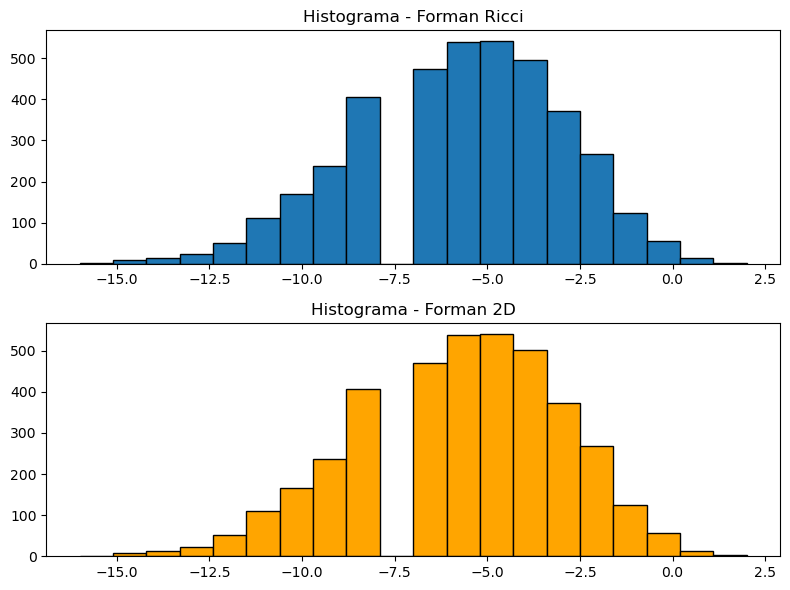

-5.773285568065507
-5.761770726714432
-22517
0.002001000500250125


In [46]:
lista_forman, lista_forman_2d = [],[]
for u, v in erdos.edges():
    lista_forman.append(erdos[u][v]["formanRicci"])
    lista_forman_2d.append(erdos[u][v]["forman2d"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.hist(lista_forman, bins=20, edgecolor='black')
ax1.set_title("Histograma - Forman Ricci")

ax2.hist(lista_forman_2d, bins=20, edgecolor='black', color='orange')
ax2.set_title("Histograma - Forman 2D")

plt.tight_layout()
plt.show()


media_forman = np.mean(lista_forman)
media_forman_2d = np.mean(lista_forman_2d) 
soma_forman_2d = np.sum(lista_forman_2d)
print(media_forman)
print(media_forman_2d)
print(soma_forman_2d)
print(p)

lista_

In [47]:
razao = soma_forman_2d/euler
print(f'a razão entre a soma e euler para um grafo de ER é:{razao}')

a razão entre a soma e euler para um grafo de ER é:11.832369942196532


In [48]:
len(erdos.edges())

3908

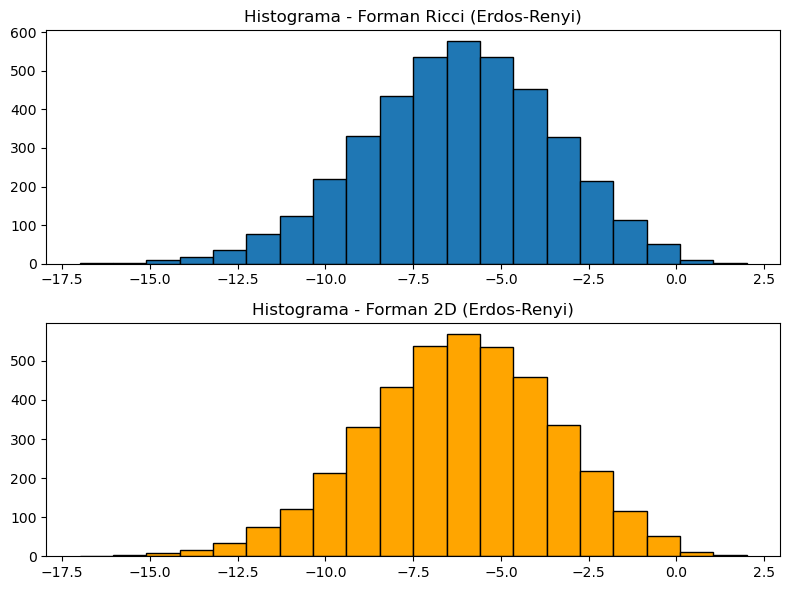

--- Erdos-Renyi ---
Média Forman Ricci: -6.152259332023576
Média Forman 2D: -6.112475442043222
Soma Forman 2D: -24890
p (probabilidade): 0.002001000500250125



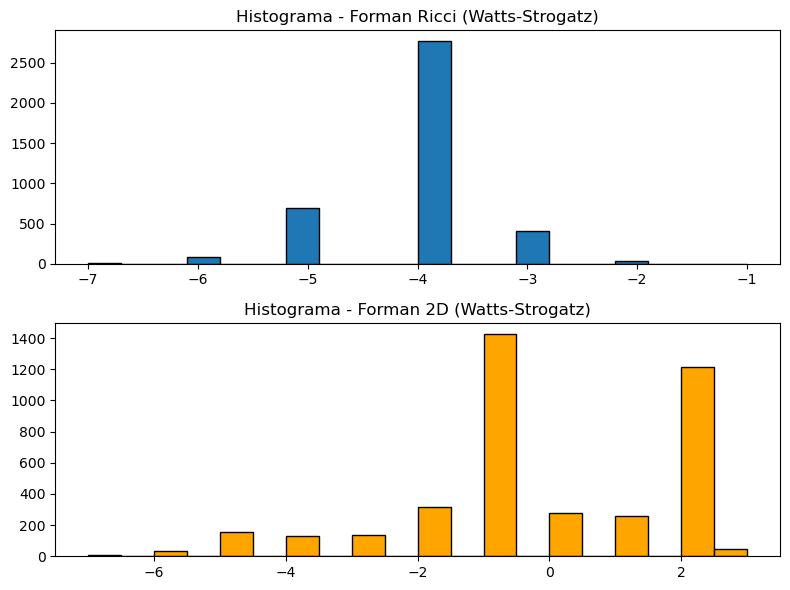

--- Watts-Strogatz ---
Média Forman Ricci: -4.102
Média Forman 2D: -0.286
Soma Forman 2D: -1144


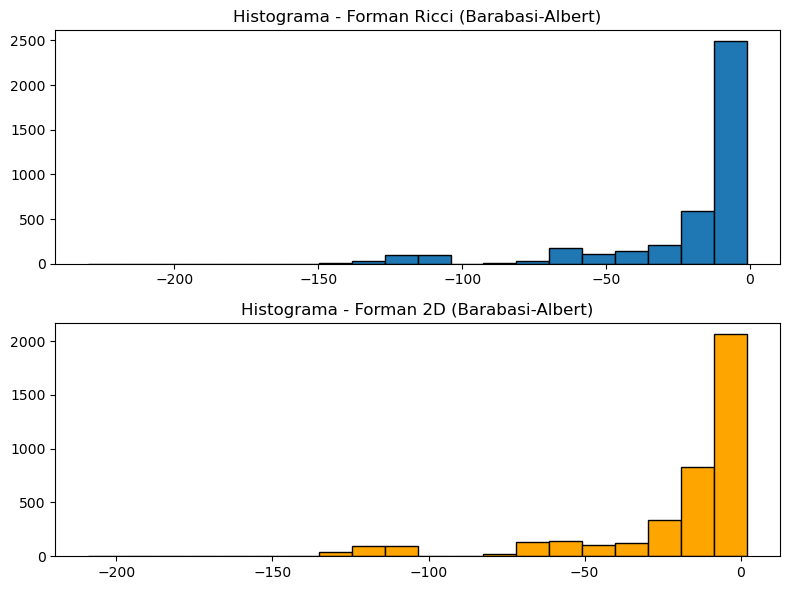

--- Barabasi-Albert ---
Média Forman Ricci: -20.843343343343342
Média Forman 2D: -20.636136136136138
Soma Forman 2D: -82462


In [53]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. GRÁFICO ERDOS-RENYI
# ------------------------------------------------------------
lista_forman_er, lista_forman_2d_er = [], []
for u, v in erdos.edges():
    lista_forman_er.append(erdos[u][v]["formanRicci"])
    lista_forman_2d_er.append(erdos[u][v]["forman2d"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
ax1.hist(lista_forman_er, bins=20, edgecolor='black')
ax1.set_title("Histograma - Forman Ricci (Erdos-Renyi)")
ax2.hist(lista_forman_2d_er, bins=20, edgecolor='black', color='orange')
ax2.set_title("Histograma - Forman 2D (Erdos-Renyi)")
plt.tight_layout()
plt.show()

media_forman_er = np.mean(lista_forman_er)
media_forman_2d_er = np.mean(lista_forman_2d_er)
soma_forman_2d_er = np.sum(lista_forman_2d_er)
print("--- Erdos-Renyi ---")
print(f"Média Forman Ricci: {media_forman_er}")
print(f"Média Forman 2D: {media_forman_2d_er}")
print(f"Soma Forman 2D: {soma_forman_2d_er}")
print(f"p (probabilidade): {p}\n")

# ------------------------------------------------------------
# 2. GRÁFICO WATTS-STROGATZ
# ------------------------------------------------------------
lista_forman_ws, lista_forman_2d_ws = [], []
for u, v in watts.edges():
    lista_forman_ws.append(watts[u][v]["formanRicci"])
    lista_forman_2d_ws.append(watts[u][v]["forman2d"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
ax1.hist(lista_forman_ws, bins=20, edgecolor='black')
ax1.set_title("Histograma - Forman Ricci (Watts-Strogatz)")
ax2.hist(lista_forman_2d_ws, bins=20, edgecolor='black', color='orange')
ax2.set_title("Histograma - Forman 2D (Watts-Strogatz)")
plt.tight_layout()
plt.show()

media_forman_ws = np.mean(lista_forman_ws)
media_forman_2d_ws = np.mean(lista_forman_2d_ws)
soma_forman_2d_ws = np.sum(lista_forman_2d_ws)
print("--- Watts-Strogatz ---")
print(f"Média Forman Ricci: {media_forman_ws}")
print(f"Média Forman 2D: {media_forman_2d_ws}")
print(f"Soma Forman 2D: {soma_forman_2d_ws}")
# Parâmetros típicos do WS: k (vizinhos) e p (rewiring)
# Se você definiu essas variáveis, imprima-as aqui.
# Exemplo:
# print(f"k = {k_ws}, p_rewiring = {p_ws}\n")

# ------------------------------------------------------------
# 3. GRÁFICO BARABASI-ALBERT
# ------------------------------------------------------------
lista_forman_ba, lista_forman_2d_ba = [], []
for u, v in barabasi.edges():
    lista_forman_ba.append(barabasi[u][v]["formanRicci"])
    lista_forman_2d_ba.append(barabasi[u][v]["forman2d"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
ax1.hist(lista_forman_ba, bins=20, edgecolor='black')
ax1.set_title("Histograma - Forman Ricci (Barabasi-Albert)")
ax2.hist(lista_forman_2d_ba, bins=20, edgecolor='black', color='orange')
ax2.set_title("Histograma - Forman 2D (Barabasi-Albert)")
plt.tight_layout()
plt.show()

media_forman_ba = np.mean(lista_forman_ba)
media_forman_2d_ba = np.mean(lista_forman_2d_ba)
soma_forman_2d_ba = np.sum(lista_forman_2d_ba)
print("--- Barabasi-Albert ---")
print(f"Média Forman Ricci: {media_forman_ba}")
print(f"Média Forman 2D: {media_forman_2d_ba}")
print(f"Soma Forman 2D: {soma_forman_2d_ba}")
# Parâmetro do BA: m (arestas adicionadas por nó)
# print(f"m = {m_ba}")

In [54]:
# Supondo que você já tenha calculado:
# euler_erdos, euler_watts, euler_barabasi
# e as somas: soma_forman_2d_er, soma_forman_2d_ws, soma_forman_2d_ba

# Razão para Erdos-Renyi (já feito)
razao_er = soma_forman_2d_er / euler_erdos
print(f'Razão soma/ Euler para ER: {razao_er}')

# Razão para Watts-Strogatz
razao_ws = soma_forman_2d_ws / euler_watts
print(f'Razão soma/ Euler para WS: {razao_ws}')

# Razão para Barabasi-Albert
razao_ba = soma_forman_2d_ba / euler_barabasi
print(f'Razão soma/ Euler para BA: {razao_ba}')

Razão soma/ Euler para ER: 12.117818889970788
Razão soma/ Euler para WS: 3.763157894736842
Razão soma/ Euler para BA: 43.30987394957983


In [57]:
np.log(razao_er)

np.float64(2.494677004873134)

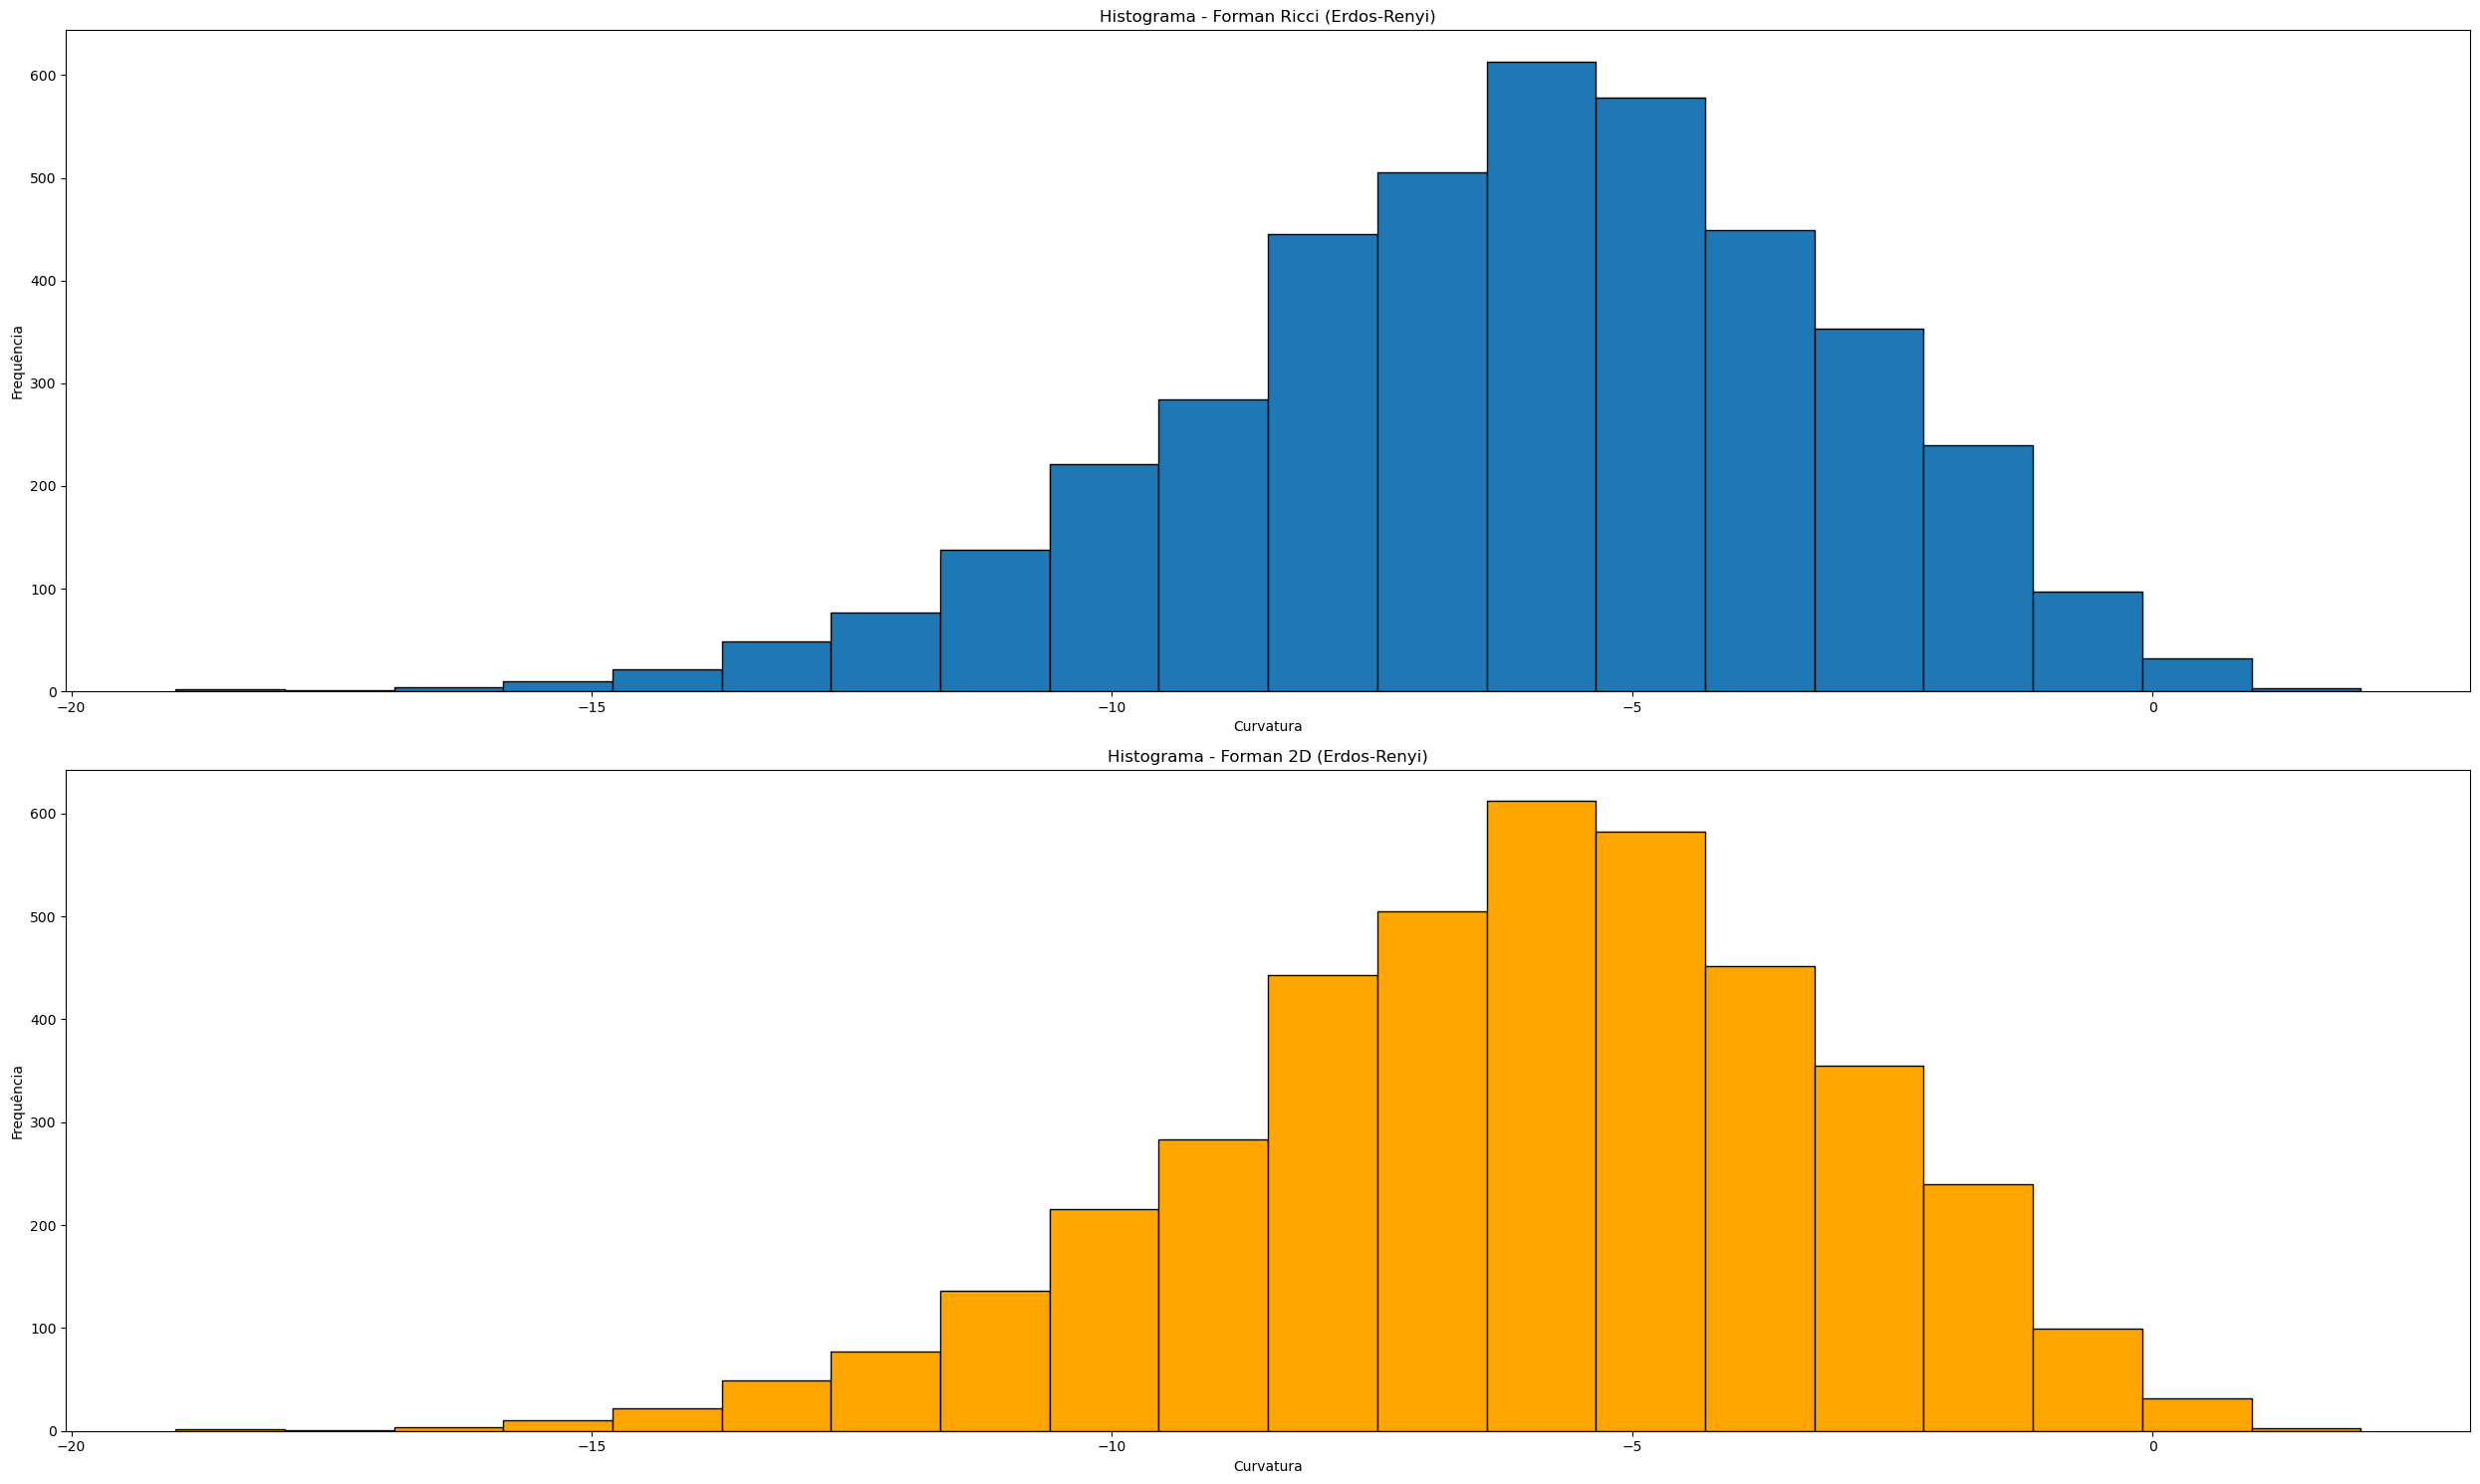

REDE: Erdos-Renyi
Número de nós: 2000
Número de arestas: 4123

Média Forman Ricci: -6.187727382973563
Média Forman 2D: -6.172447247150133
Soma Forman 2D: -25449
p (probabilidade): 0.002001000500250125




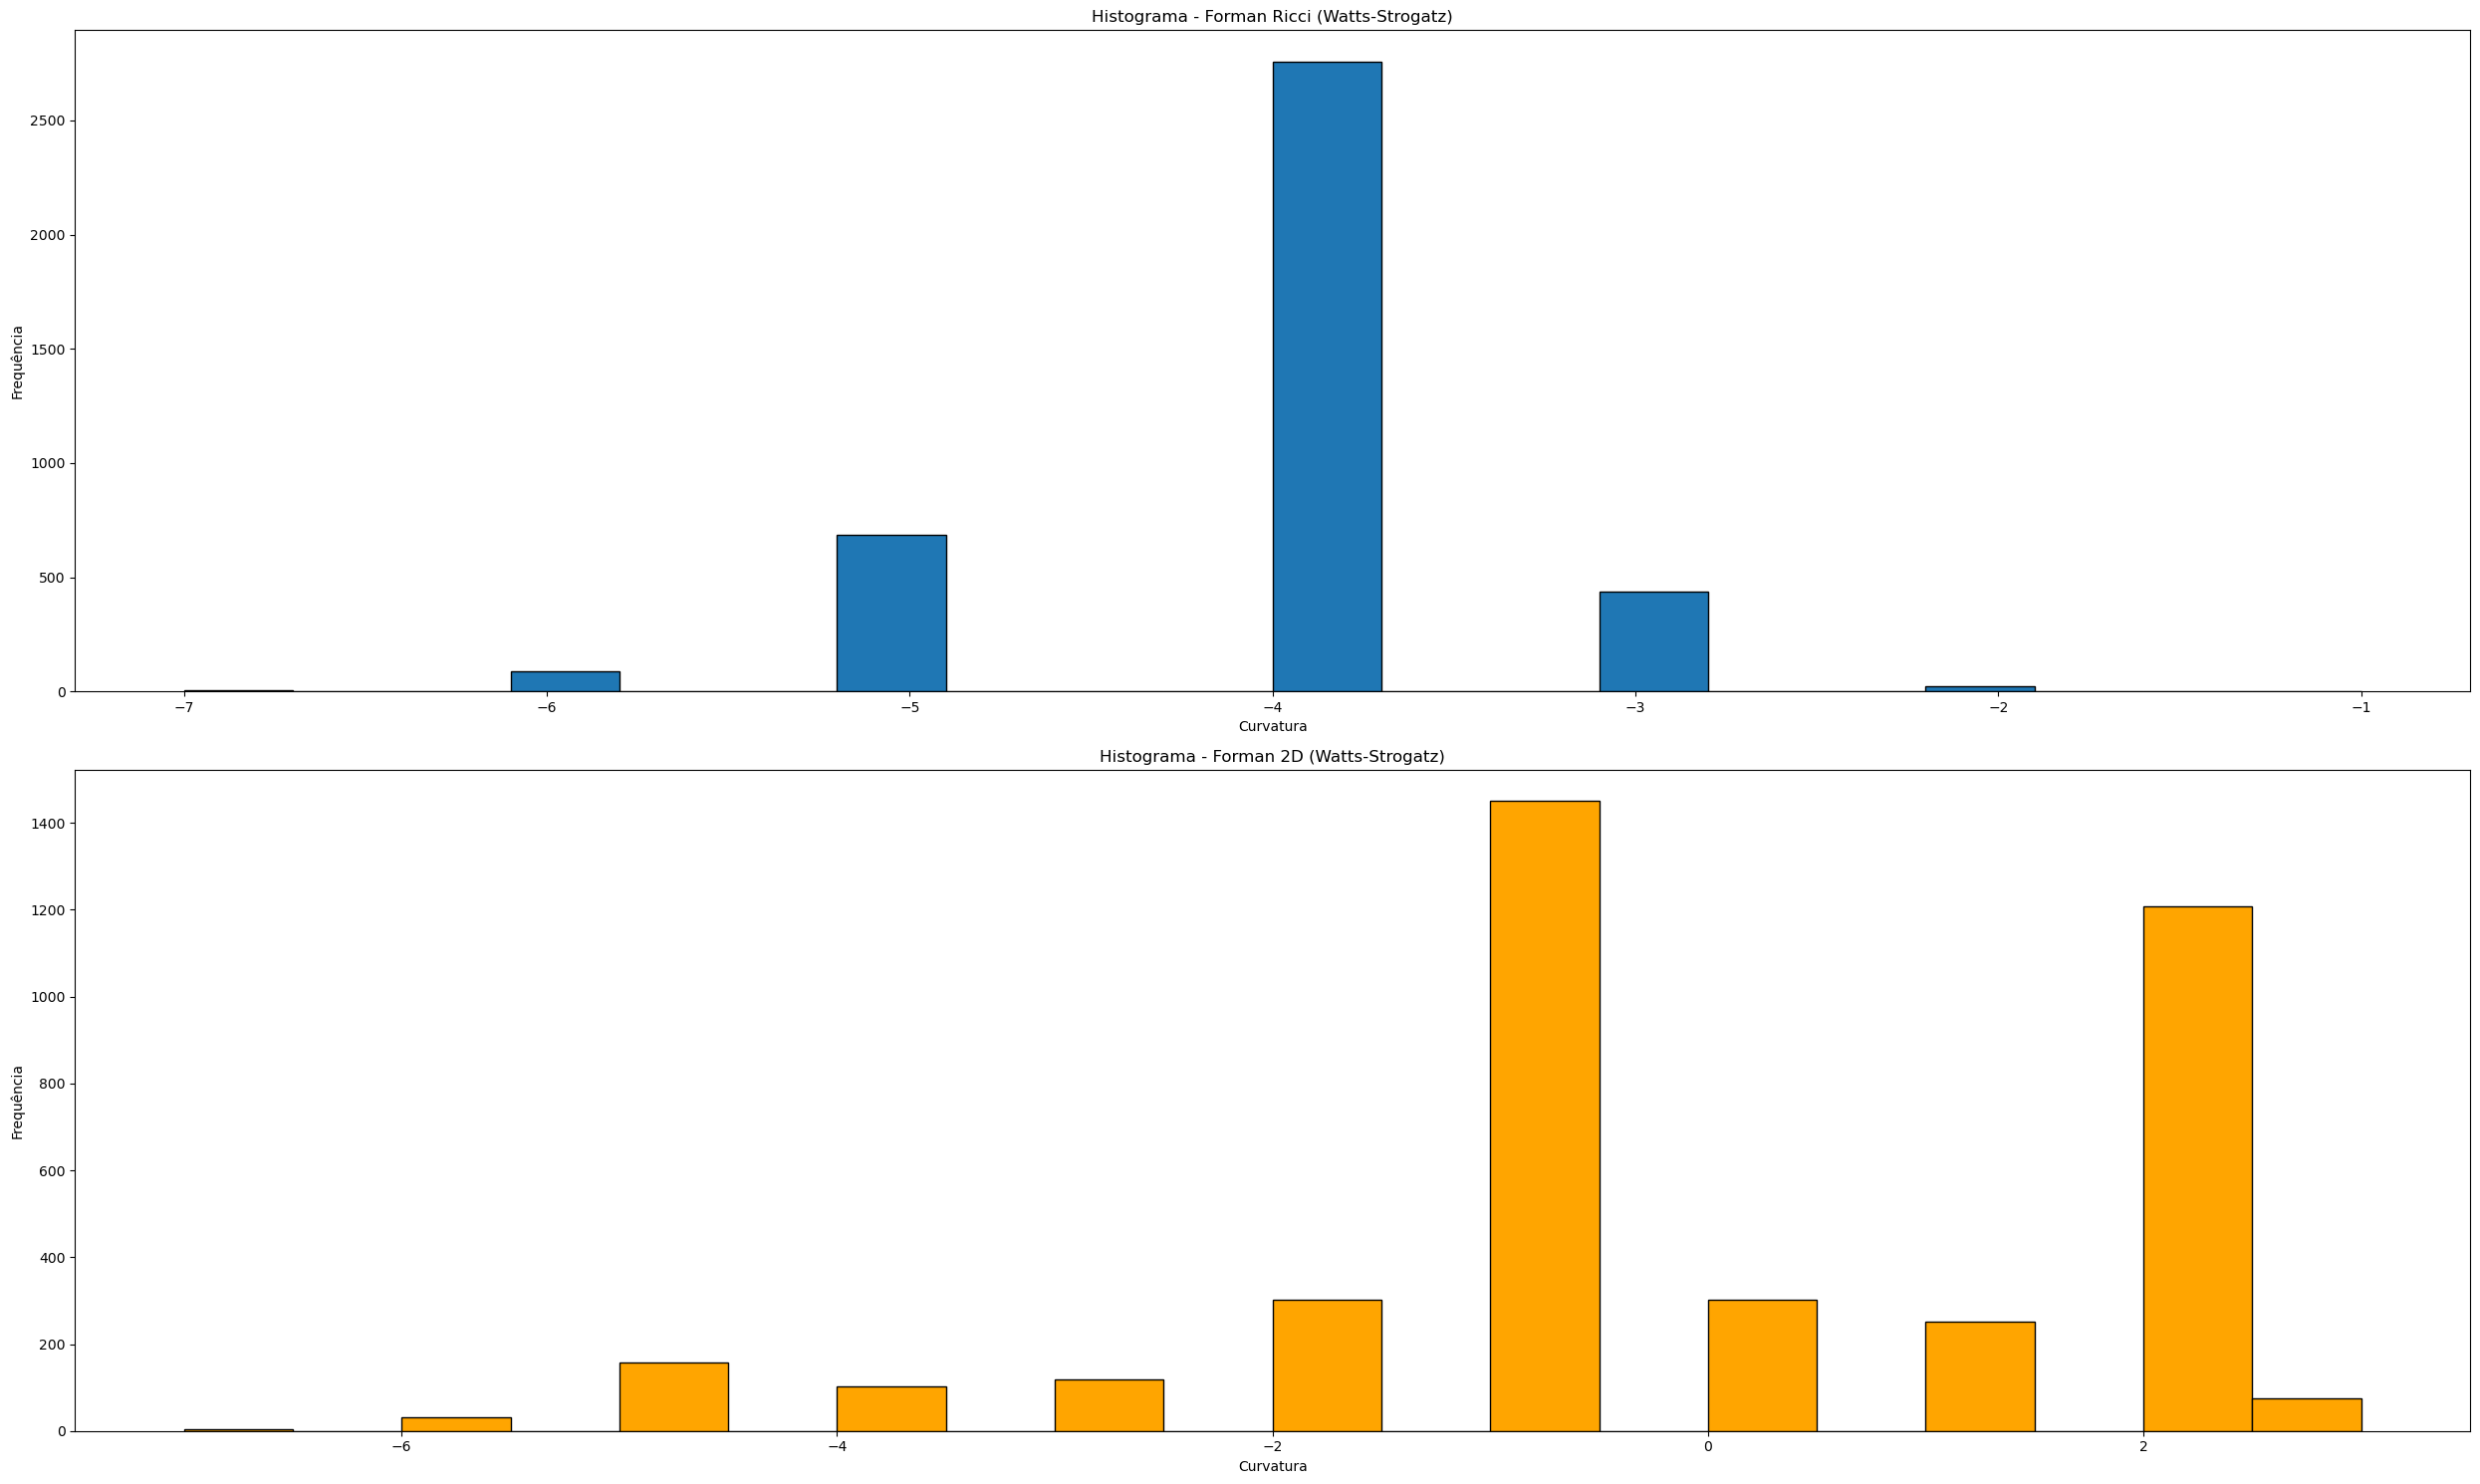

REDE: Watts-Strogatz
Número de nós: 2000
Número de arestas: 4000

Média Forman Ricci: -4.0995
Média Forman 2D: -0.234
Soma Forman 2D: -936
Modelo Watts-Strogatz




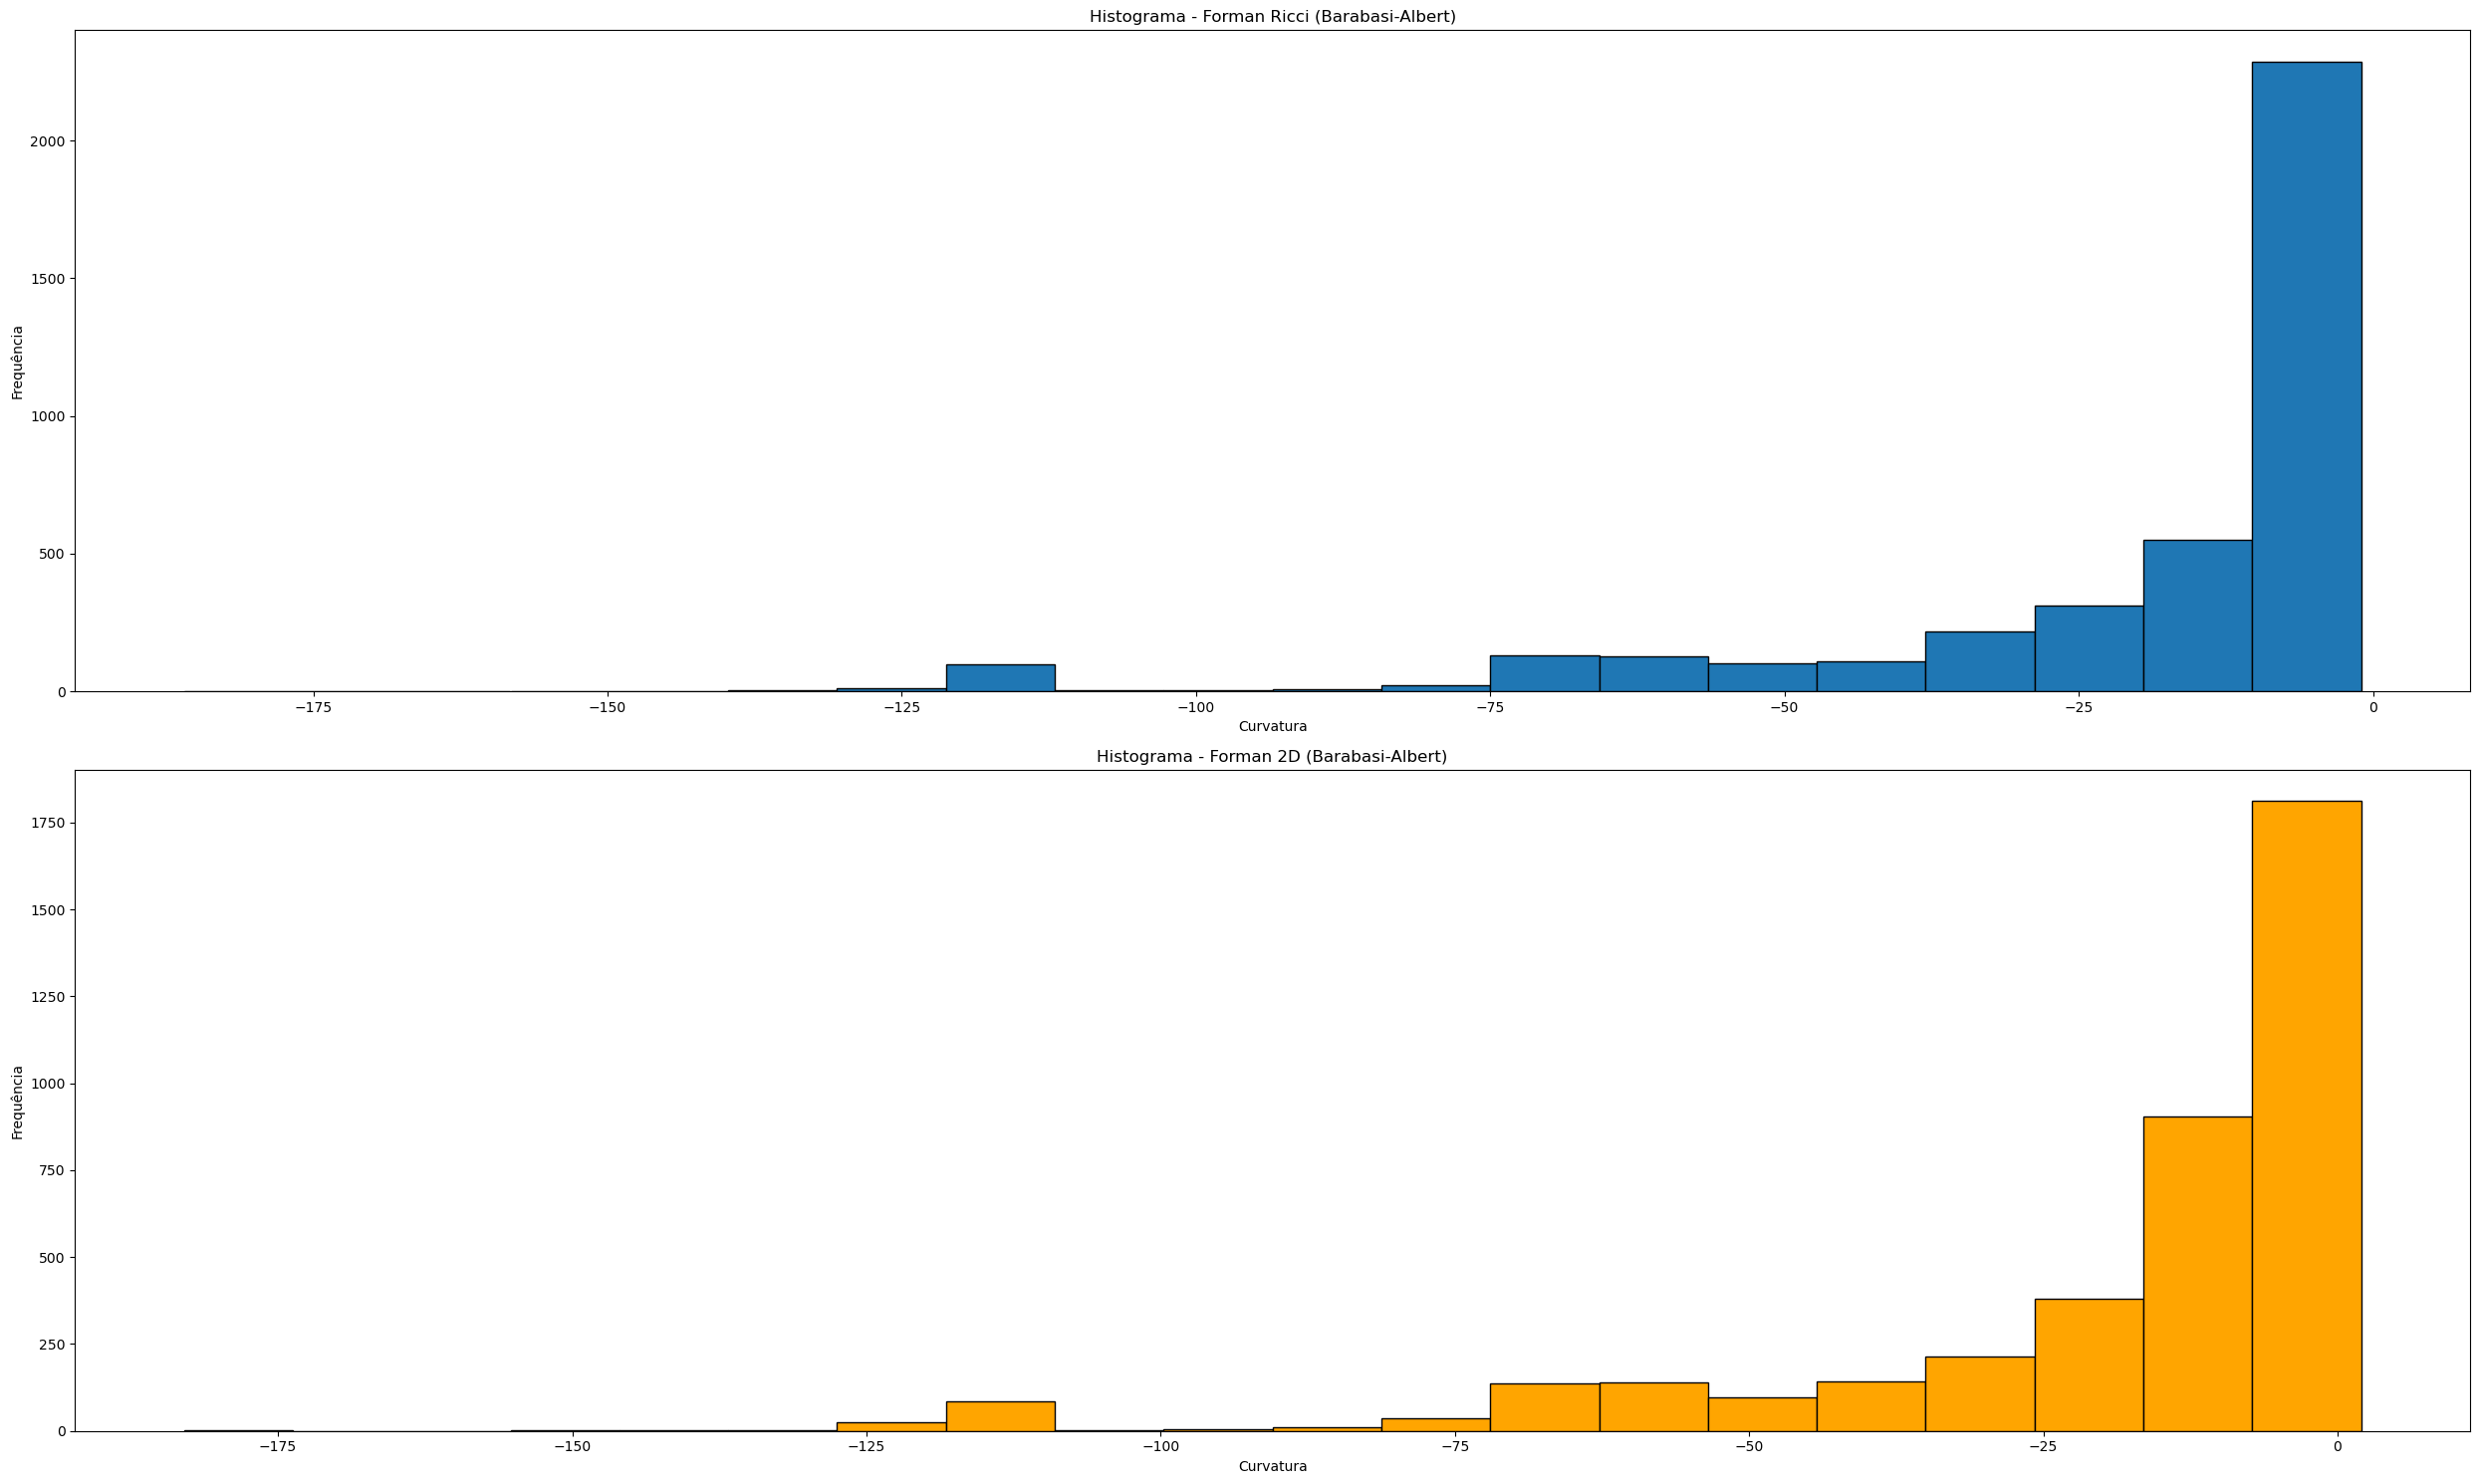

REDE: Barabasi-Albert
Número de nós: 2000
Número de arestas: 3996

Média Forman Ricci: -19.44144144144144
Média Forman 2D: -19.283783783783782
Soma Forman 2D: -77058
Modelo Barabasi-Albert




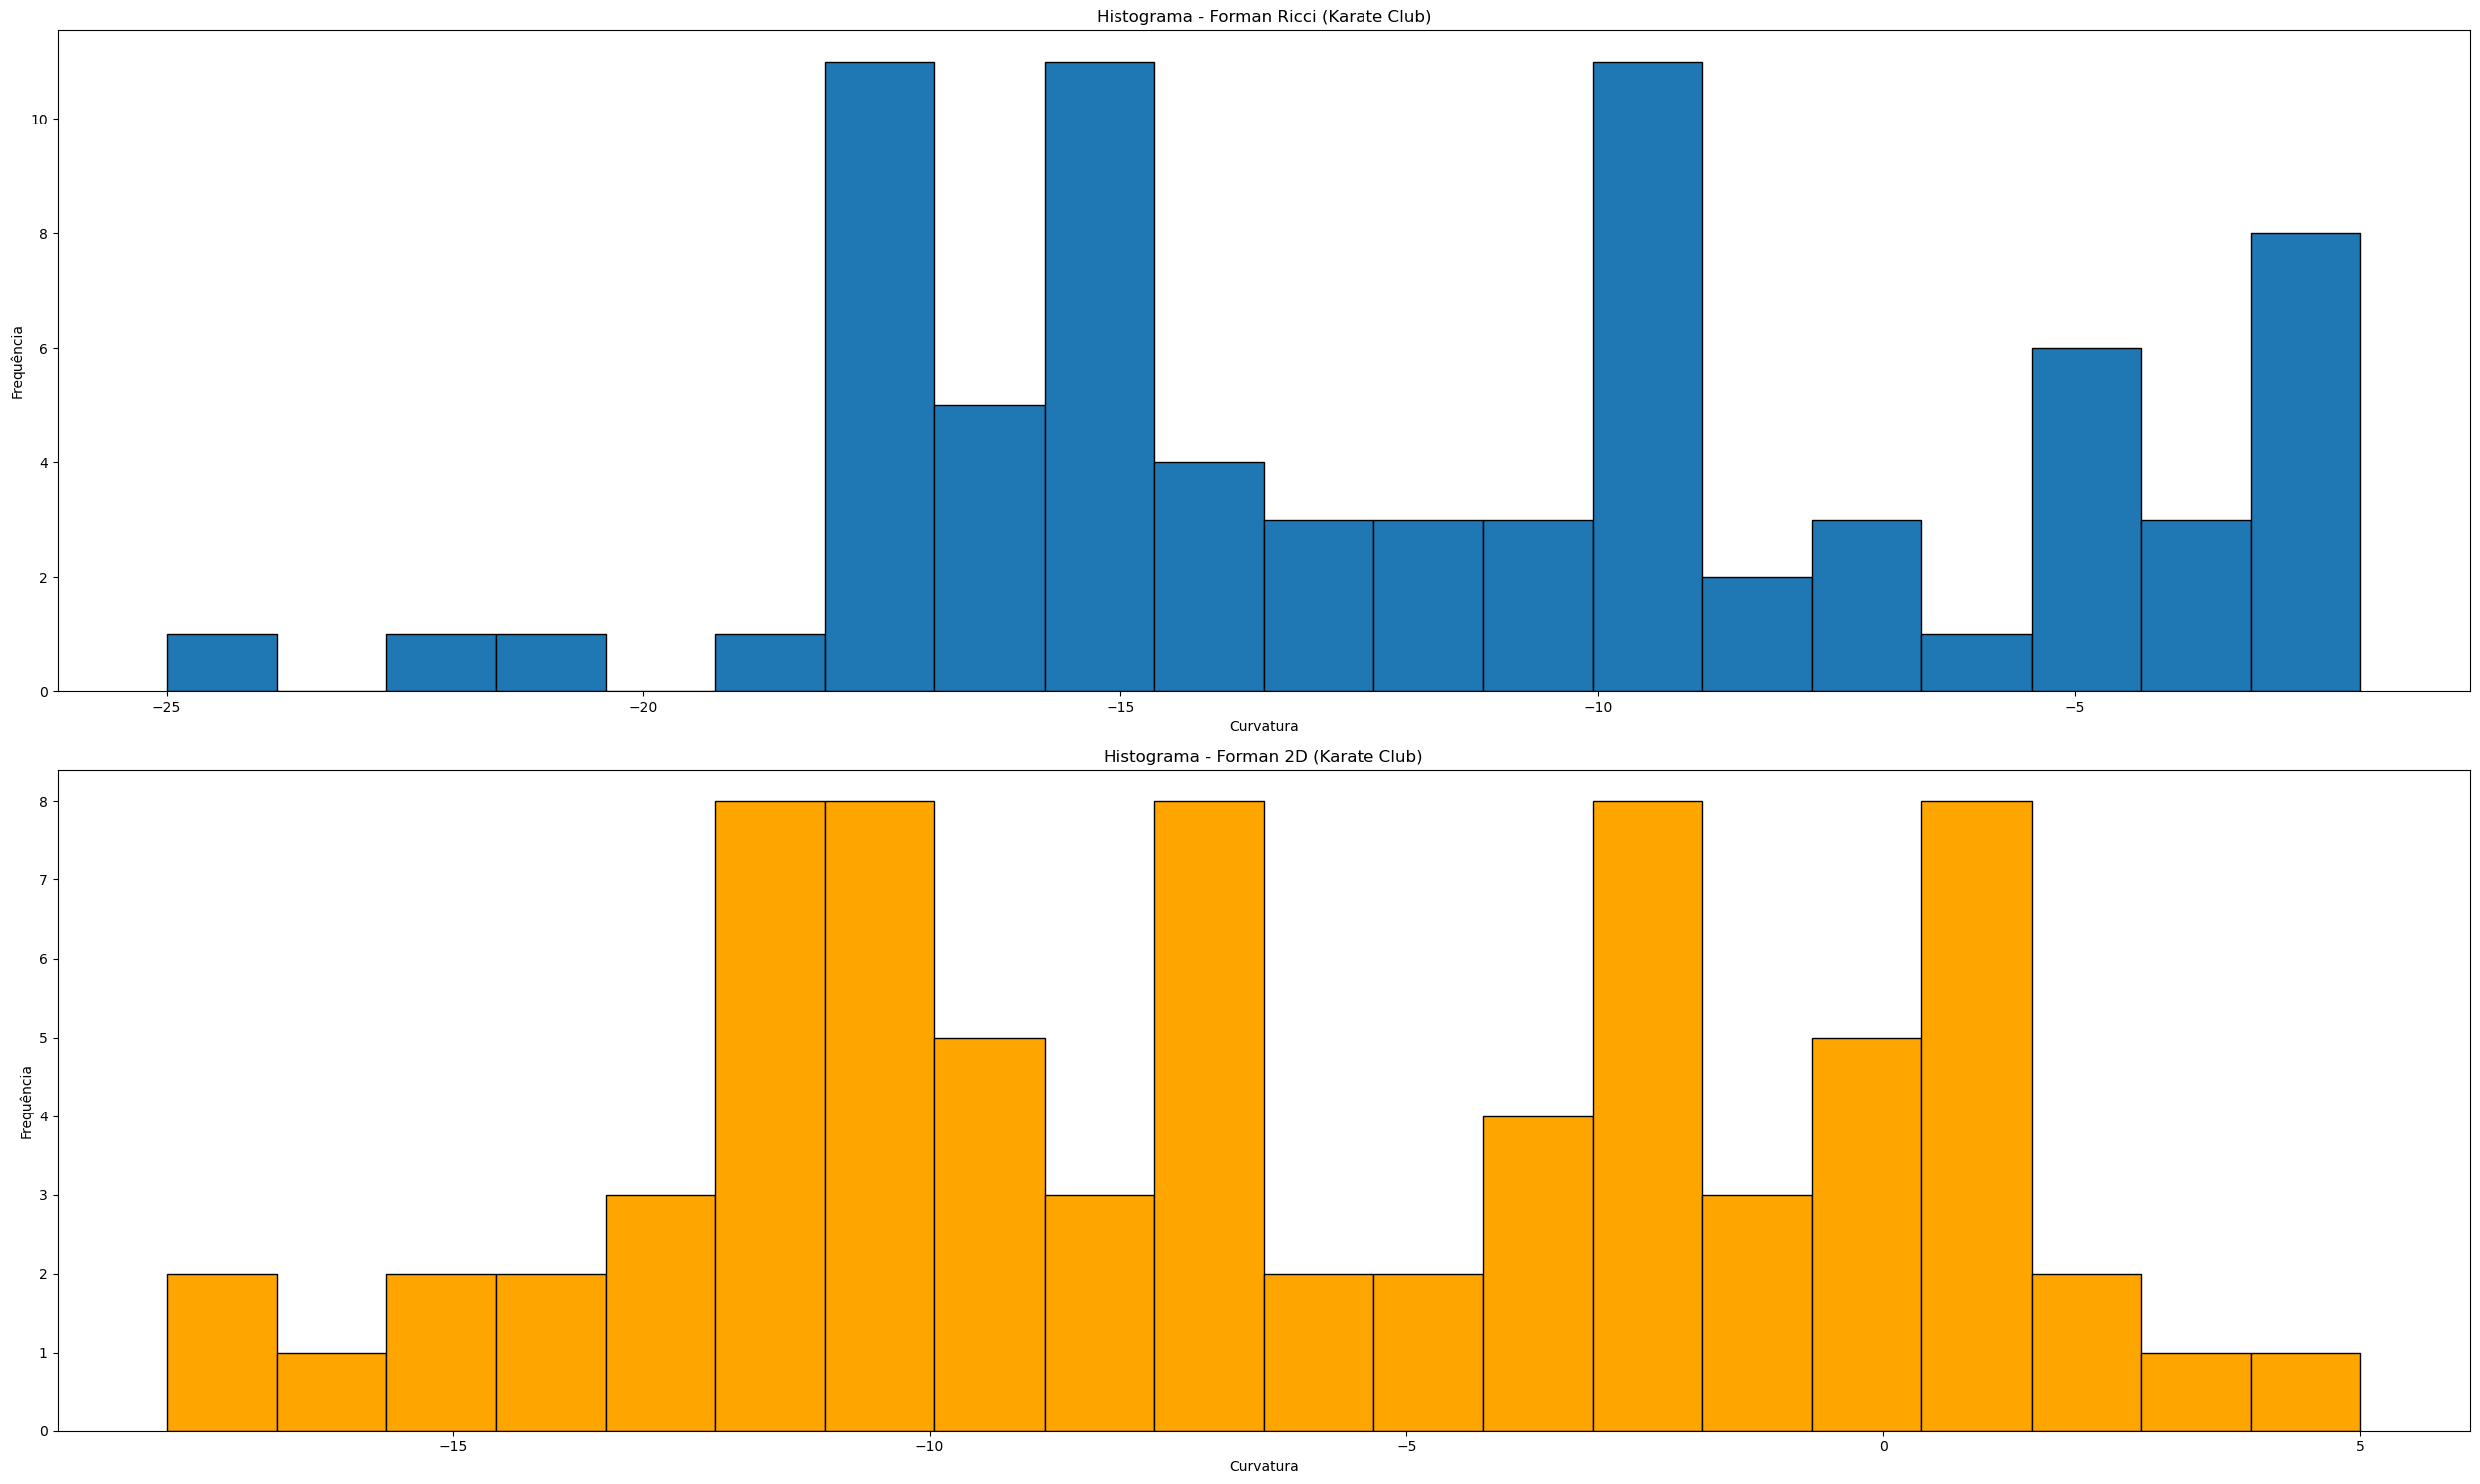

REDE: Karate Club
Número de nós: 34
Número de arestas: 78

Média Forman Ricci: -11.538461538461538
Média Forman 2D: -6.346153846153846
Soma Forman 2D: -495




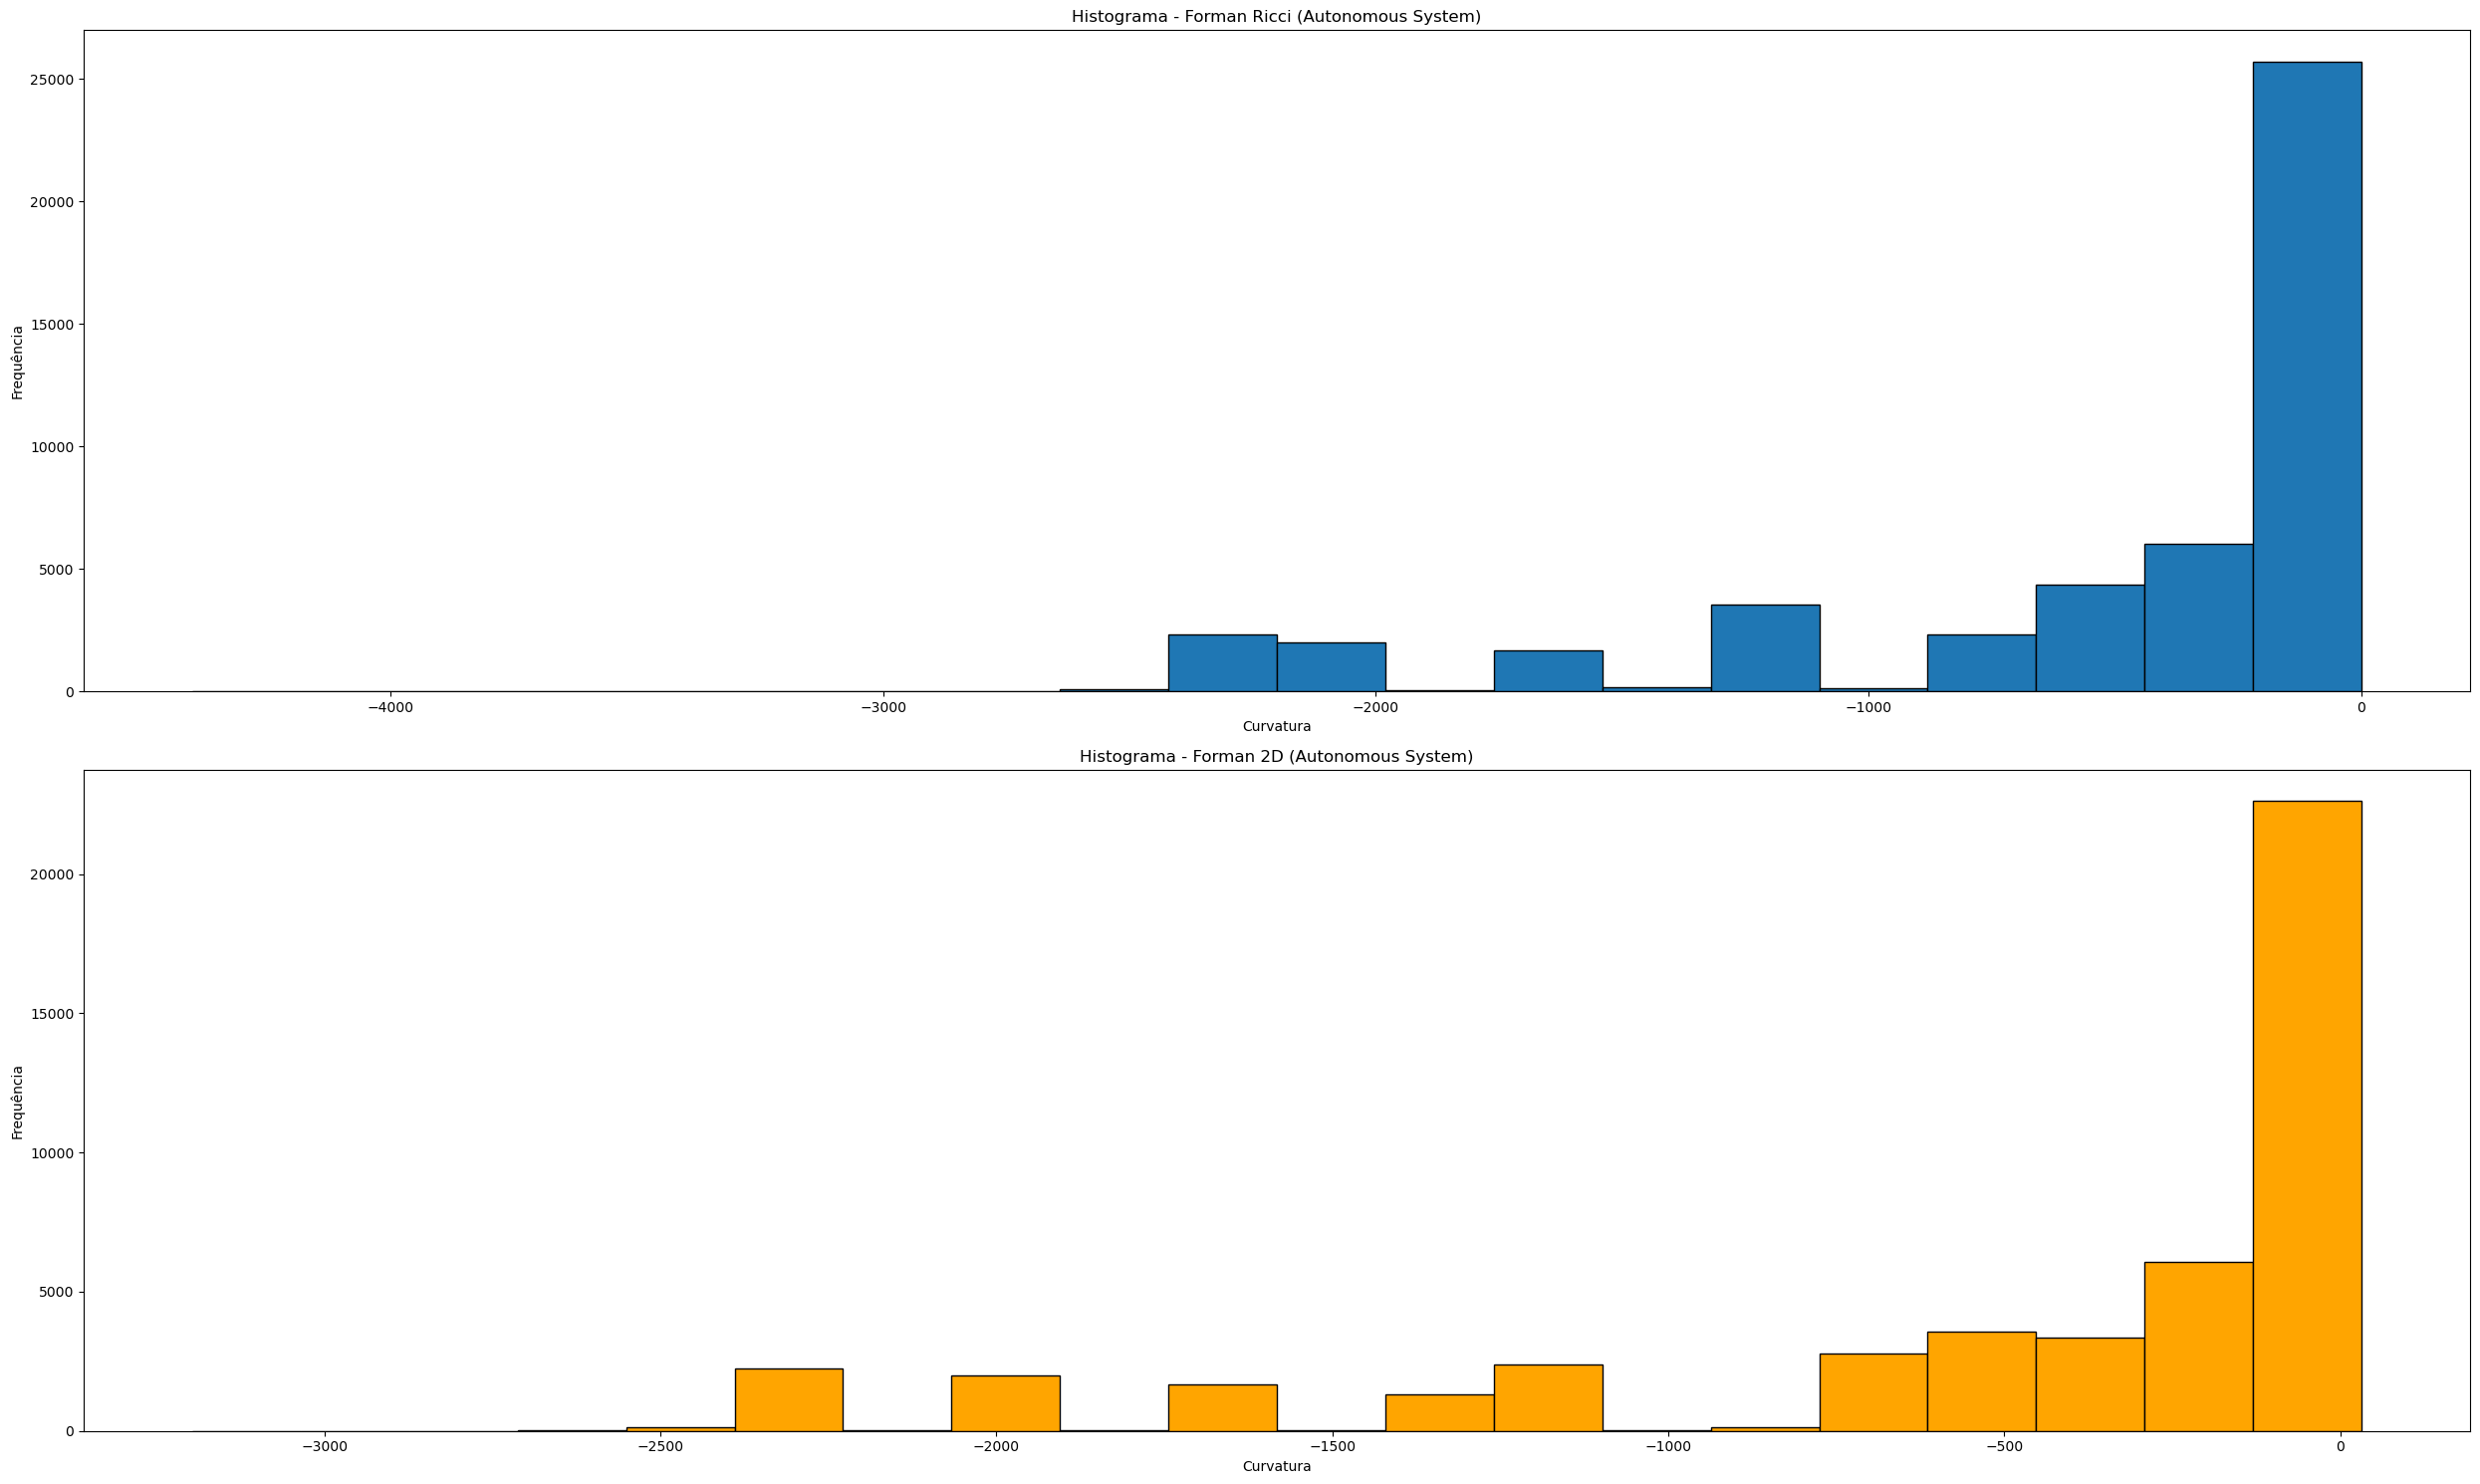

REDE: Autonomous System
Número de nós: 22962
Número de arestas: 48435

Média Forman Ricci: -518.9224321255291
Média Forman 2D: -510.2126767833179
Soma Forman 2D: -24712151




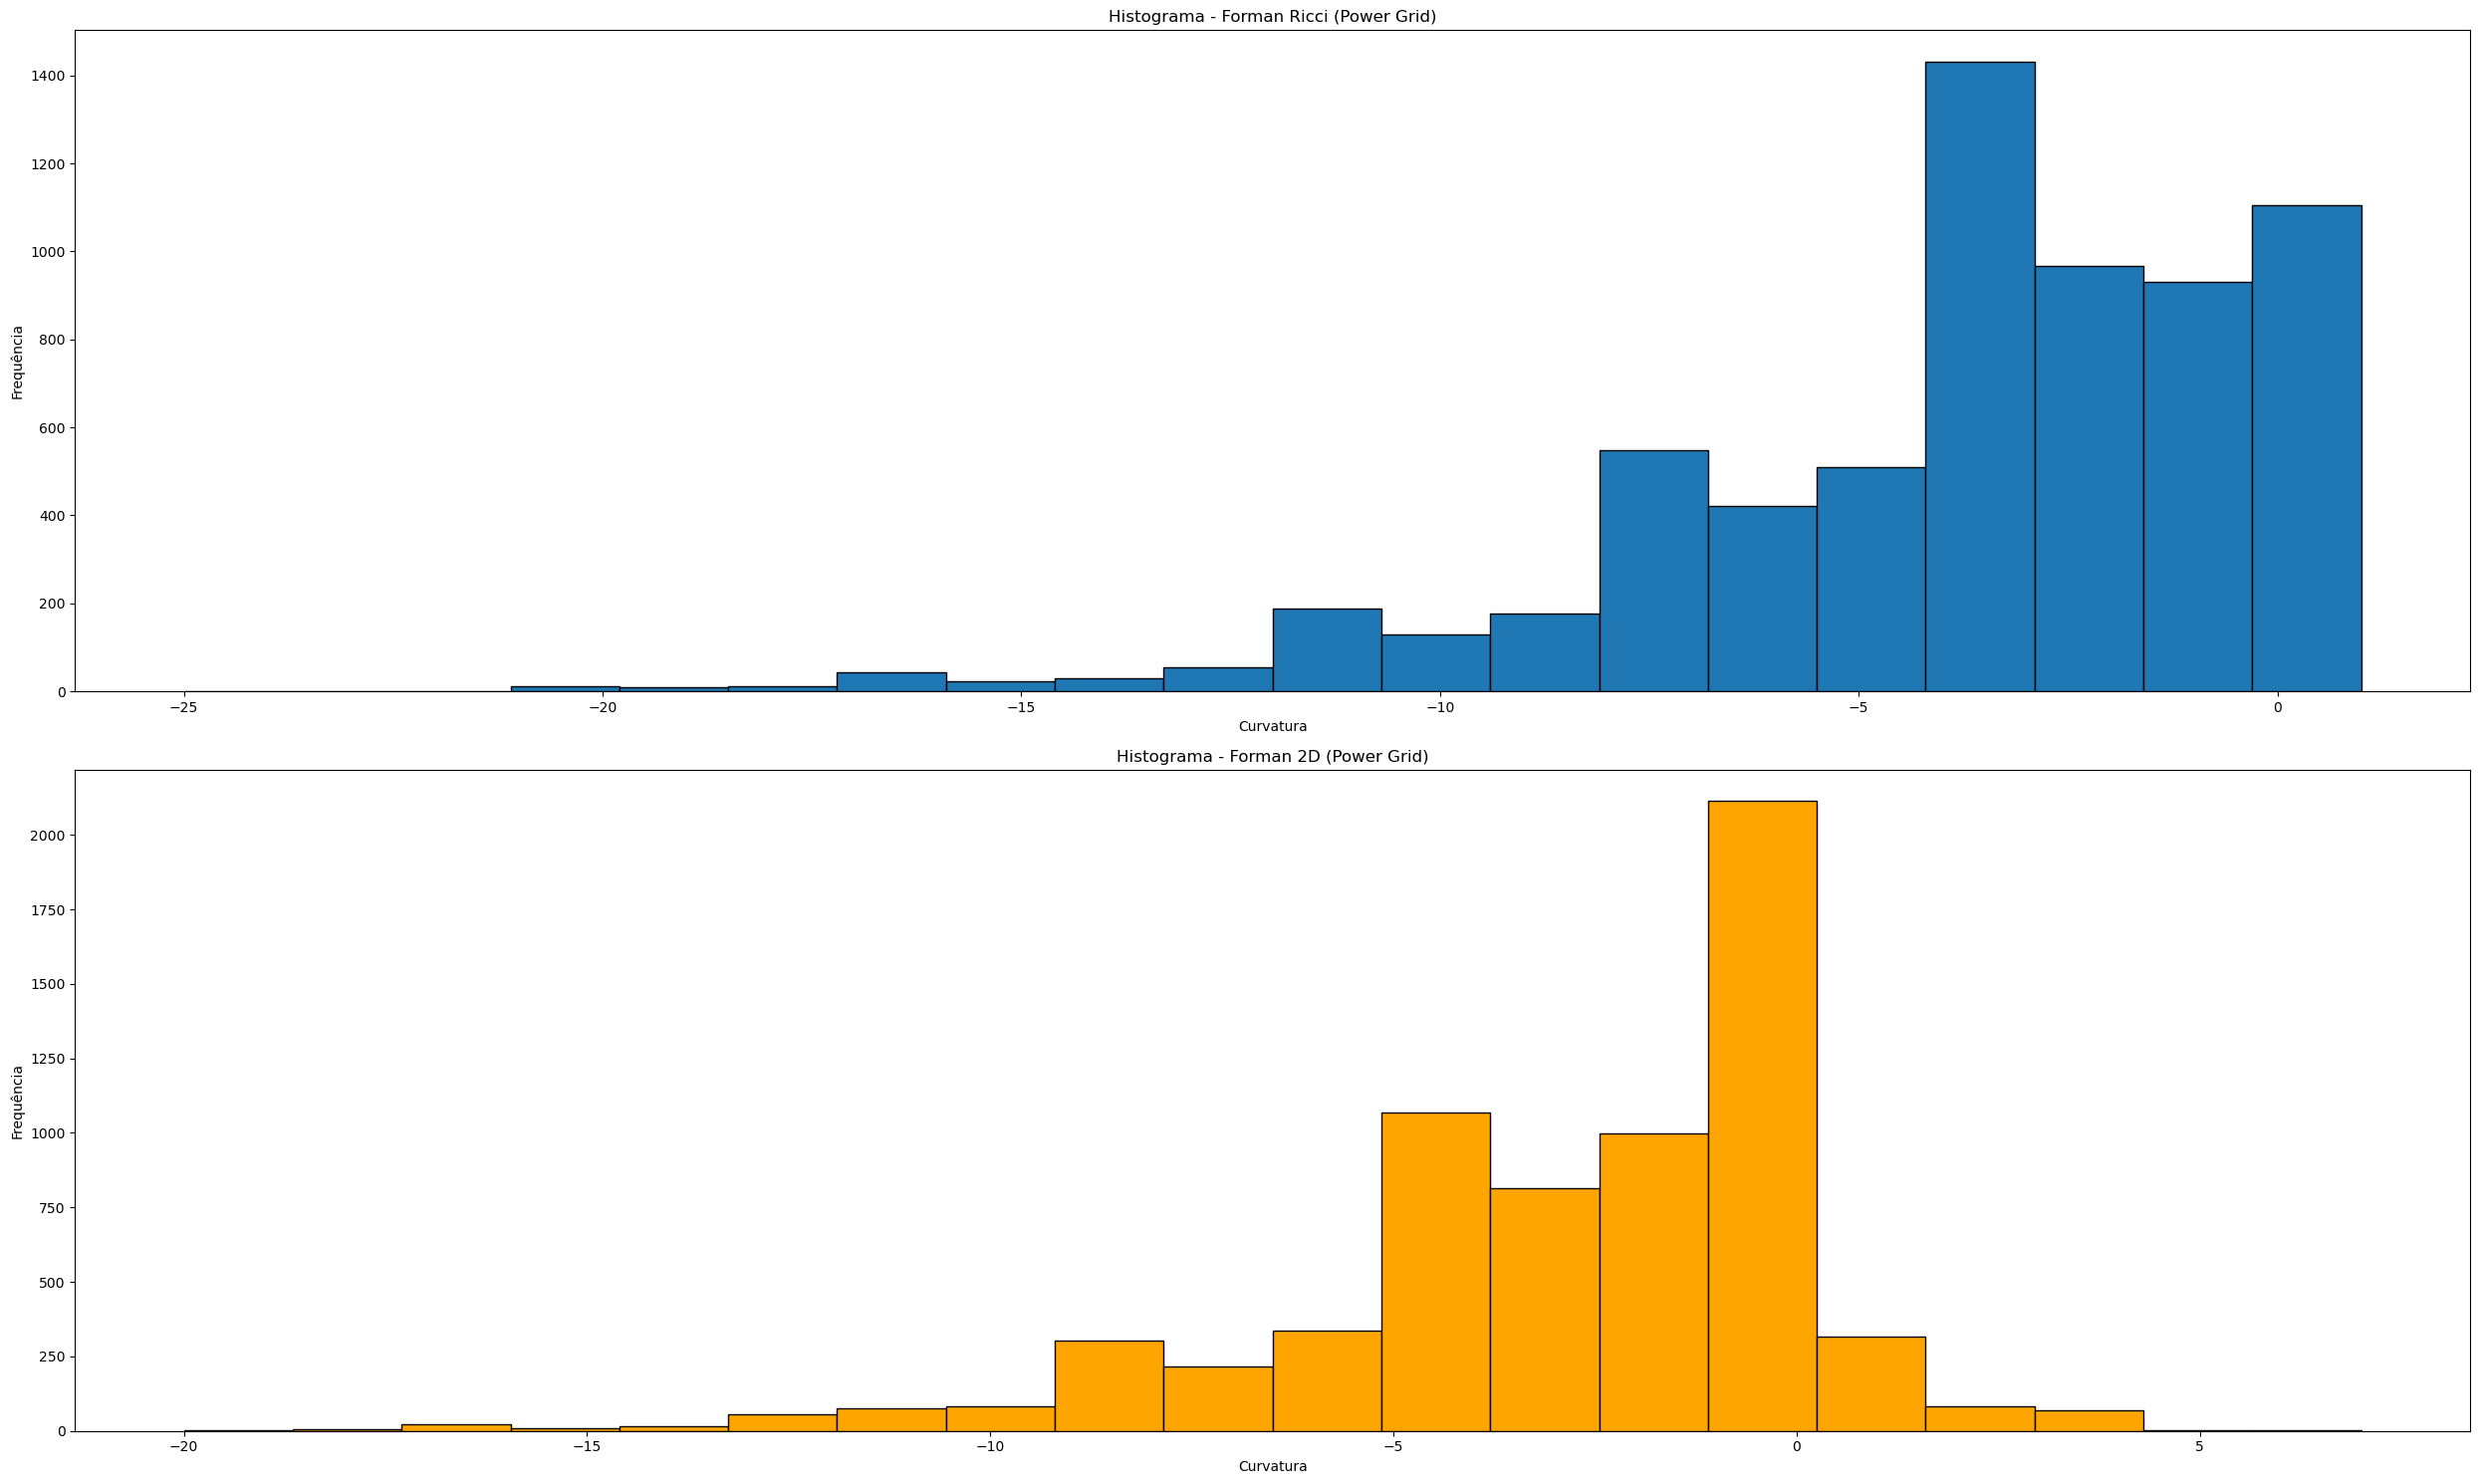

REDE: Power Grid
Número de nós: 4941
Número de arestas: 6593

Média Forman Ricci: -3.741240709843774
Média Forman 2D: -2.85257090853936
Soma Forman 2D: -18807




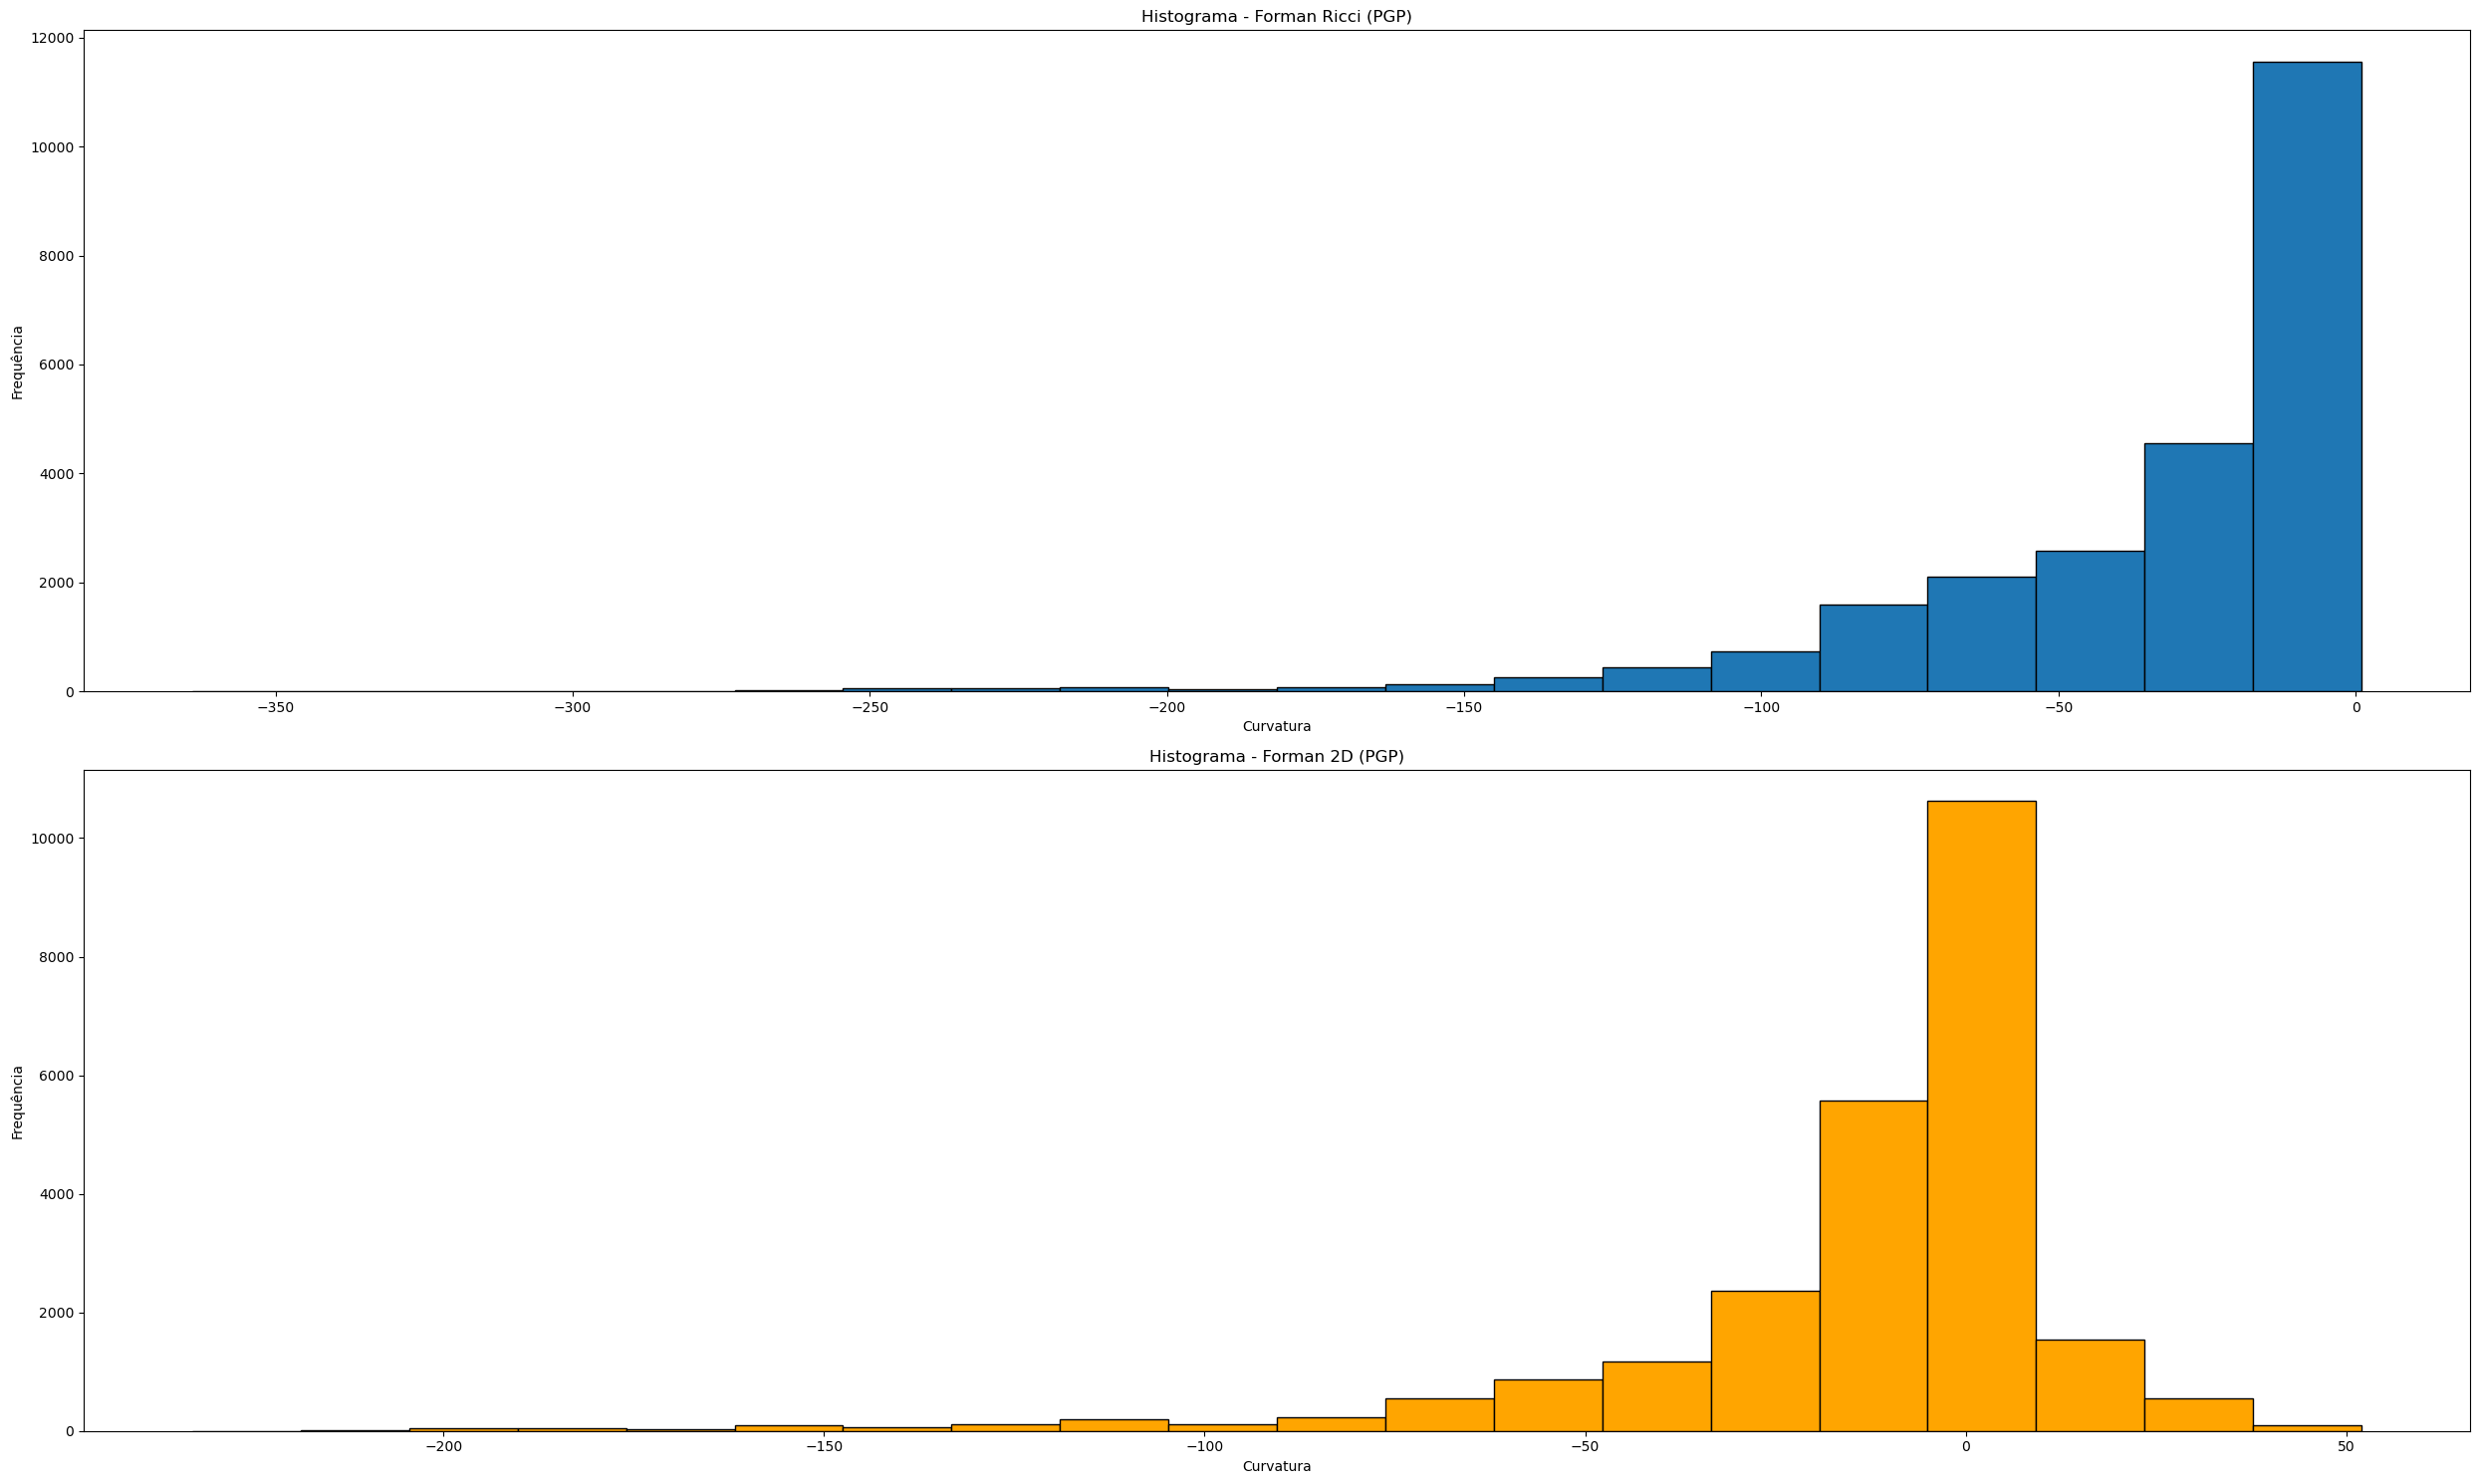

REDE: PGP
Número de nós: 10679
Número de arestas: 24315

Média Forman Ricci: -33.763602714373846
Média Forman 2D: -13.484268969771746
Soma Forman 2D: -327870




In [82]:
# ============================================================
# LISTA DE REDES
# ============================================================

redes = {
    "Erdos-Renyi": erdos,
    "Watts-Strogatz": watts,
    "Barabasi-Albert": barabasi,
    "Karate Club": karate,
    "Autonomous System": autonomous_system,
    "Power Grid": power_grid,
    "PGP": pgp
}

# ============================================================
# LOOP PARA TODAS AS REDES
# ============================================================

for nome_rede, G in redes.items():

    lista_forman = []
    lista_forman_2d = []

    # --------------------------------------------------------
    # Coletando curvaturas
    # --------------------------------------------------------
    for u, v in G.edges():

        if "formanRicci" in G[u][v]:
            lista_forman.append(G[u][v]["formanRicci"])

        if "forman2d" in G[u][v]:
            lista_forman_2d.append(G[u][v]["forman2d"])

    # --------------------------------------------------------
    # Histogramas
    # --------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 15))

    ax1.hist(lista_forman, bins=20, edgecolor='black')
    ax1.set_title(f"Histograma - Forman Ricci ({nome_rede})")
    ax1.set_xlabel("Curvatura")
    ax1.set_ylabel("Frequência")

    ax2.hist(lista_forman_2d,
             bins=20,
             edgecolor='black',
             color='orange')

    ax2.set_title(f"Histograma - Forman 2D ({nome_rede})")
    ax2.set_xlabel("Curvatura")
    ax2.set_ylabel("Frequência")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Estatísticas
    # --------------------------------------------------------
    media_forman = np.mean(lista_forman)
    media_forman_2d = np.mean(lista_forman_2d)
    soma_forman_2d = np.sum(lista_forman_2d)

    print("=" * 50)
    print(f"REDE: {nome_rede}")
    print("=" * 50)

    print(f"Número de nós: {G.number_of_nodes()}")
    print(f"Número de arestas: {G.number_of_edges()}")

    print(f"\nMédia Forman Ricci: {media_forman}")
    print(f"Média Forman 2D: {media_forman_2d}")
    print(f"Soma Forman 2D: {soma_forman_2d}")

    # --------------------------------------------------------
    # Parâmetros específicos das redes
    # --------------------------------------------------------
    if nome_rede == "Erdos-Renyi":
        print(f"p (probabilidade): {p}")

    elif nome_rede == "Watts-Strogatz":
        print("Modelo Watts-Strogatz")

    elif nome_rede == "Barabasi-Albert":
        print("Modelo Barabasi-Albert")

    print("\n")

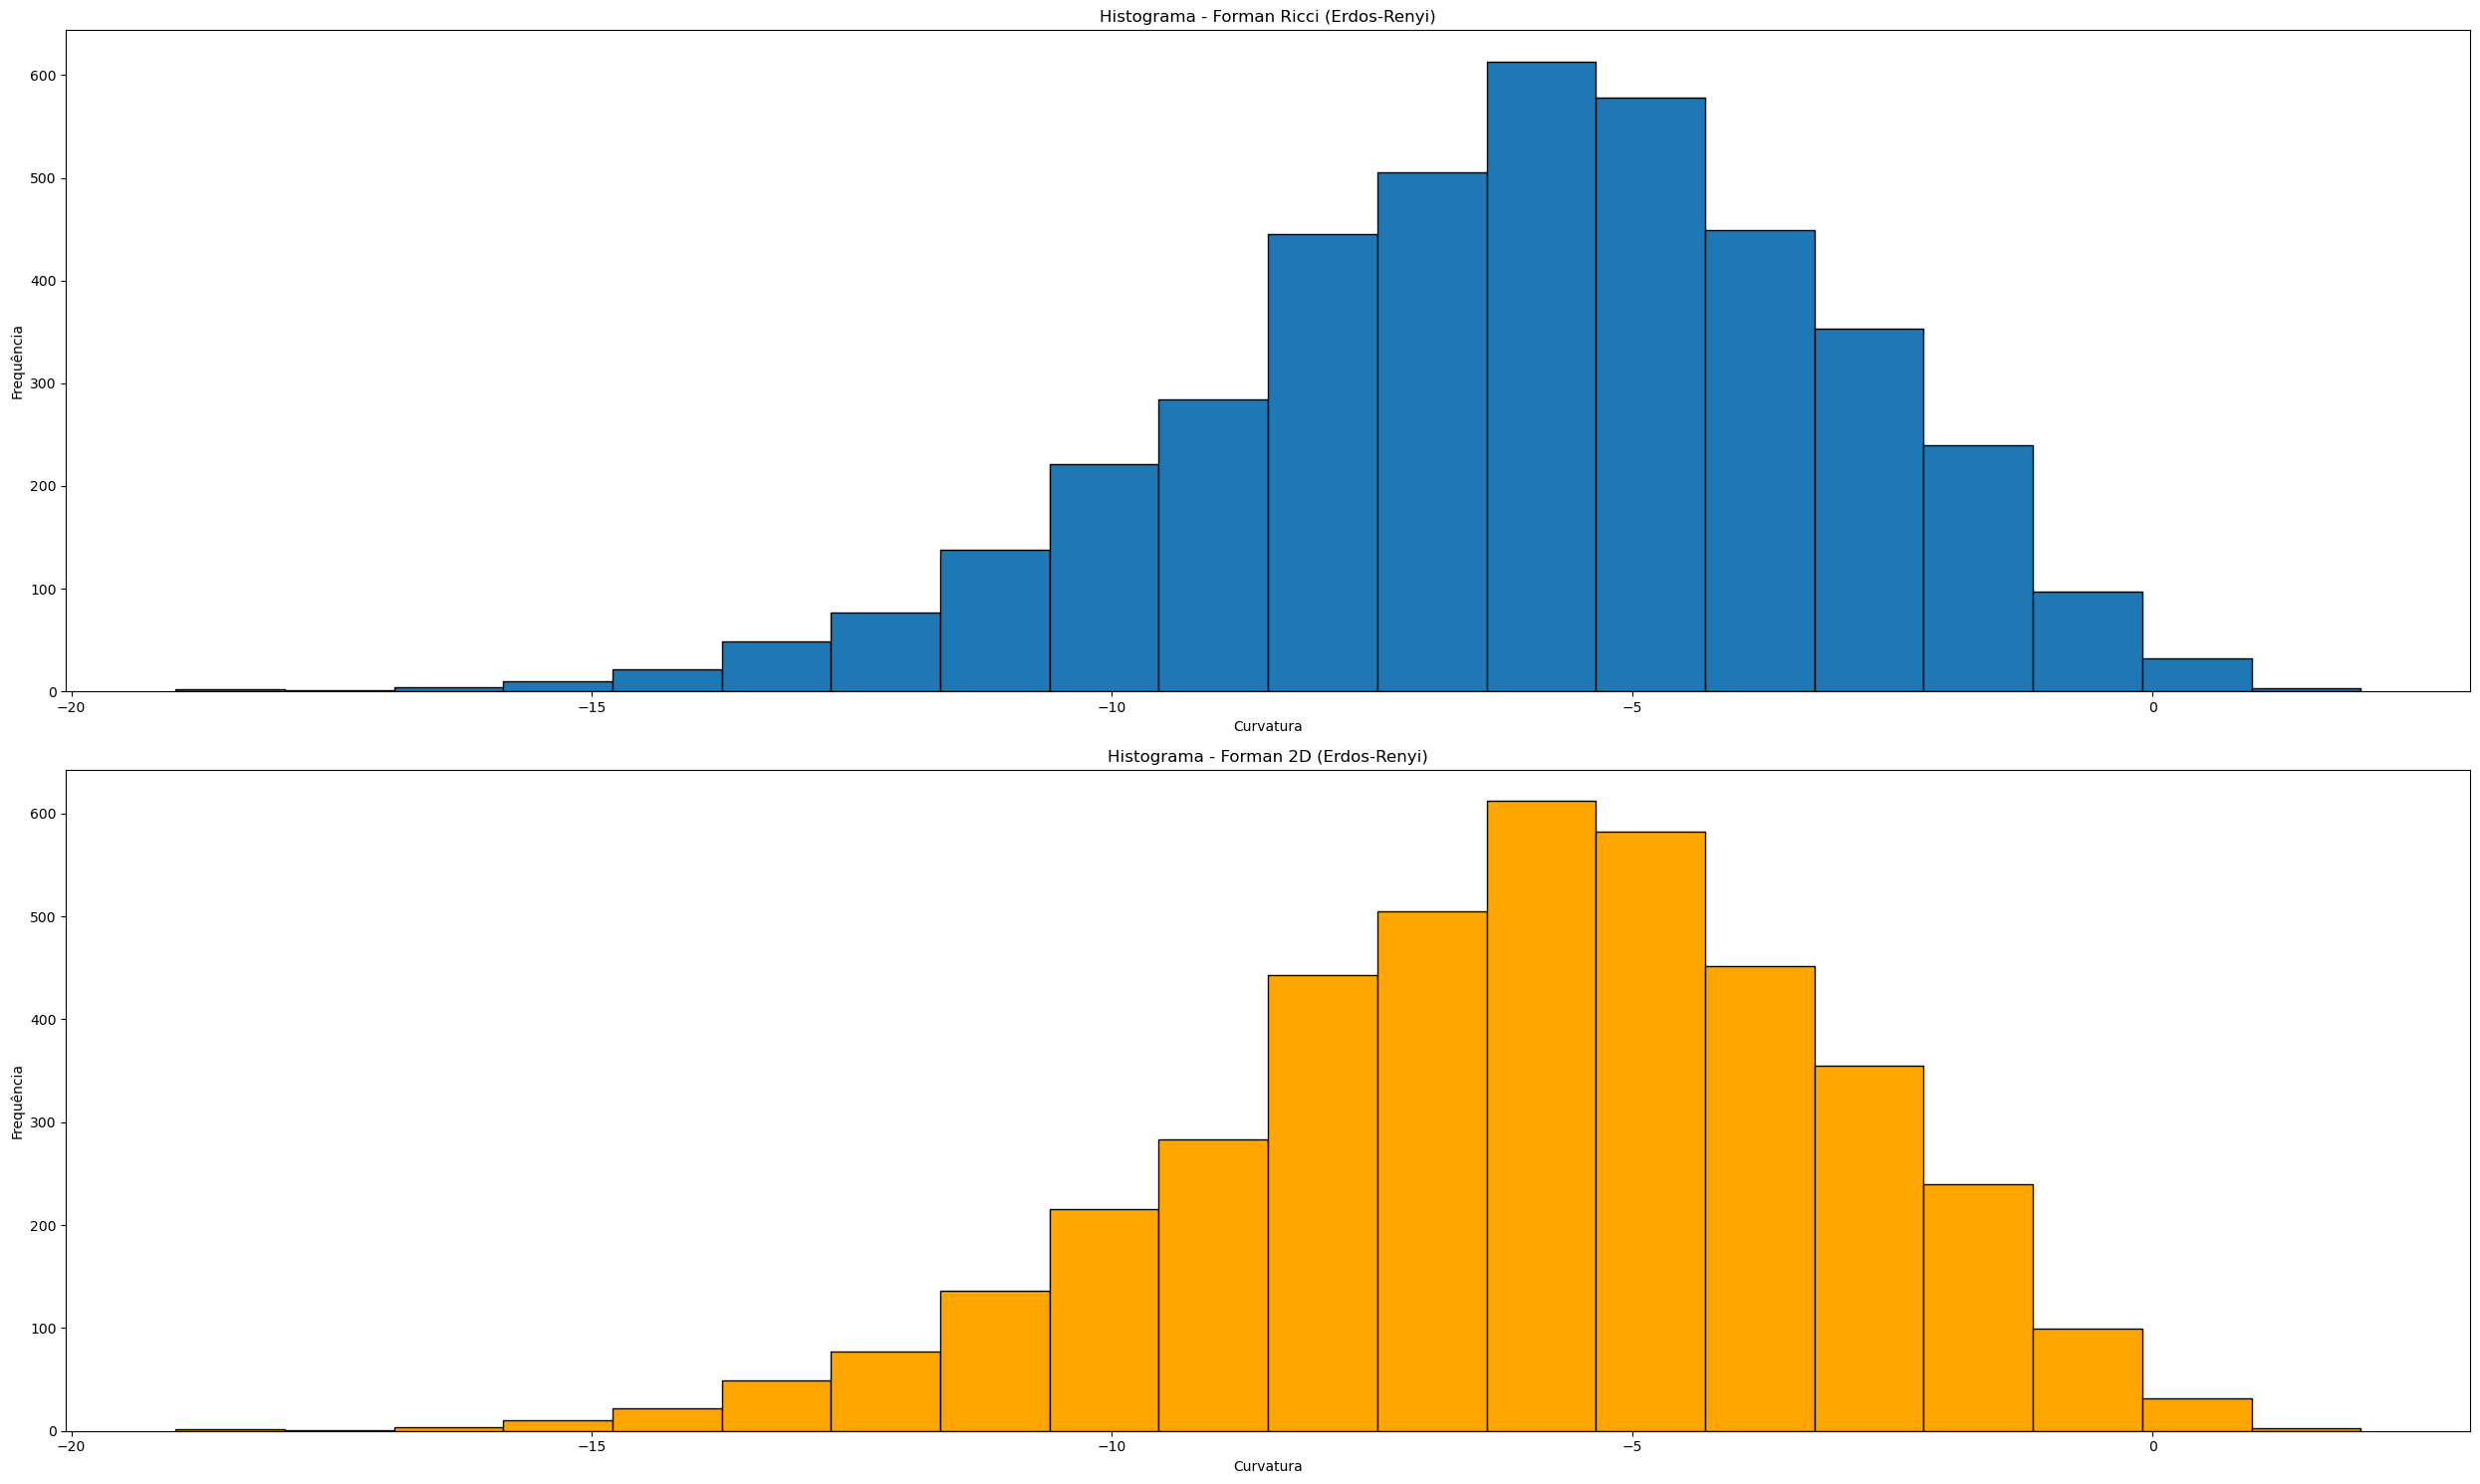

REDE: Erdos-Renyi
Número de nós: 2000
Número de arestas: 4123

Média Forman Ricci: -6.187727382973563
Média Forman 2D: -6.172447247150133
Soma Forman 2D: -25449
Característica de Euler: -2116.0
Razão soma/Euler: 12.026937618147448
p (probabilidade): 0.002001000500250125




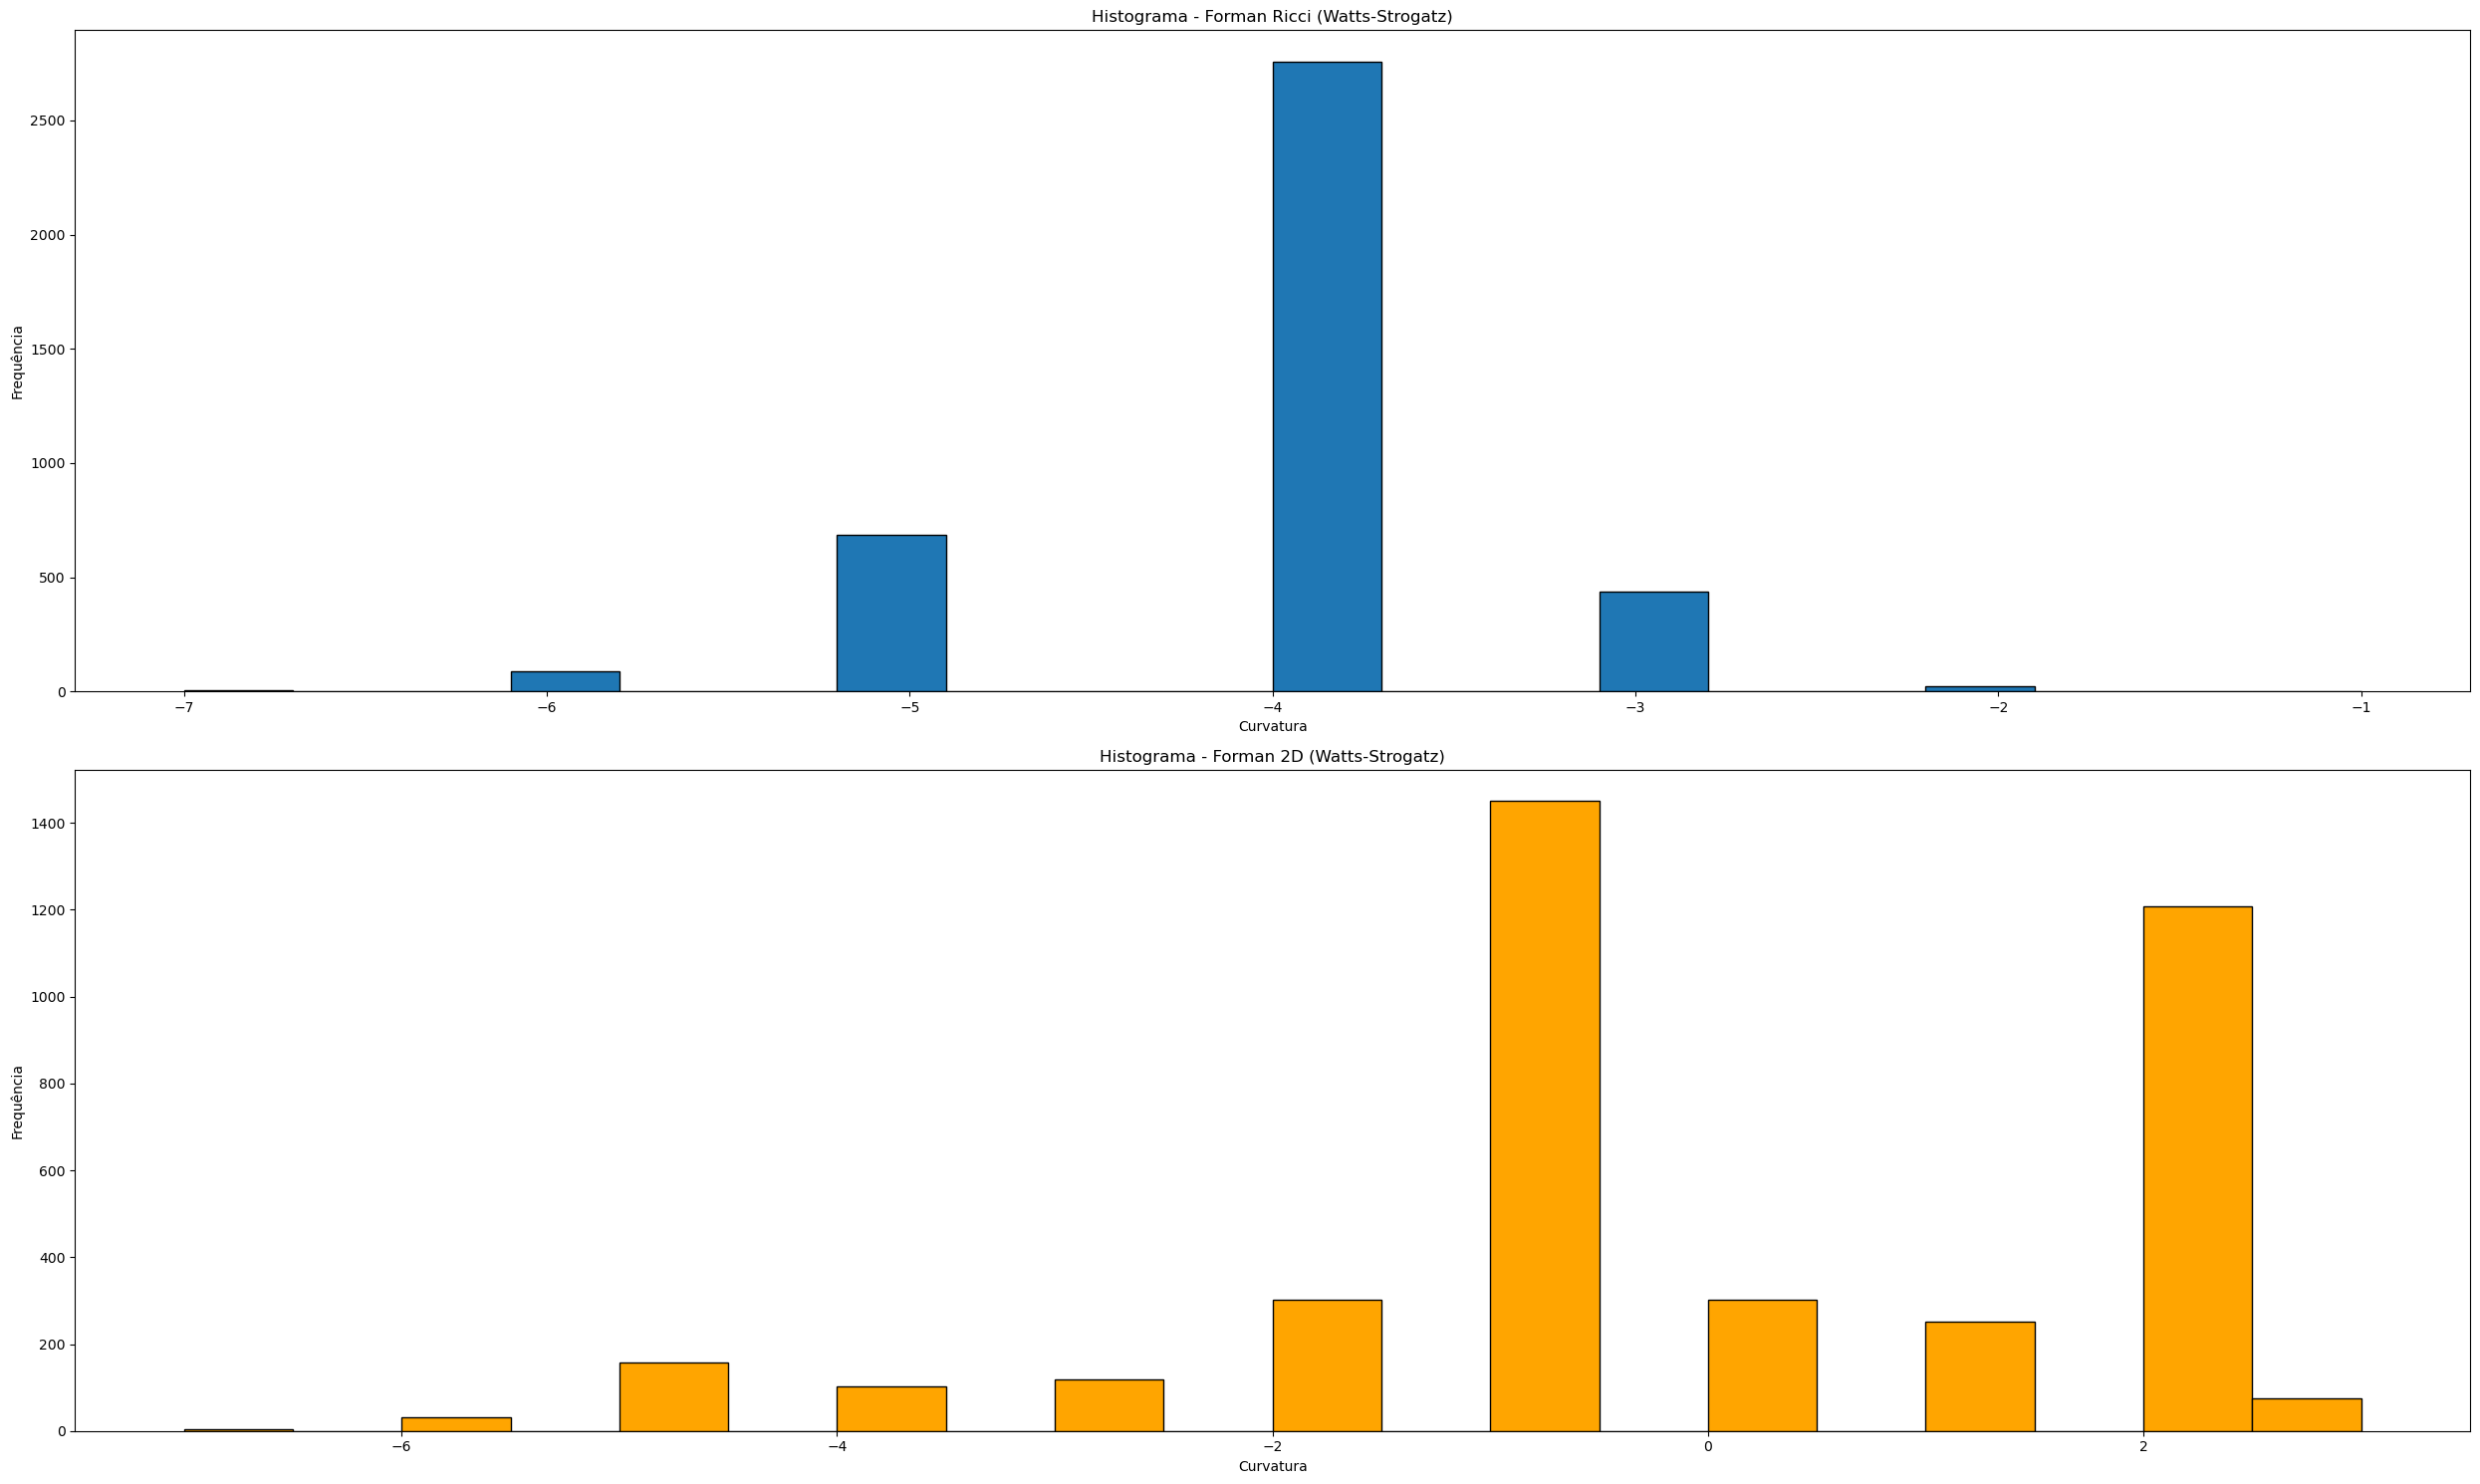

REDE: Watts-Strogatz
Número de nós: 2000
Número de arestas: 4000

Média Forman Ricci: -4.0995
Média Forman 2D: -0.234
Soma Forman 2D: -936
Característica de Euler: -282.0
Razão soma/Euler: 3.3191489361702127
Modelo Watts-Strogatz




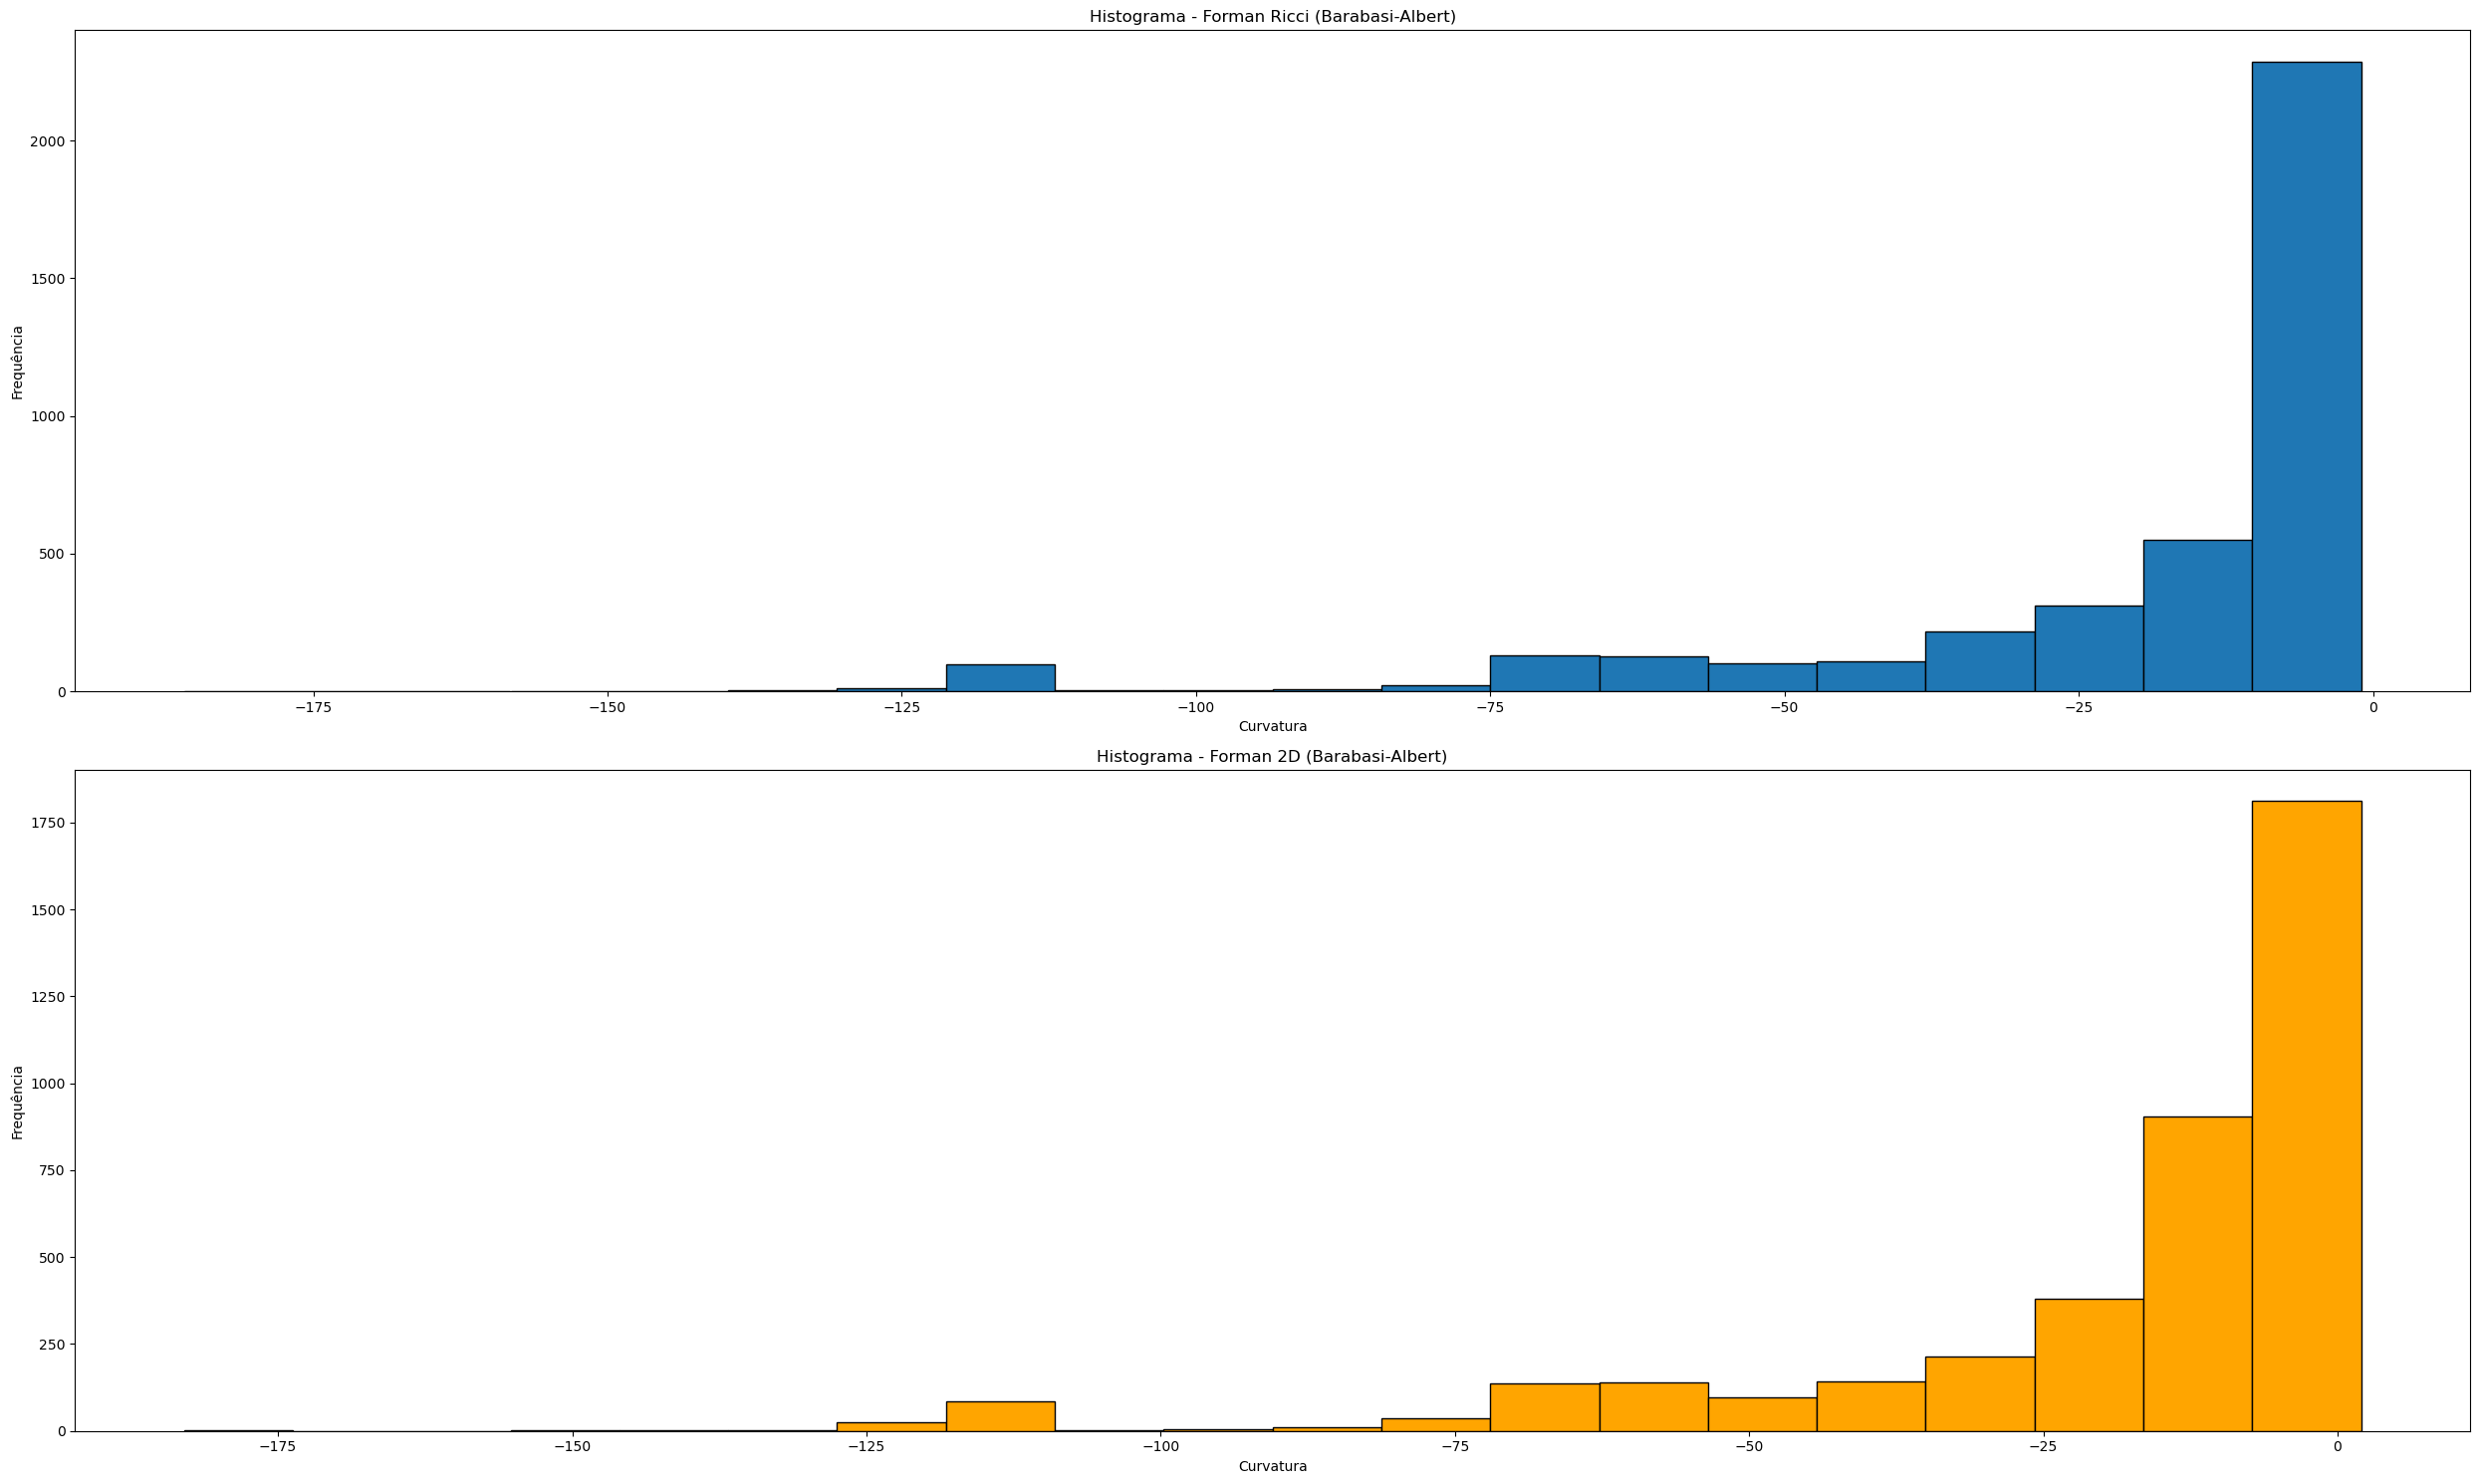

REDE: Barabasi-Albert
Número de nós: 2000
Número de arestas: 3996

Média Forman Ricci: -19.44144144144144
Média Forman 2D: -19.283783783783782
Soma Forman 2D: -77058
Característica de Euler: -1926.0
Razão soma/Euler: 40.00934579439252
Modelo Barabasi-Albert




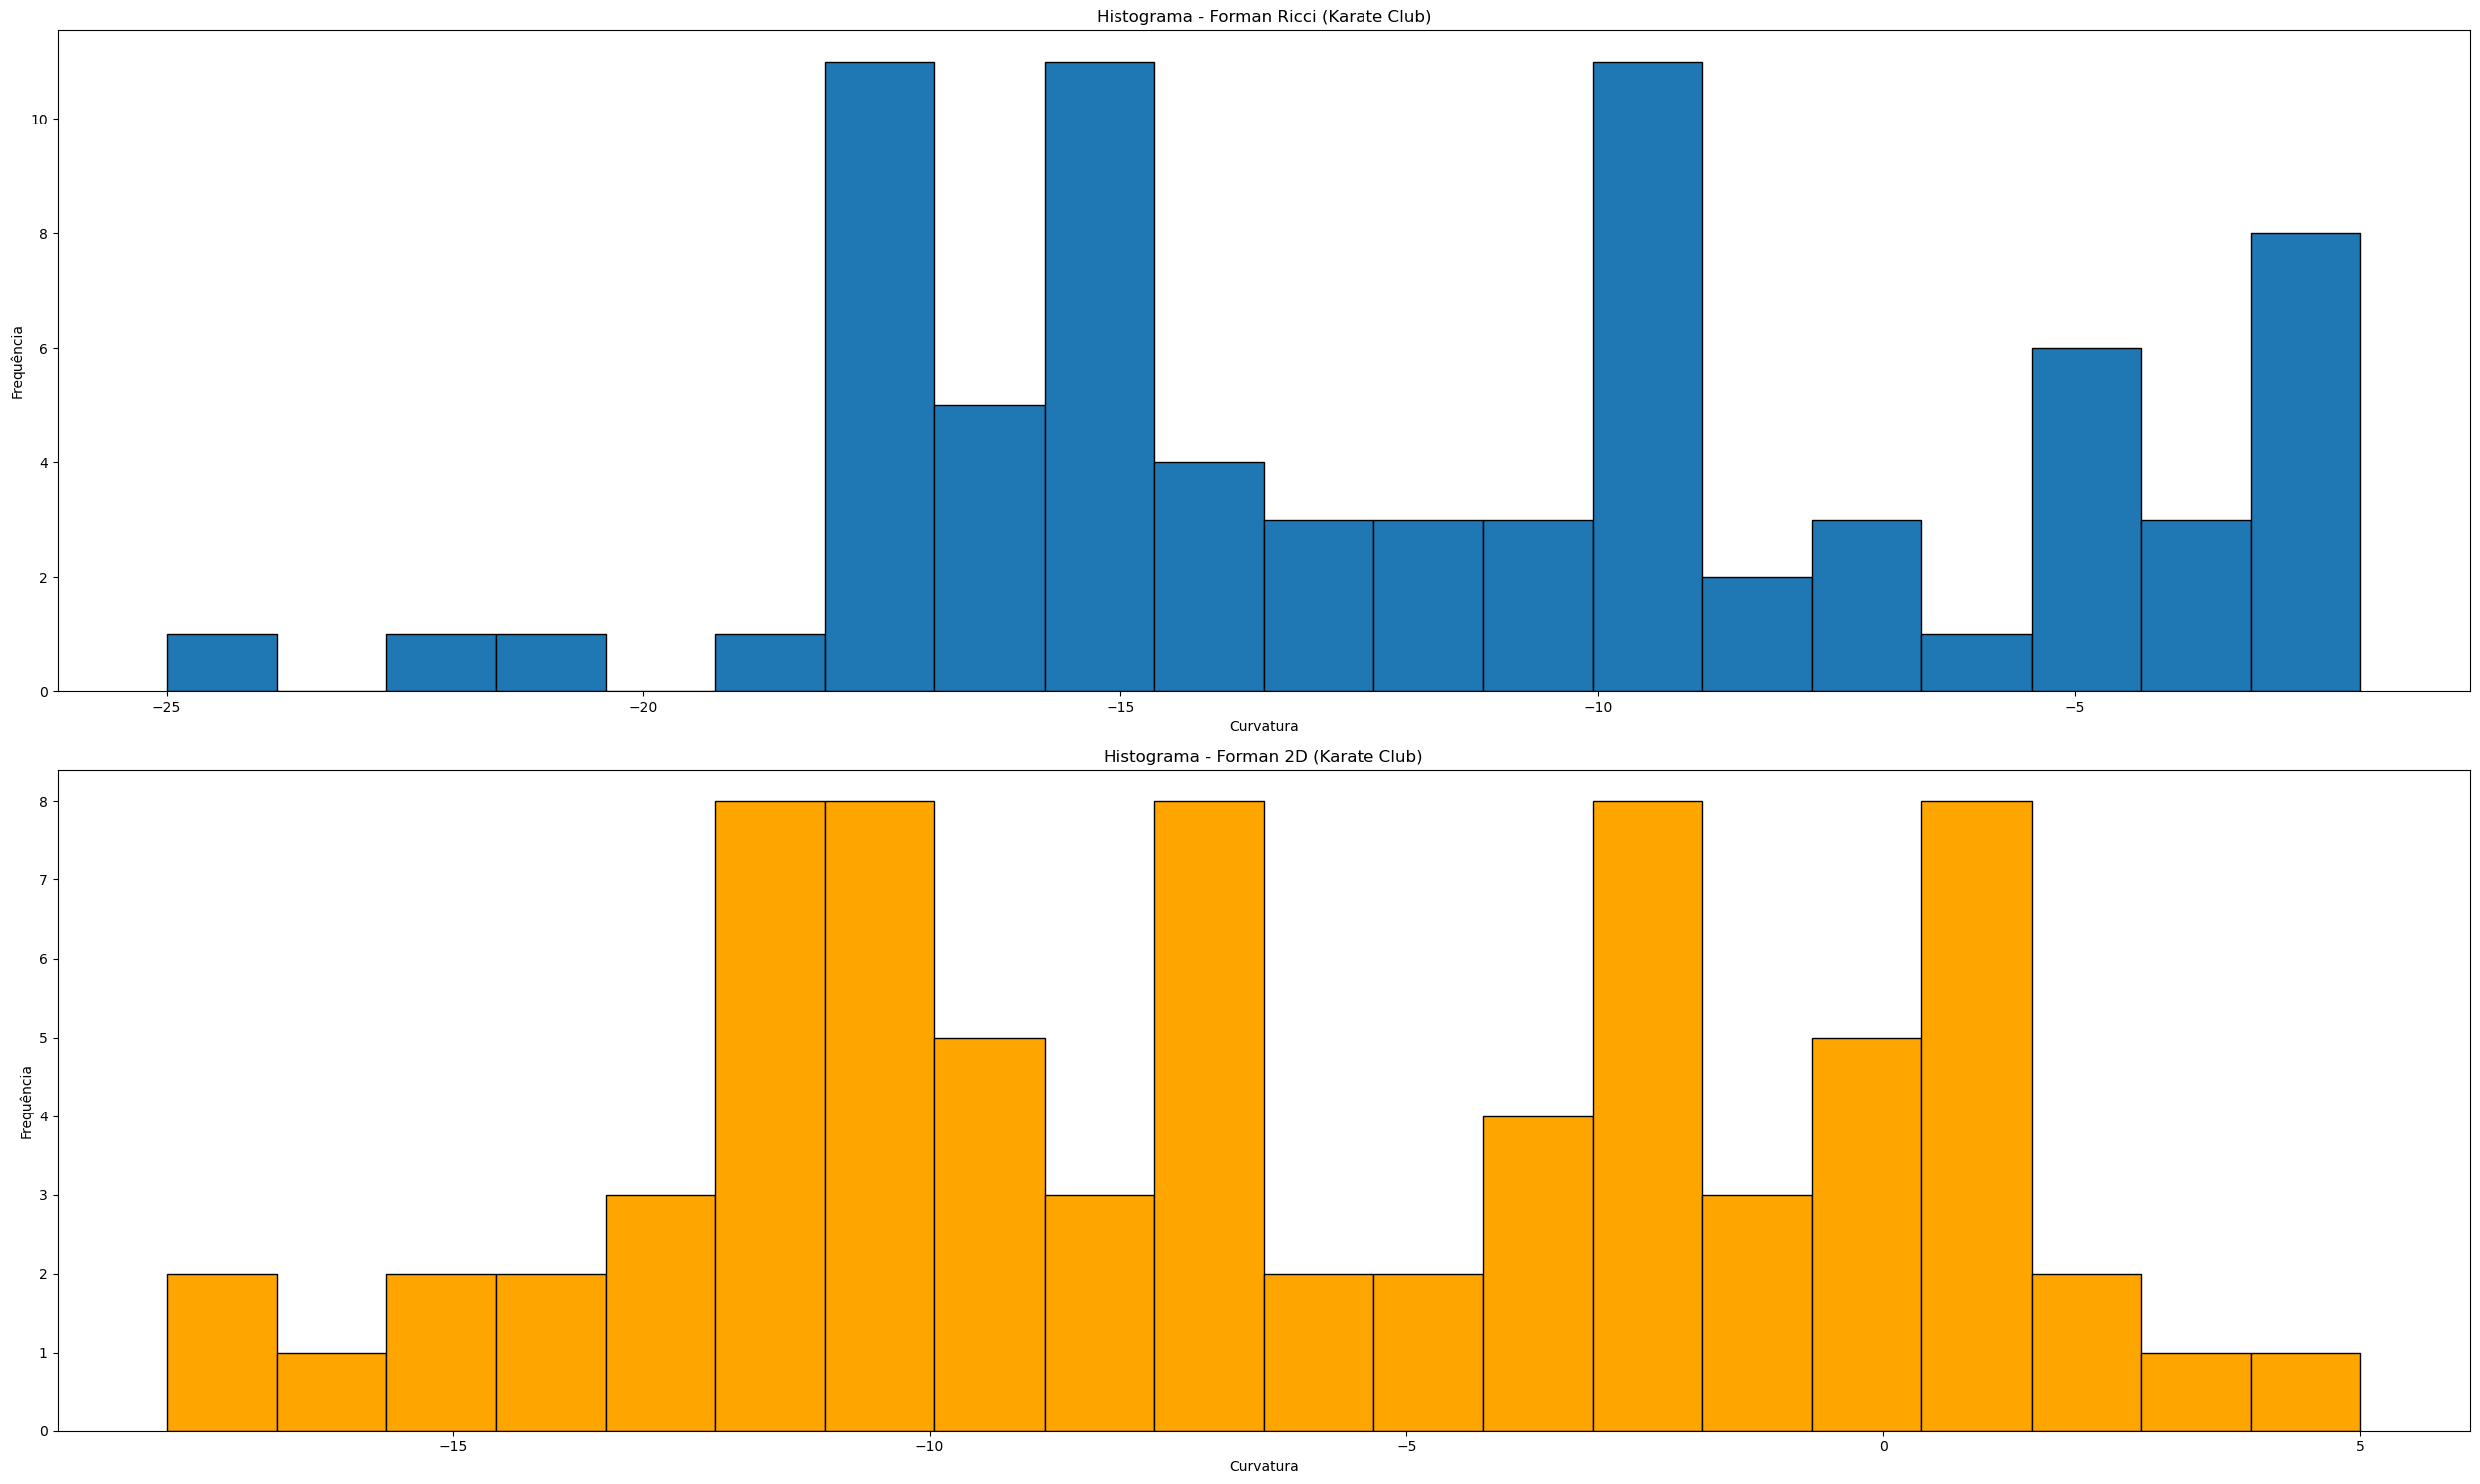

REDE: Karate Club
Número de nós: 34
Número de arestas: 78

Média Forman Ricci: -11.538461538461538
Média Forman 2D: -6.346153846153846
Soma Forman 2D: -495
Característica de Euler: 1.0
Razão soma/Euler: -495.0




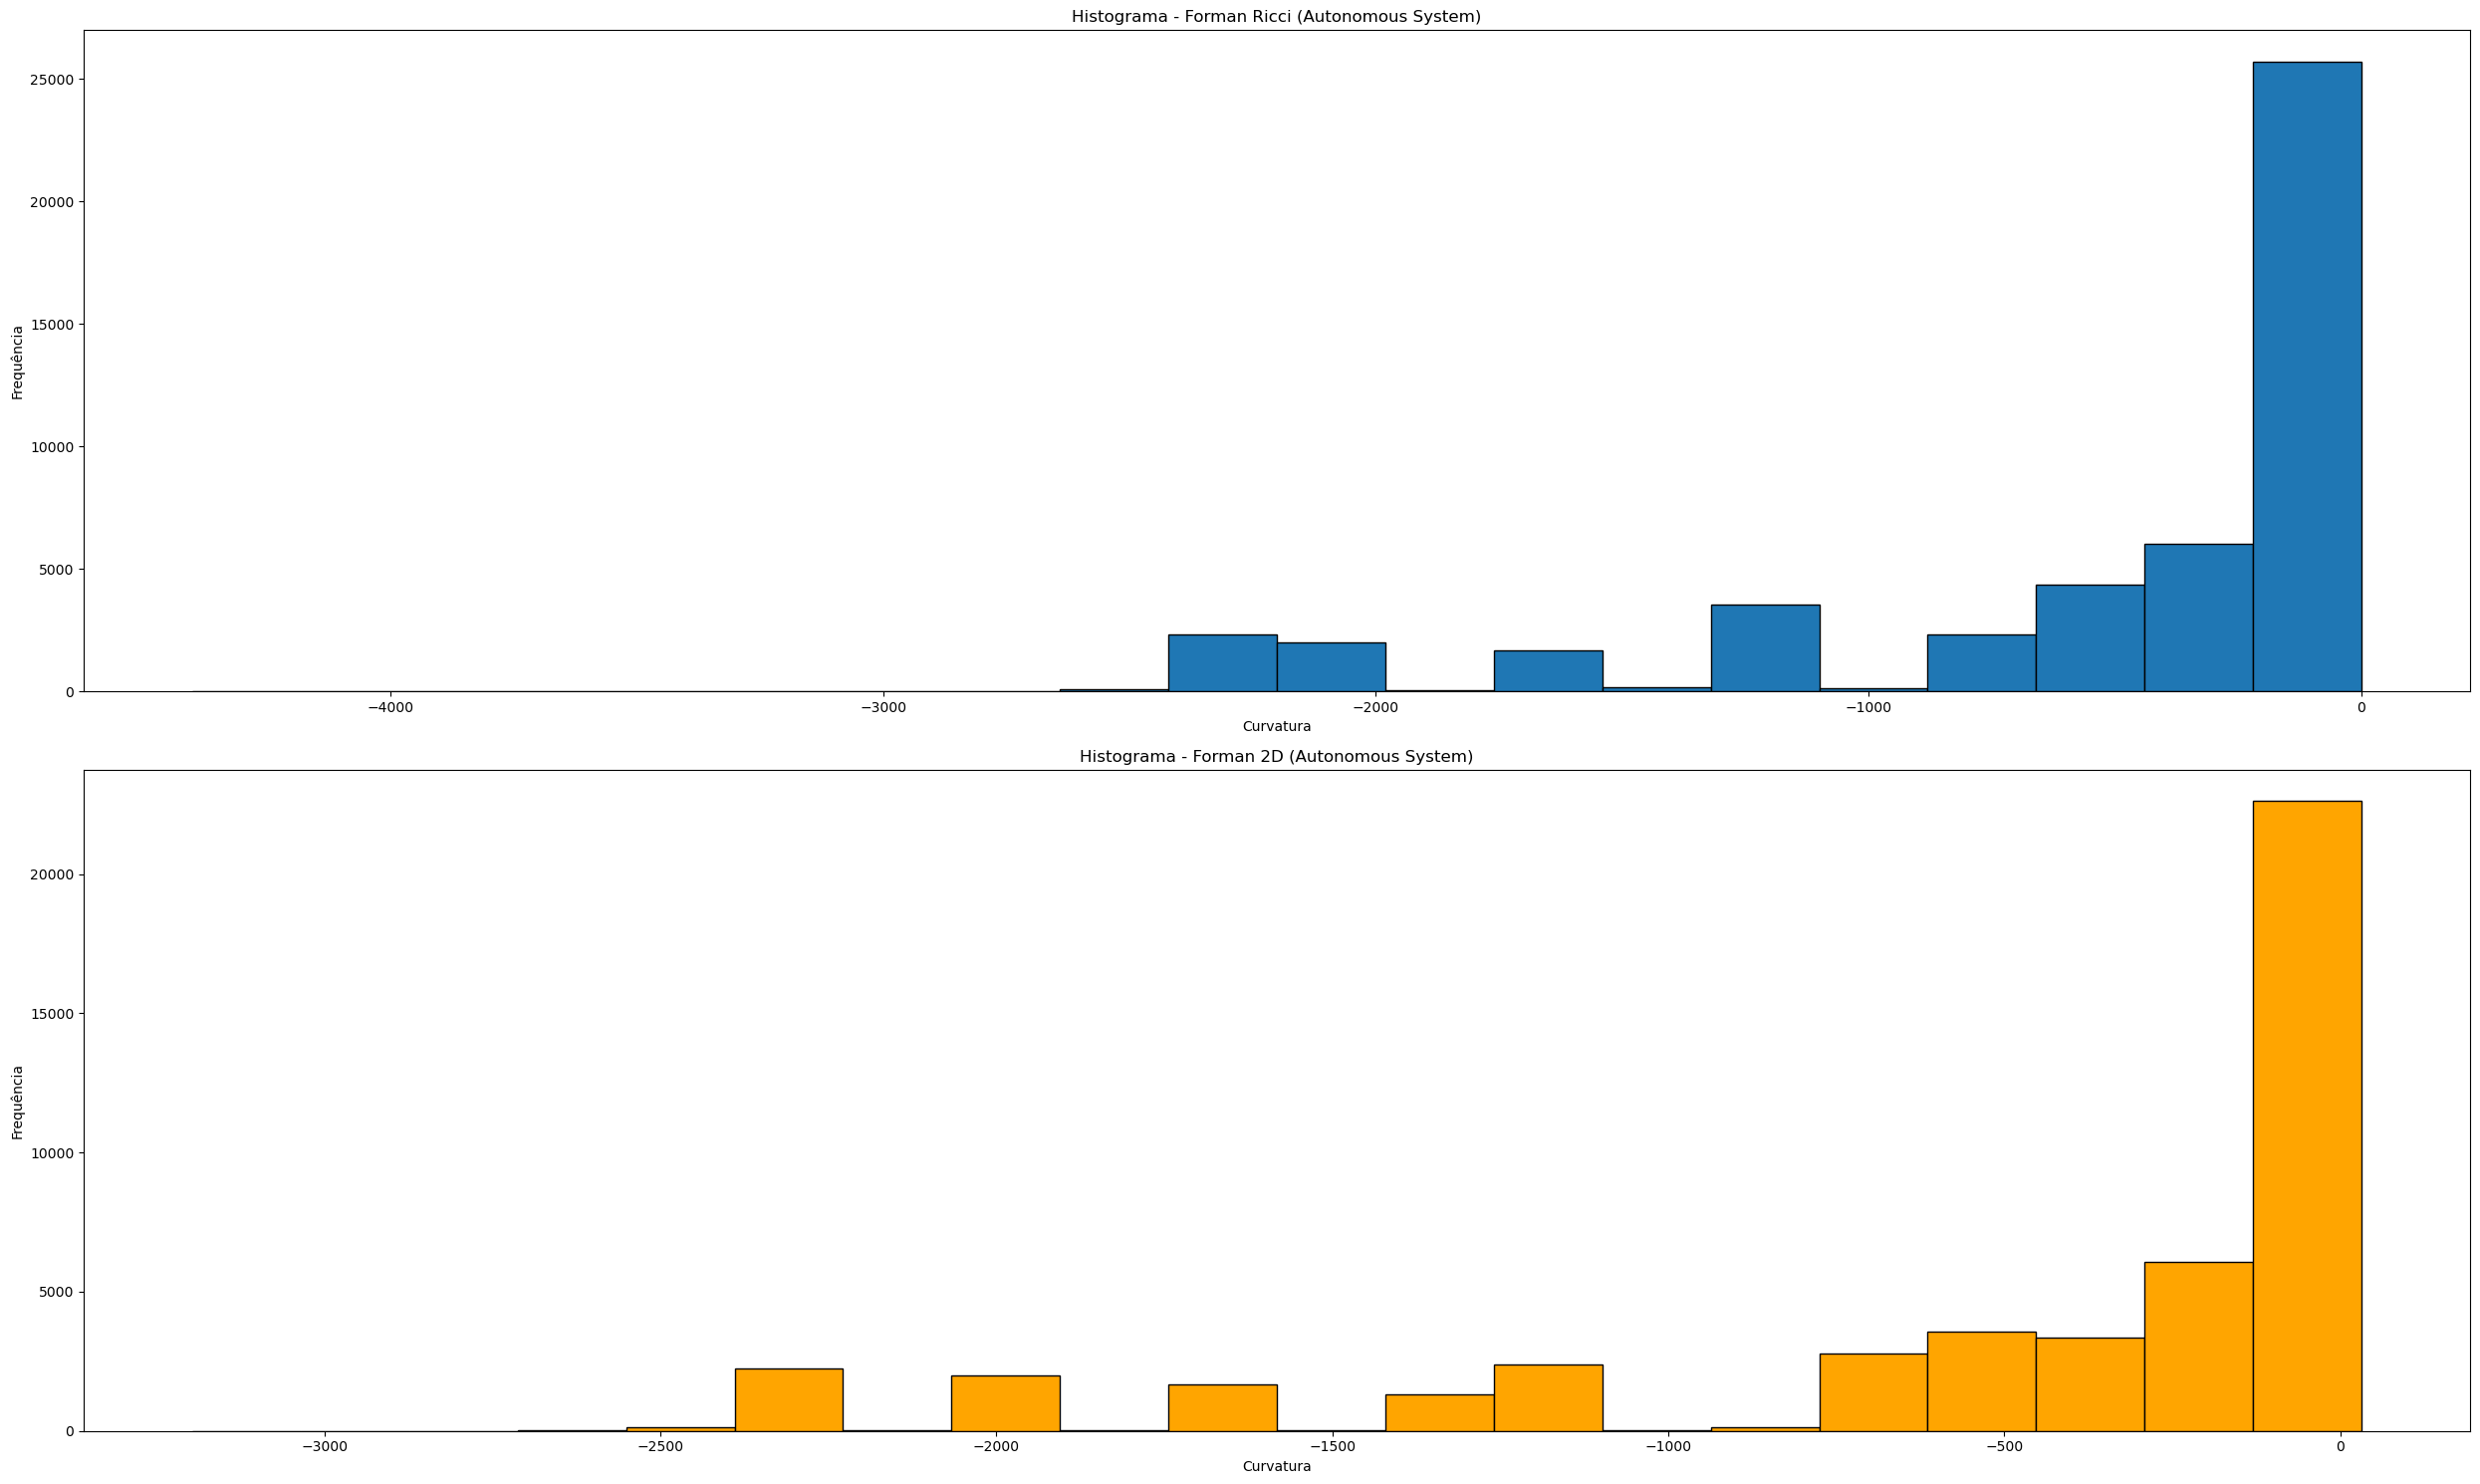

REDE: Autonomous System
Número de nós: 22962
Número de arestas: 48435

Média Forman Ricci: -518.9224321255291
Média Forman 2D: -510.2126767833179
Soma Forman 2D: -24712151
Característica de Euler: 21400.0
Razão soma/Euler: -1154.7734112149533




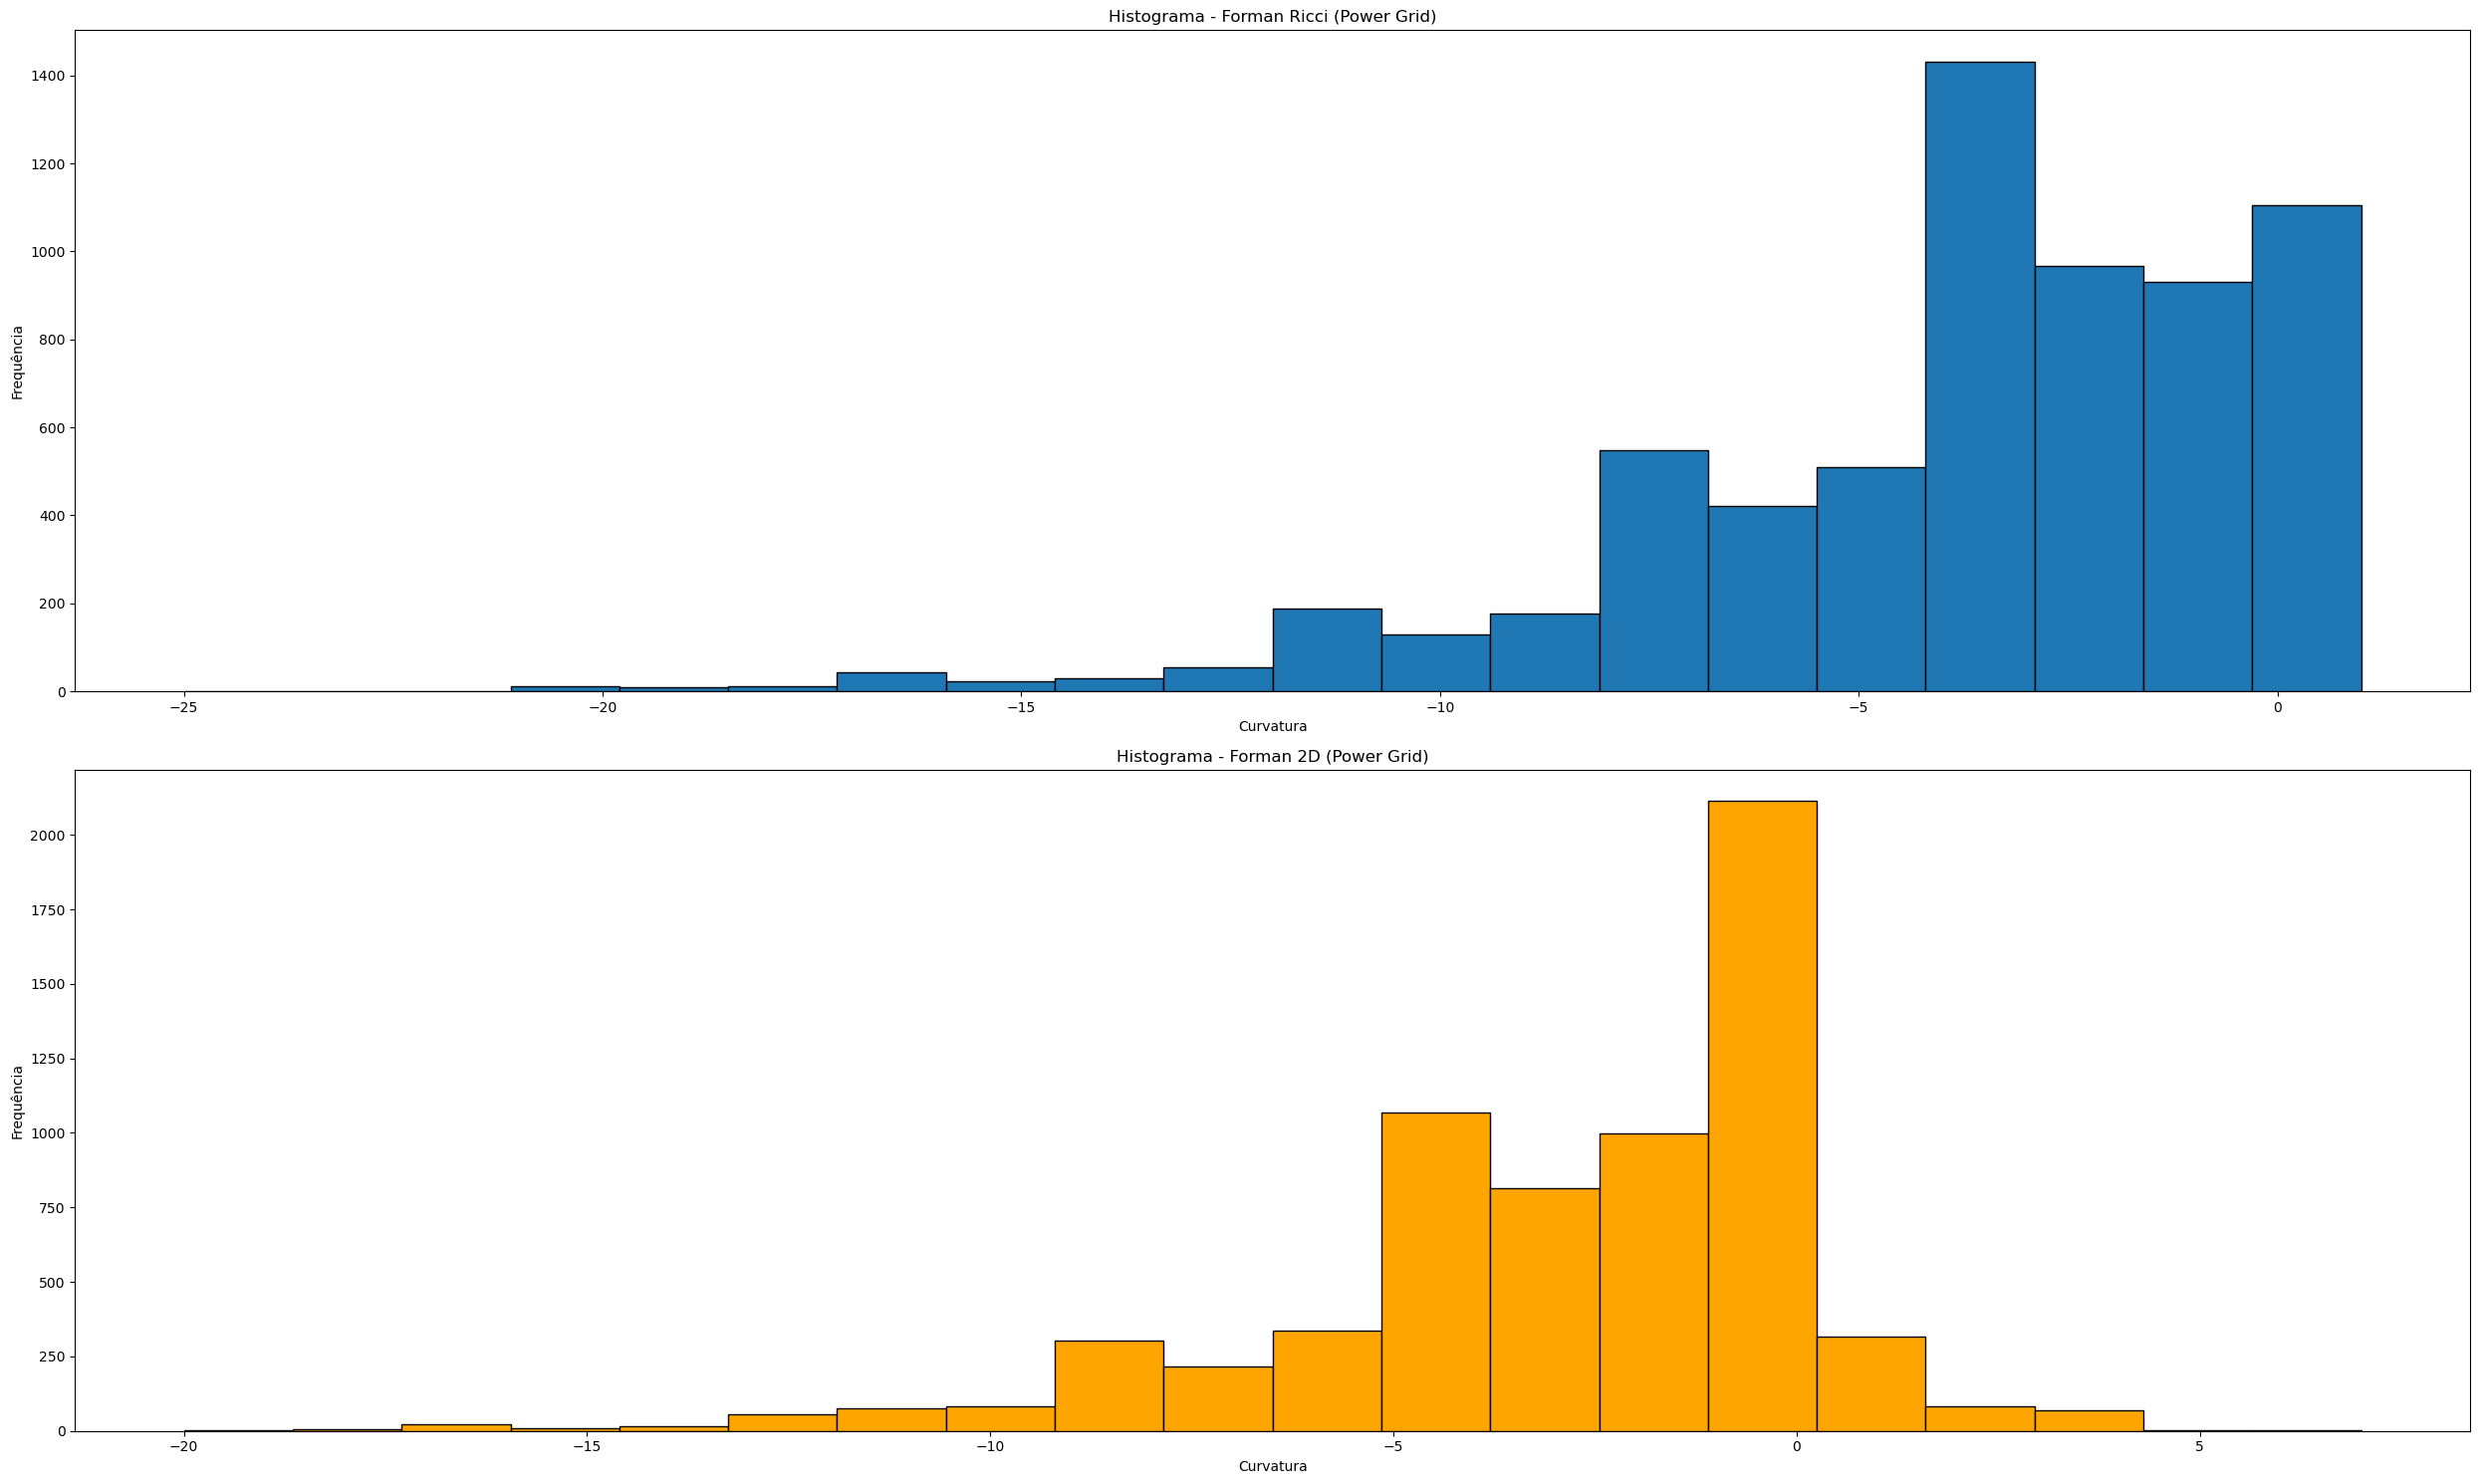

REDE: Power Grid
Número de nós: 4941
Número de arestas: 6593

Média Forman Ricci: -3.741240709843774
Média Forman 2D: -2.85257090853936
Soma Forman 2D: -18807
Característica de Euler: -1001.0
Razão soma/Euler: 18.78821178821179




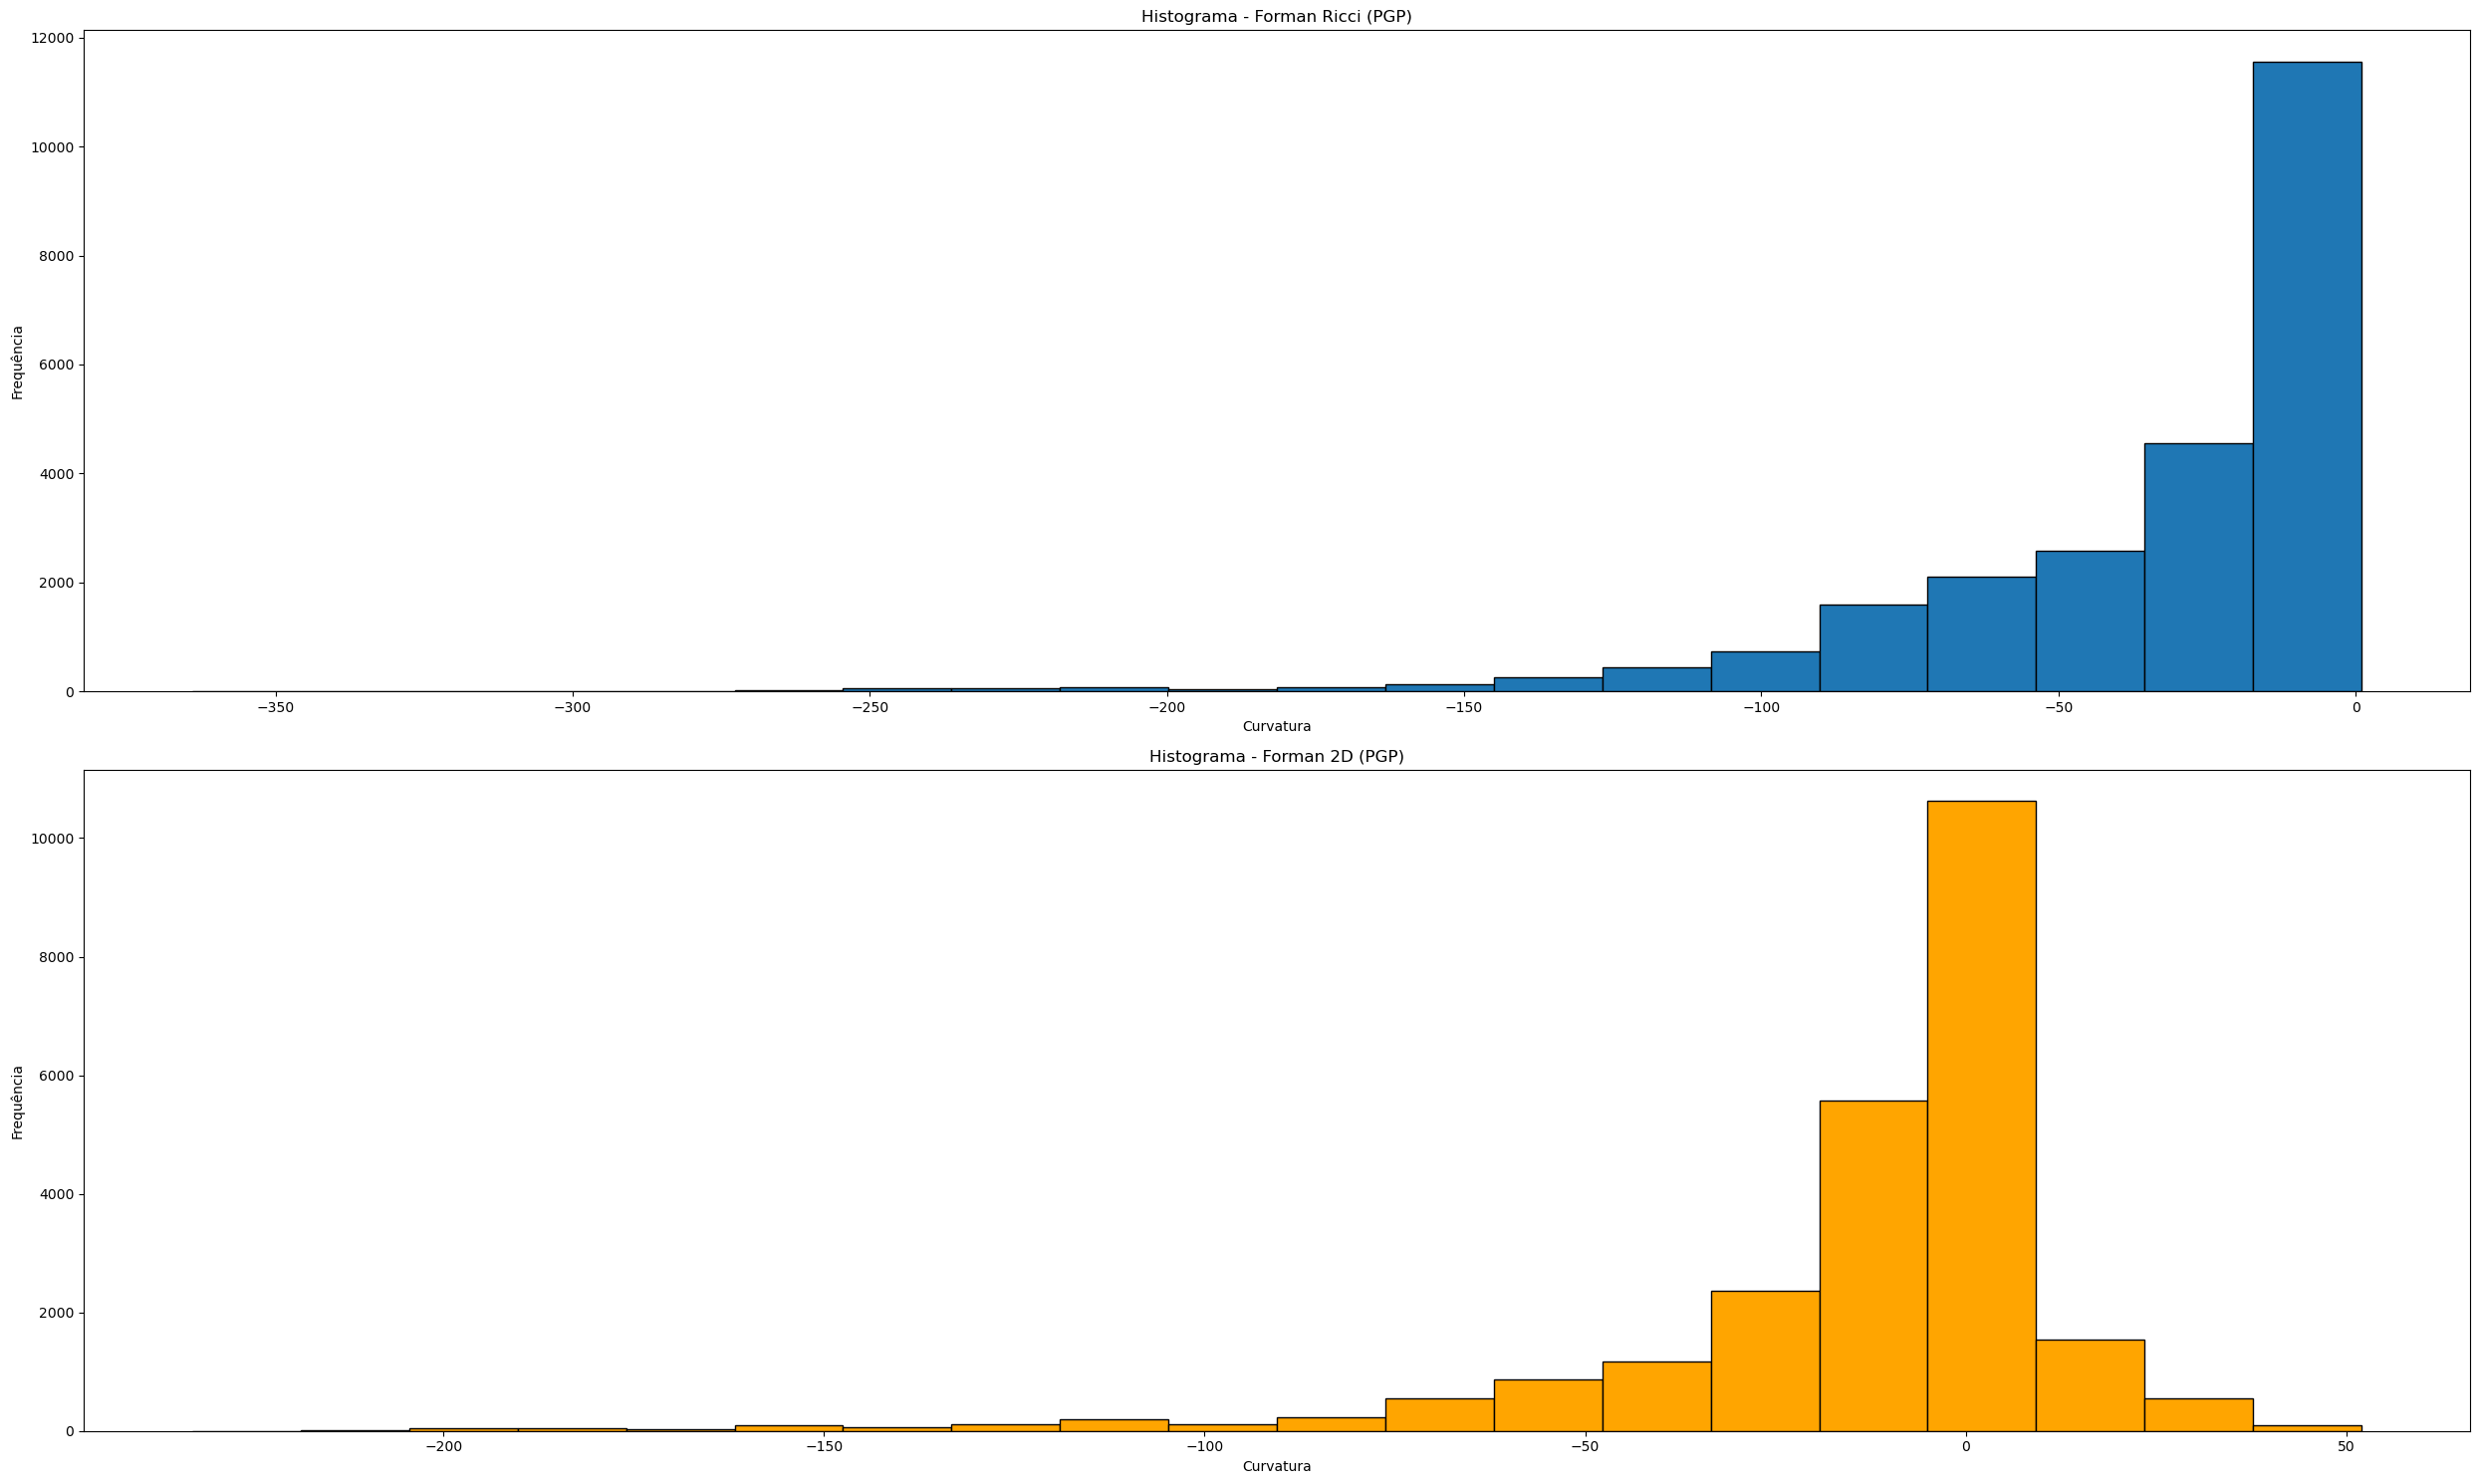

REDE: PGP
Número de nós: 10679
Número de arestas: 24315

Média Forman Ricci: -33.763602714373846
Média Forman 2D: -13.484268969771746
Soma Forman 2D: -327870
Característica de Euler: 41152.0
Razão soma/Euler: -7.96729199066874




In [83]:
# ============================================================
# LISTA DE REDES
# ============================================================

redes = {
    "Erdos-Renyi": erdos,
    "Watts-Strogatz": watts,
    "Barabasi-Albert": barabasi,
    "Karate Club": karate,
    "Autonomous System": autonomous_system,
    "Power Grid": power_grid,
    "PGP": pgp
}

# ============================================================
# LOOP PARA TODAS AS REDES
# ============================================================

for nome_rede, G in redes.items():

    lista_forman = []
    lista_forman_2d = []

    # --------------------------------------------------------
    # Coletando curvaturas
    # --------------------------------------------------------
    for u, v in G.edges():

        if "formanRicci" in G[u][v]:
            lista_forman.append(G[u][v]["formanRicci"])

        if "forman2d" in G[u][v]:
            lista_forman_2d.append(G[u][v]["forman2d"])

    # --------------------------------------------------------
    # Histogramas
    # --------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 15))

    ax1.hist(lista_forman, bins=20, edgecolor='black')
    ax1.set_title(f"Histograma - Forman Ricci ({nome_rede})")
    ax1.set_xlabel("Curvatura")
    ax1.set_ylabel("Frequência")

    ax2.hist(lista_forman_2d,
             bins=20,
             edgecolor='black',
             color='orange')

    ax2.set_title(f"Histograma - Forman 2D ({nome_rede})")
    ax2.set_xlabel("Curvatura")
    ax2.set_ylabel("Frequência")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Estatísticas
    # --------------------------------------------------------
    media_forman = np.mean(lista_forman)
    media_forman_2d = np.mean(lista_forman_2d)
    soma_forman_2d = np.sum(lista_forman_2d)

    # --------------------------------------------------------
    # Característica de Euler
    # --------------------------------------------------------
    euler = (
        G.number_of_nodes()
        - G.number_of_edges()
        + sum(nx.triangles(G).values()) / 3
    )

    razao = soma_forman_2d / euler

    # --------------------------------------------------------
    # Impressão dos resultados
    # --------------------------------------------------------
    print("=" * 50)
    print(f"REDE: {nome_rede}")
    print("=" * 50)

    print(f"Número de nós: {G.number_of_nodes()}")
    print(f"Número de arestas: {G.number_of_edges()}")

    print(f"\nMédia Forman Ricci: {media_forman}")
    print(f"Média Forman 2D: {media_forman_2d}")
    print(f"Soma Forman 2D: {soma_forman_2d}")

    print(f"Característica de Euler: {euler}")
    print(f"Razão soma/Euler: {razao}")

    # --------------------------------------------------------
    # Parâmetros específicos das redes
    # --------------------------------------------------------
    if nome_rede == "Erdos-Renyi":
        print(f"p (probabilidade): {p}")

    elif nome_rede == "Watts-Strogatz":
        print("Modelo Watts-Strogatz")

    elif nome_rede == "Barabasi-Albert":
        print("Modelo Barabasi-Albert")

    print("\n")

In [84]:
import pandas as pd
import numpy as np
import networkx as nx

# ============================================================
# LISTA DE REDES
# ============================================================

redes = {
    "Erdos-Renyi": erdos,
    "Watts-Strogatz": watts,
    "Barabasi-Albert": barabasi,
    "Karate Club": karate,
    "Autonomous System": autonomous_system,
    "Power Grid": power_grid,
    "PGP": pgp
}

# ============================================================
# LISTA PARA ARMAZENAR RESULTADOS
# ============================================================

resultados = []

# ============================================================
# LOOP NAS REDES
# ============================================================

for nome_rede, G in redes.items():

    lista_forman = []
    lista_forman_2d = []

    # --------------------------------------------------------
    # Coletando curvaturas
    # --------------------------------------------------------
    for u, v in G.edges():

        if "formanRicci" in G[u][v]:
            lista_forman.append(G[u][v]["formanRicci"])

        if "forman2d" in G[u][v]:
            lista_forman_2d.append(G[u][v]["forman2d"])

    # --------------------------------------------------------
    # Estatísticas
    # --------------------------------------------------------
    media_forman = np.mean(lista_forman)
    media_forman_2d = np.mean(lista_forman_2d)

    soma_forman = np.sum(lista_forman)
    soma_forman_2d = np.sum(lista_forman_2d)

    # --------------------------------------------------------
    # Característica de Euler
    # --------------------------------------------------------
    numero_triangulos = sum(nx.triangles(G).values()) / 3

    euler = (
        G.number_of_nodes()
        - G.number_of_edges()
        + numero_triangulos
    )

    razao = soma_forman_2d / euler

    # --------------------------------------------------------
    # Salvando resultados
    # --------------------------------------------------------
    resultados.append({
        "Rede": nome_rede,
        "Nós": G.number_of_nodes(),
        "Arestas": G.number_of_edges(),
        "Triângulos": numero_triangulos,
        "Euler": euler,
        "Média Forman": media_forman,
        "Média Forman 2D": media_forman_2d,
        "Soma Forman": soma_forman,
        "Soma Forman 2D": soma_forman_2d,
        "Razão Soma2D/Euler": razao
    })

# ============================================================
# DATAFRAME FINAL
# ============================================================

df_resultados = pd.DataFrame(resultados)

# ------------------------------------------------------------
# Mostrar dataframe
# ------------------------------------------------------------
print(df_resultados)

# ------------------------------------------------------------
# Opcional: salvar CSV
# ------------------------------------------------------------
# df_resultados.to_csv("resultados_curvaturas.csv", index=False)

                Rede    Nós  Arestas  Triângulos    Euler  Média Forman  \
0        Erdos-Renyi   2000     4123         7.0  -2116.0     -6.187727   
1     Watts-Strogatz   2000     4000      1718.0   -282.0     -4.099500   
2    Barabasi-Albert   2000     3996        70.0  -1926.0    -19.441441   
3        Karate Club     34       78        45.0      1.0    -11.538462   
4  Autonomous System  22962    48435     46873.0  21400.0   -518.922432   
5         Power Grid   4941     6593       651.0  -1001.0     -3.741241   
6                PGP  10679    24315     54788.0  41152.0    -33.763603   

   Média Forman 2D  Soma Forman  Soma Forman 2D  Razão Soma2D/Euler  
0        -6.172447       -25512          -25449           12.026938  
1        -0.234000       -16398            -936            3.319149  
2       -19.283784       -77688          -77058           40.009346  
3        -6.346154         -900            -495         -495.000000  
4      -510.212677    -25134008       -24712151  

In [85]:
df_resultados

,Rede,Nós,Arestas,Triângulos,Euler,Média Forman,Média Forman 2D,Soma Forman,Soma Forman 2D,Razão Soma2D/Euler
0,Erdos-Renyi,2000,4123,7.0,-2116.0,-6.187727,-6.172447,-25512,-25449,12.026938
1,Watts-Strogatz,2000,4000,1718.0,-282.0,-4.099500,-0.234000,-16398,-936,3.319149
2,Barabasi-Albert,2000,3996,70.0,-1926.0,-19.441441,-19.283784,-77688,-77058,40.009346
3,Karate Club,34,78,45.0,1.0,-11.538462,-6.346154,-900,-495,-495.000000
4,Autonomous System,22962,48435,46873.0,21400.0,-518.922432,-510.212677,-25134008,-24712151,-1154.773411
5,Power Grid,4941,6593,651.0,-1001.0,-3.741241,-2.852571,-24666,-18807,18.788212
6,PGP,10679,24315,54788.0,41152.0,-33.763603,-13.484269,-820962,-327870,-7.967292


In [3]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [68]:
df = pd.read_csv("regressao_multipla.csv")

df2 = pd.read_csv("euler.csv")



#df3 = pd.read_csv("rings.csv")

df3 = pd.read_csv("primitive-rings.csv")

df['soma'] = df2['forman_soma']
df["temp_valor"] = df2["temp_valor"]
df['n5'], df["n6"] = df3["N5"], df3['N6']
df.head()



,V,E,triangulos,euler,soma,temp_valor,n5,n6
0,1993,3535,47,-1495,-12650.0,0.0,559,704
1,1996,3505,48,-1461,-12352.0,0.0,536,674
2,1996,3510,51,-1463,-12318.0,0.0,535,681
3,1999,3504,44,-1461,-12158.0,0.0,512,660
4,1997,3489,50,-1442,-12086.0,0.0,518,629


In [16]:
df2

,forman_soma,frcc_soma,ricci_soma,temp_valor,soma,euler
0,-12650.0,-12756.675084,-2121.133333,0.0,-12227,-1495
1,-12352.0,-12460.078988,-2105.385714,0.0,-11920,-1461
2,-12318.0,-12427.874424,-2117.416667,0.0,-11859,-1463
3,-12158.0,-12256.826337,-2145.983333,0.0,-11762,-1461
4,-12086.0,-12192.749198,-2100.900000,0.0,-11636,-1442
...,...,...,...,...,...,...
6295,-10484.0,-10629.907963,-1697.750000,100.0,-9656,-1195
6296,-10794.0,-10967.633664,-1683.316667,100.0,-9660,-1173
6297,-10222.0,-10386.630719,-1610.878571,100.0,-9142,-1116
6298,-10364.0,-10515.633793,-1691.500000,100.0,-9437,-1167


In [9]:
lm = smf.ols('soma~euler-1', data=df).fit()

print(lm.summary())
print(lm.bic)
print(lm.aic)

                                 OLS Regression Results                                
Dep. Variable:                   soma   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.725e+08
Date:                Tue, 26 May 2026   Prob (F-statistic):                        0.00
Time:                        11:49:41   Log-Likelihood:                         -35260.
No. Observations:                6300   AIC:                                  7.052e+04
Df Residuals:                    6299   BIC:                                  7.053e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [8]:
lm = smf.ols('soma~V+E+triangulos', data=df).fit()

print(lm.summary())


                            OLS Regression Results                            
Dep. Variable:                   soma   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 3.967e+05
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        11:49:02   Log-Likelihood:                -34433.
No. Observations:                6300   AIC:                         6.887e+04
Df Residuals:                    6296   BIC:                         6.890e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    208.5517    408.501      0.511      0.6

In [11]:
lm = smf.ols('soma~ V+E+triangulos-1', data=df).fit()

print(lm.summary())

print(lm.conf_int())

                                 OLS Regression Results                                
Dep. Variable:                   soma   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          7.475e+07
Date:                Tue, 26 May 2026   Prob (F-statistic):                        0.00
Time:                        11:51:05   Log-Likelihood:                         -34433.
No. Observations:                6300   AIC:                                  6.887e+04
Df Residuals:                    6297   BIC:                                  6.889e+04
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [17]:
lm = smf.ols('soma~E', data=df).fit()

print(lm.summary())
print(lm.bic)
print(lm.aic)

                            OLS Regression Results                            
Dep. Variable:                   soma   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                 4.393e+05
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        12:45:23   Log-Likelihood:                -37545.
No. Observations:                6300   AIC:                         7.509e+04
Df Residuals:                    6298   BIC:                         7.511e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.044e+04     47.106    434.006      0.0

In [18]:
lm = smf.ols('soma~triangulos', data=df).fit()

print(lm.summary())
print(lm.bic)
print(lm.aic)

                            OLS Regression Results                            
Dep. Variable:                   soma   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                 1.129e+04
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        13:01:18   Log-Likelihood:                -47726.
No. Observations:                6300   AIC:                         9.546e+04
Df Residuals:                    6298   BIC:                         9.547e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.347e+04     26.111   -515.785      0.0

In [19]:
lm = smf.ols('soma~ I(V-E)+triangulos-1', data=df).fit()

print(lm.summary())

print(lm.conf_int())

                                 OLS Regression Results                                
Dep. Variable:                   soma   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          9.060e+07
Date:                Tue, 26 May 2026   Prob (F-statistic):                        0.00
Time:                        13:03:24   Log-Likelihood:                         -35105.
No. Observations:                6300   AIC:                                  7.021e+04
Df Residuals:                    6298   BIC:                                  7.023e+04
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

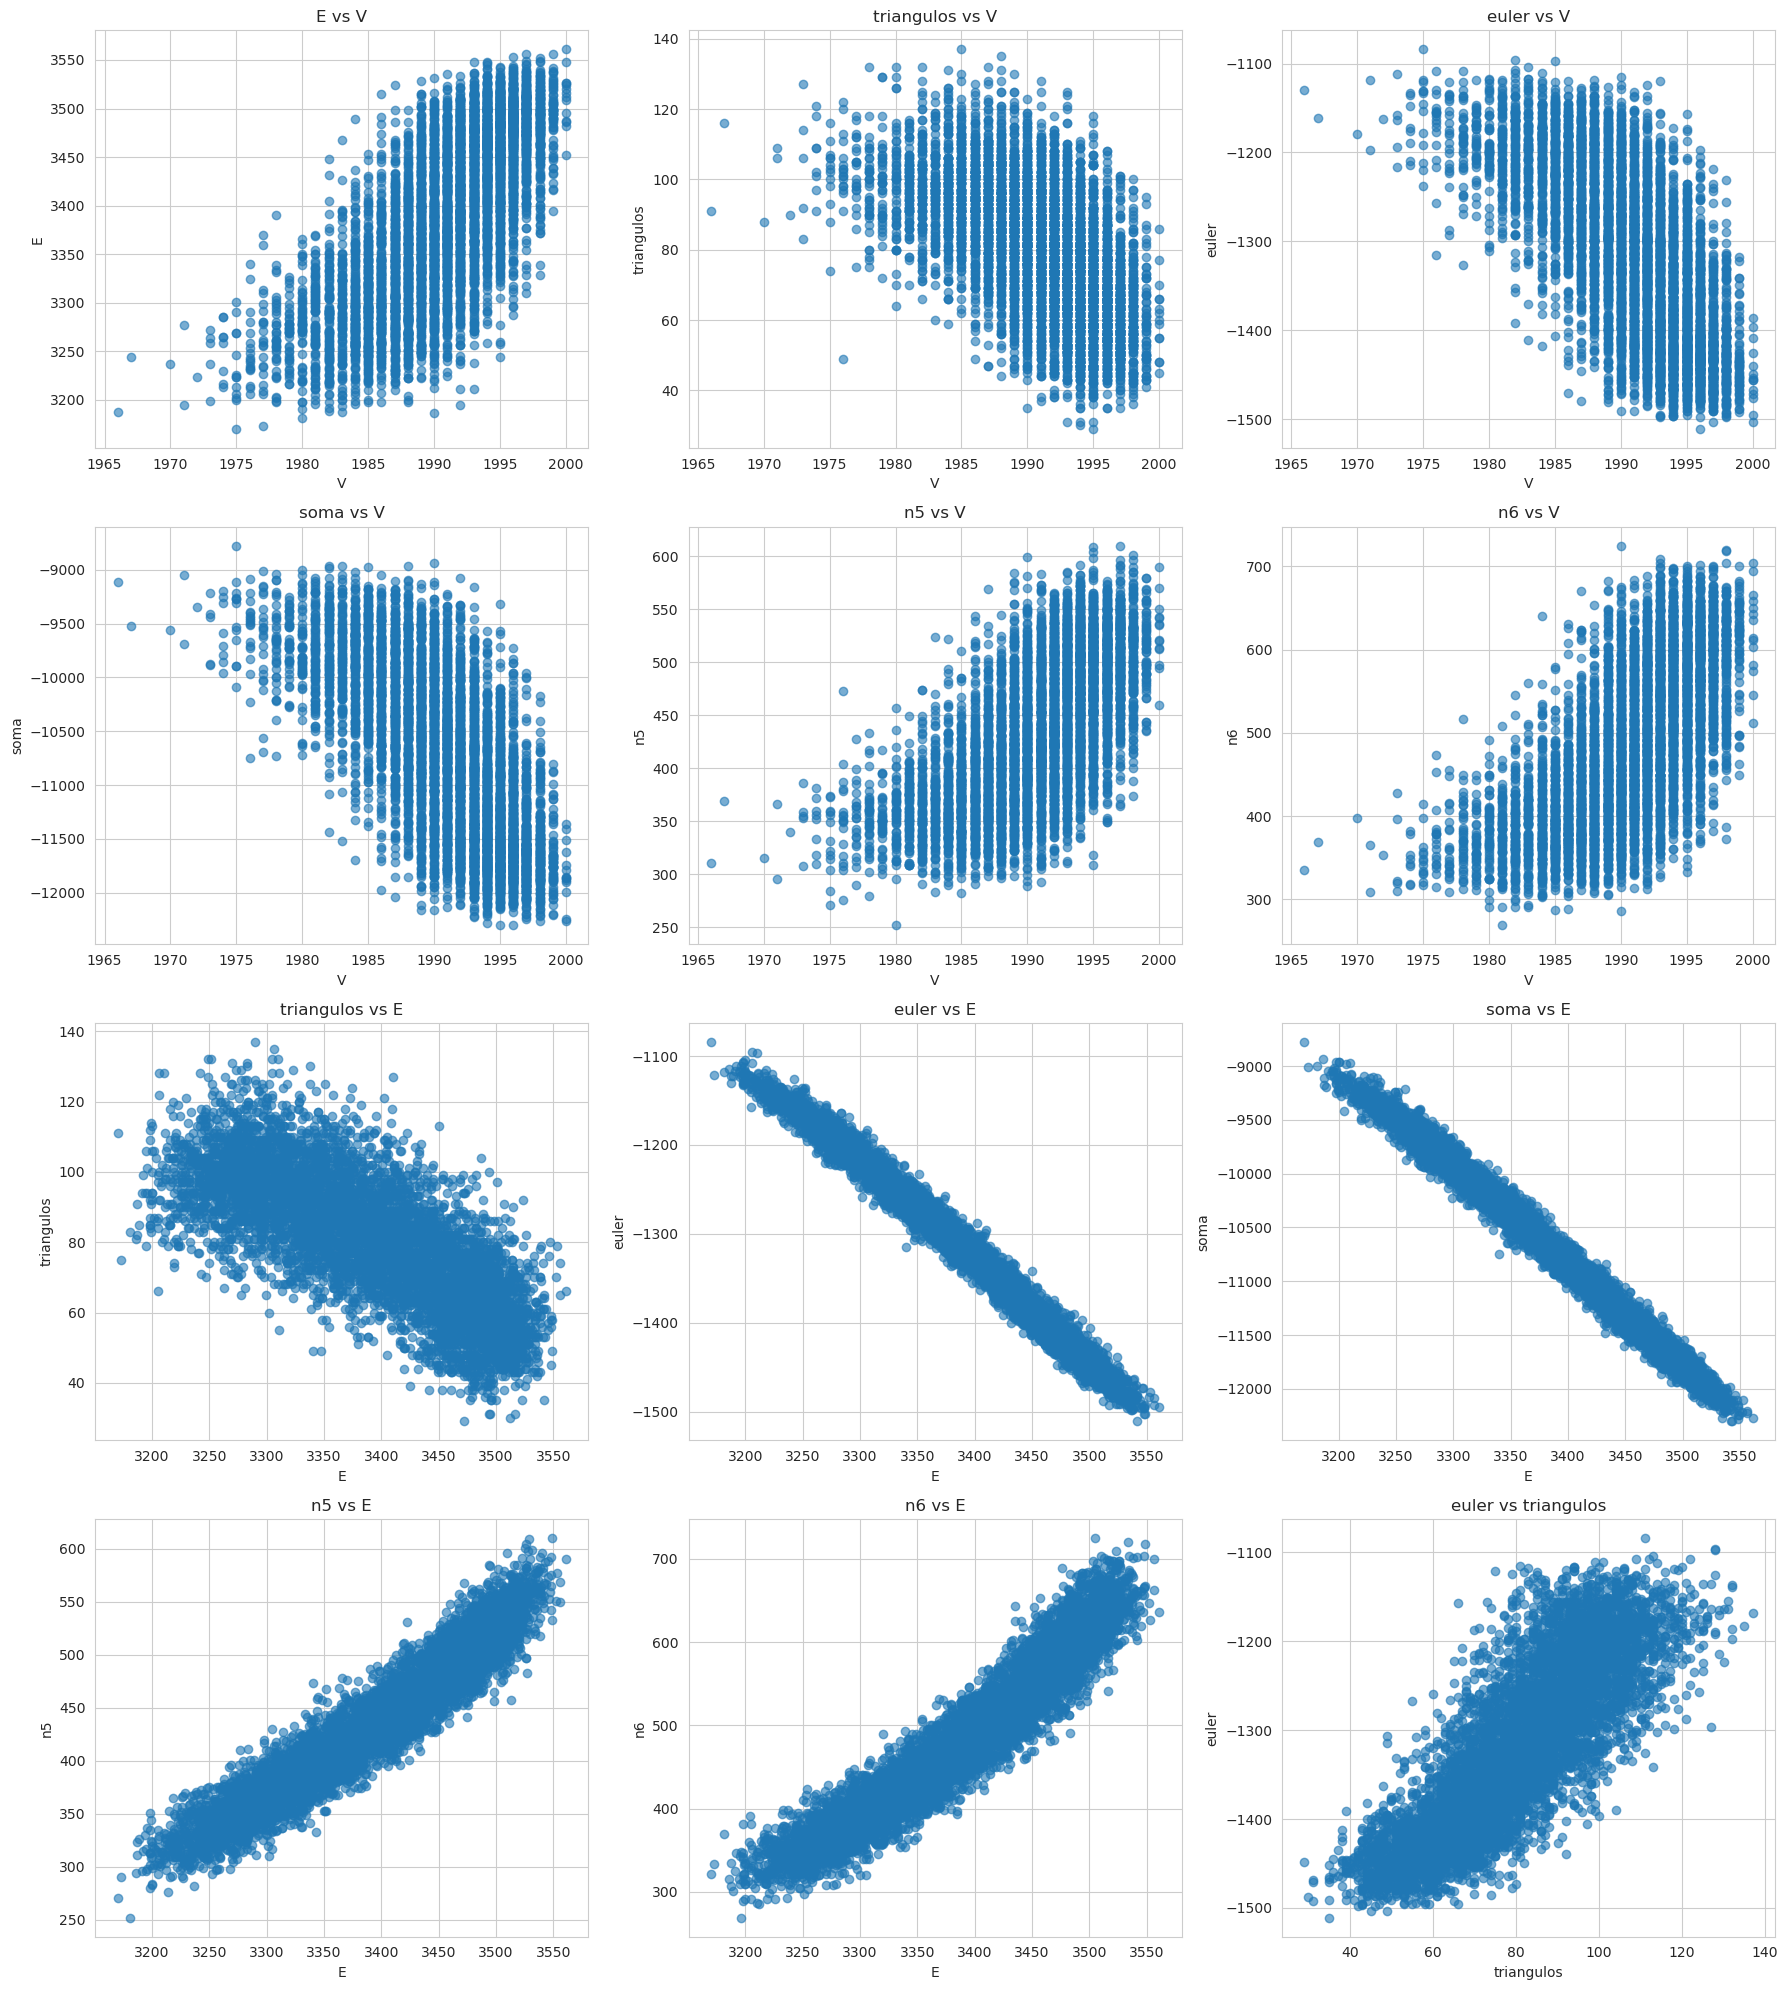

In [41]:
import matplotlib.pyplot as plt
import itertools

# Colunas
colunas = ['V', 'E', 'triangulos', 'euler', 'soma','n5','n6']

# Todos os pares possíveis
pares = list(itertools.combinations(colunas, 2))

# ---------------------------------------------------
# Criando grid
# ---------------------------------------------------

n = len(pares)

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))

# Transformando axes em vetor para facilitar
axes = axes.flatten()

# ---------------------------------------------------
# Plotando
# ---------------------------------------------------

for ax, (x, y) in zip(axes, pares):

    ax.scatter(df[x], df[y], alpha=0.6)

    ax.set_xlabel(x)
    ax.set_ylabel(y)

    ax.set_title(f'{y} vs {x}')

# ---------------------------------------------------
# Removendo eixos vazios
# ---------------------------------------------------

for i in range(len(pares), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [22]:

coeficientes_er = []

for i in range(100):

    G = nx.erdos_renyi_graph(2000, p)

    
    
    lm = smf.ols(
        'soma ~ I(V-E)+triangulos -1',
        data=df_temp
    ).fit()

    coeficientes_er.append([
        lm.params[0],
        lm.params[1]
    ])

NameError: name 'df_temp' is not defined

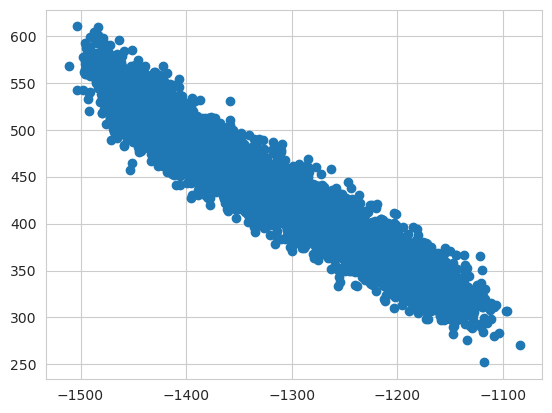

In [42]:
plt.scatter(df['euler'], df['n5'])

In [9]:
import networkx as nx
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ============================================================
# LISTA PARA SALVAR RESULTADOS DAS REDES
# ============================================================

resultados_er = []

# ============================================================
# PARÂMETROS
# ============================================================

n = 2000

# ============================================================
# LOOP
# ============================================================

for i in range(100):

    print(f"Simulação {i+1}")

    # --------------------------------------------------------
    # Varia p para gerar redes diferentes
    # --------------------------------------------------------

    p = np.random.uniform(0.001, 0.02)

    # --------------------------------------------------------
    # Gera o grafo ER
    # --------------------------------------------------------

    G = nx.erdos_renyi_graph(n, p)

    # --------------------------------------------------------
    # Calcula curvaturas
    # --------------------------------------------------------

    calc_forman_ricci_curvature(G)

    forman_ricci_curvature_2d(G)

    # --------------------------------------------------------
    # Métricas da rede
    # --------------------------------------------------------

    V = G.number_of_nodes()

    E = G.number_of_edges()

    triangulos = sum(nx.triangles(G).values()) / 3

    euler = V - E + triangulos

    # --------------------------------------------------------
    # Soma das curvaturas
    # --------------------------------------------------------

    soma = 0

    for u, v in G.edges():

        if "forman2d" in G[u][v]:

            soma += G[u][v]["forman2d"]

    # --------------------------------------------------------
    # Salva resultados
    # --------------------------------------------------------

    resultados_er.append({
        "V": V,
        "E": E,
        "triangulos": triangulos,
        "euler": euler,
        "soma": soma,
        "p": p
    })

# ============================================================
# DATAFRAME FINAL
# ============================================================

df_er = pd.DataFrame(resultados_er)

# ============================================================
# REGRESSÃO GLOBAL
# ============================================================

lm = smf.ols(
    'soma ~ I(V-E) + triangulos -1',
    data=df_er
).fit()

# ============================================================
# RESULTADOS
# ============================================================

print(lm.summary())

print("\nIntervalos de confiança:\n")
print(lm.conf_int())

# ============================================================
# DATAFRAME COM COEFICIENTES
# ============================================================

df_coeficientes_er = pd.DataFrame({
    "coeficiente": lm.params.index,
    "valor": lm.params.values,
    "IC_inferior": lm.conf_int()[0].values,
    "IC_superior": lm.conf_int()[1].values
})

print("\nCoeficientes:\n")
print(df_coeficientes_er)

Simulação 1
Simulação 2
Simulação 3
Simulação 4
Simulação 5
Simulação 6
Simulação 7
Simulação 8
Simulação 9
Simulação 10
Simulação 11
Simulação 12
Simulação 13
Simulação 14
Simulação 15
Simulação 16
Simulação 17
Simulação 18
Simulação 19
Simulação 20
Simulação 21
Simulação 22
Simulação 23
Simulação 24
Simulação 25
Simulação 26
Simulação 27
Simulação 28
Simulação 29
Simulação 30
Simulação 31
Simulação 32
Simulação 33
Simulação 34
Simulação 35
Simulação 36
Simulação 37
Simulação 38
Simulação 39
Simulação 40
Simulação 41
Simulação 42
Simulação 43
Simulação 44
Simulação 45
Simulação 46
Simulação 47
Simulação 48
Simulação 49
Simulação 50
Simulação 51
Simulação 52
Simulação 53
Simulação 54
Simulação 55
Simulação 56
Simulação 57
Simulação 58
Simulação 59
Simulação 60
Simulação 61
Simulação 62
Simulação 63
Simulação 64
Simulação 65
Simulação 66
Simulação 67
Simulação 68
Simulação 69
Simulação 70
Simulação 71
Simulação 72
Simulação 73
Simulação 74
Simulação 75
Simulação 76
Simulação 77
Simulaçã

In [11]:
import networkx as nx
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ============================================================
# LISTA PARA SALVAR RESULTADOS DAS REDES
# ============================================================

resultados_er = []

# ============================================================
# PARÂMETROS
# ============================================================

n = 2000

# ============================================================
# LOOP
# ============================================================

for i in range(100):

    print(f"Simulação {i+1}")

    # --------------------------------------------------------
    # Varia p para gerar redes diferentes
    # --------------------------------------------------------

    #p = np.random.uniform(0.001, 0.02)

    # --------------------------------------------------------
    # Gera o grafo ER
    # --------------------------------------------------------

    G = nx.erdos_renyi_graph(n, p)

    # --------------------------------------------------------
    # Calcula curvaturas
    # --------------------------------------------------------

    calc_forman_ricci_curvature(G)

    forman_ricci_curvature_2d(G)

    # --------------------------------------------------------
    # Métricas da rede
    # --------------------------------------------------------

    V = G.number_of_nodes()

    E = G.number_of_edges()

    triangulos = sum(nx.triangles(G).values()) / 3

    euler = V - E + triangulos

    # --------------------------------------------------------
    # Soma das curvaturas
    # --------------------------------------------------------

    soma = 0

    for u, v in G.edges():

        if "forman2d" in G[u][v]:

            soma += G[u][v]["forman2d"]

    # --------------------------------------------------------
    # Salva resultados
    # --------------------------------------------------------

    resultados_er.append({
        "V": V,
        "E": E,
        "triangulos": triangulos,
        "euler": euler,
        "soma": soma,
        "p": p
    })

# ============================================================
# DATAFRAME FINAL
# ============================================================

df_er = pd.DataFrame(resultados_er)

# ============================================================
# REGRESSÃO GLOBAL
# ============================================================

lm = smf.ols(
    'soma ~ I(V-E) + triangulos -1',
    data=df_er
).fit()

# ============================================================
# RESULTADOS
# ============================================================

print(lm.summary())

print("\nIntervalos de confiança:\n")
print(lm.conf_int())

# ============================================================
# DATAFRAME COM COEFICIENTES
# ============================================================

df_coeficientes_er = pd.DataFrame({
    "coeficiente": lm.params.index,
    "valor": lm.params.values,
    "IC_inferior": lm.conf_int()[0].values,
    "IC_superior": lm.conf_int()[1].values
})

print("\nCoeficientes:\n")
print(df_coeficientes_er)

Simulação 1
Simulação 2
Simulação 3
Simulação 4
Simulação 5
Simulação 6
Simulação 7
Simulação 8
Simulação 9
Simulação 10
Simulação 11
Simulação 12
Simulação 13
Simulação 14
Simulação 15
Simulação 16
Simulação 17
Simulação 18
Simulação 19
Simulação 20
Simulação 21
Simulação 22
Simulação 23
Simulação 24
Simulação 25
Simulação 26
Simulação 27
Simulação 28
Simulação 29
Simulação 30
Simulação 31
Simulação 32
Simulação 33
Simulação 34
Simulação 35
Simulação 36
Simulação 37
Simulação 38
Simulação 39
Simulação 40
Simulação 41
Simulação 42
Simulação 43
Simulação 44
Simulação 45
Simulação 46
Simulação 47
Simulação 48
Simulação 49
Simulação 50
Simulação 51
Simulação 52
Simulação 53
Simulação 54
Simulação 55
Simulação 56
Simulação 57
Simulação 58
Simulação 59
Simulação 60
Simulação 61
Simulação 62
Simulação 63
Simulação 64
Simulação 65
Simulação 66
Simulação 67
Simulação 68
Simulação 69
Simulação 70
Simulação 71
Simulação 72
Simulação 73
Simulação 74
Simulação 75
Simulação 76
Simulação 77
Simulaçã

In [12]:
resultados_ws = []

for i in range(100):

    print(f"WS {i+1}")

    # ----------------------------------------------------
    # Gera rede WS
    # ----------------------------------------------------

    p_rewire = np.random.uniform(0.001, 0.3)

    G = nx.watts_strogatz_graph(
        n=2000,
        k=4,
        p=p_rewire
    )

    # ----------------------------------------------------
    # Curvaturas
    # ----------------------------------------------------

    calc_forman_ricci_curvature(G)

    forman_ricci_curvature_2d(G)

    # ----------------------------------------------------
    # Métricas
    # ----------------------------------------------------

    V = G.number_of_nodes()

    E = G.number_of_edges()

    triangulos = sum(nx.triangles(G).values()) / 3

    euler = V - E + triangulos

    soma = 0

    for u, v in G.edges():

        if "forman2d" in G[u][v]:

            soma += G[u][v]["forman2d"]

    resultados_ws.append({
        "V": V,
        "E": E,
        "triangulos": triangulos,
        "euler": euler,
        "soma": soma,
        "p_rewire": p_rewire
    })

# ========================================================
# DATAFRAME
# ========================================================

df_ws = pd.DataFrame(resultados_ws)

# ========================================================
# REGRESSÃO
# ========================================================

lm_ws = smf.ols(
    'soma ~ I(V-E)+triangulos -1',
    data=df_ws
).fit()

print(lm_ws.summary())

print(lm_ws.conf_int())

WS 1
WS 2
WS 3
WS 4
WS 5
WS 6
WS 7
WS 8
WS 9
WS 10
WS 11
WS 12
WS 13
WS 14
WS 15
WS 16
WS 17
WS 18
WS 19
WS 20
WS 21
WS 22
WS 23
WS 24
WS 25
WS 26
WS 27
WS 28
WS 29
WS 30
WS 31
WS 32
WS 33
WS 34
WS 35
WS 36
WS 37
WS 38
WS 39
WS 40
WS 41
WS 42
WS 43
WS 44
WS 45
WS 46
WS 47
WS 48
WS 49
WS 50
WS 51
WS 52
WS 53
WS 54
WS 55
WS 56
WS 57
WS 58
WS 59
WS 60
WS 61
WS 62
WS 63
WS 64
WS 65
WS 66
WS 67
WS 68
WS 69
WS 70
WS 71
WS 72
WS 73
WS 74
WS 75
WS 76
WS 77
WS 78
WS 79
WS 80
WS 81
WS 82
WS 83
WS 84
WS 85
WS 86
WS 87
WS 88
WS 89
WS 90
WS 91
WS 92
WS 93
WS 94
WS 95
WS 96
WS 97
WS 98
WS 99
WS 100
                            OLS Regression Results                            
Dep. Variable:                   soma   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.675e+05
Date:                Tue, 26 May 2026   Prob (F-statistic):          4.47e-182
Time:        

In [13]:
resultados_ba = []

for i in range(100):

    print(f"BA {i+1}")

    # ----------------------------------------------------
    # Gera rede BA
    # ----------------------------------------------------

    G = nx.barabasi_albert_graph(
        n=2000,
        m=2
    )

    # ----------------------------------------------------
    # Curvaturas
    # ----------------------------------------------------

    calc_forman_ricci_curvature(G)

    forman_ricci_curvature_2d(G)

    # ----------------------------------------------------
    # Métricas
    # ----------------------------------------------------

    V = G.number_of_nodes()

    E = G.number_of_edges()

    triangulos = sum(nx.triangles(G).values()) / 3

    euler = V - E + triangulos

    soma = 0

    for u, v in G.edges():

        if "forman2d" in G[u][v]:

            soma += G[u][v]["forman2d"]

    resultados_ba.append({
        "V": V,
        "E": E,
        "triangulos": triangulos,
        "euler": euler,
        "soma": soma
    })

# ========================================================
# DATAFRAME
# ========================================================

df_ba = pd.DataFrame(resultados_ba)

# ========================================================
# REGRESSÃO
# ========================================================

lm_ba = smf.ols(
    'soma ~ I(V-E)+triangulos -1',
    data=df_ba
).fit()

print(lm_ba.summary())

print(lm_ba.conf_int())

BA 1
BA 2
BA 3
BA 4
BA 5
BA 6
BA 7
BA 8
BA 9
BA 10
BA 11
BA 12
BA 13
BA 14
BA 15
BA 16
BA 17
BA 18
BA 19
BA 20
BA 21
BA 22
BA 23
BA 24
BA 25
BA 26
BA 27
BA 28
BA 29
BA 30
BA 31
BA 32
BA 33
BA 34
BA 35
BA 36
BA 37
BA 38
BA 39
BA 40
BA 41
BA 42
BA 43
BA 44
BA 45
BA 46
BA 47
BA 48
BA 49
BA 50
BA 51
BA 52
BA 53
BA 54
BA 55
BA 56
BA 57
BA 58
BA 59
BA 60
BA 61
BA 62
BA 63
BA 64
BA 65
BA 66
BA 67
BA 68
BA 69
BA 70
BA 71
BA 72
BA 73
BA 74
BA 75
BA 76
BA 77
BA 78
BA 79
BA 80
BA 81
BA 82
BA 83
BA 84
BA 85
BA 86
BA 87
BA 88
BA 89
BA 90
BA 91
BA 92
BA 93
BA 94
BA 95
BA 96
BA 97
BA 98
BA 99
BA 100
                            OLS Regression Results                            
Dep. Variable:                   soma   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     105.8
Date:                Tue, 26 May 2026   Prob (F-statistic):           2.91e-17
Time:        


Coefficient summary:

           alpha       beta
count  21.000000  21.000000
mean    8.003021   5.431809
std     0.034058   0.533151
min     7.928893   4.079852
25%     7.986583   5.122654
50%     8.006127   5.587214
75%     8.030656   5.821969
max     8.058291   6.214588


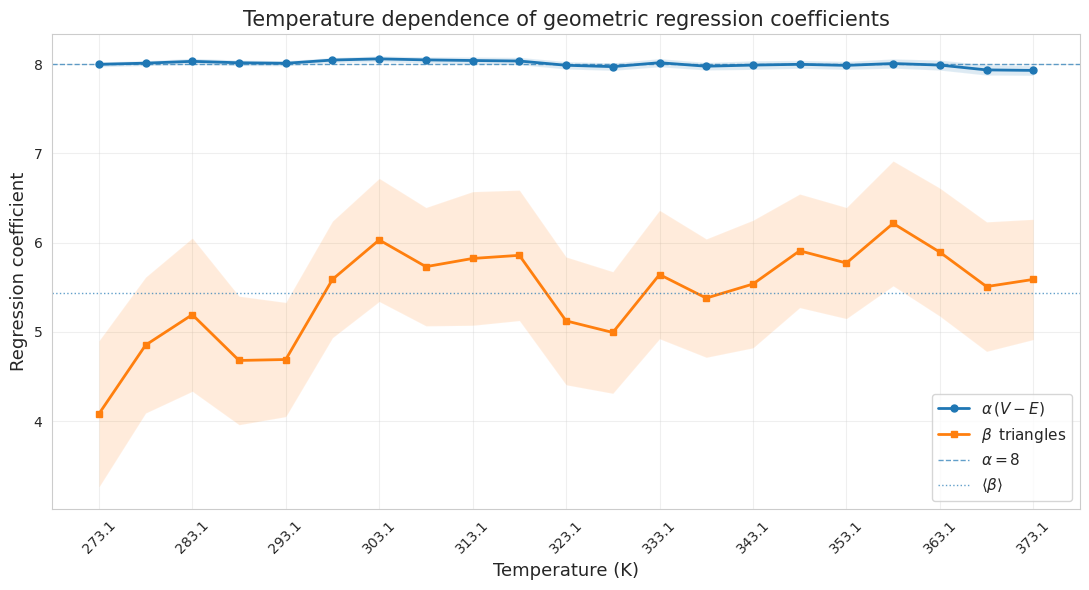

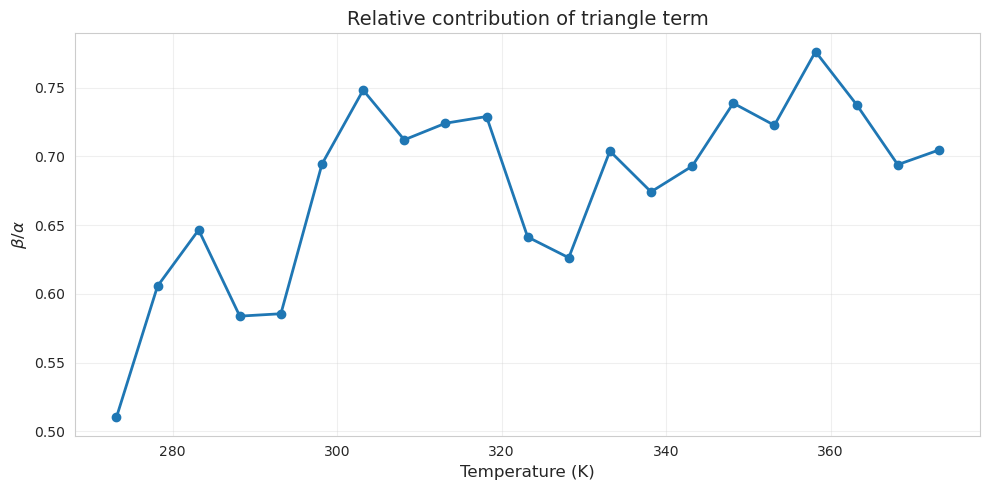

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ============================================================
# STYLE
# ============================================================

sns.set_style("whitegrid")

# ============================================================
# RUN REGRESSIONS
# ============================================================

results = []

for temp_celsius in sorted(df["temp_valor"].unique()):

    # --------------------------------------------------------
    # Select temperature subset
    # --------------------------------------------------------

    df_temp = df[df["temp_valor"] == temp_celsius]

    # --------------------------------------------------------
    # Linear regression
    # soma = alpha(V-E) + beta*triangles
    # --------------------------------------------------------

    lm = smf.ols(
        'soma ~ I(V-E) + triangulos -1',
        data=df_temp
    ).fit()

    # --------------------------------------------------------
    # Extract coefficients
    # --------------------------------------------------------

    alpha = lm.params["I(V - E)"]
    beta = lm.params["triangulos"]

    # --------------------------------------------------------
    # Confidence intervals
    # --------------------------------------------------------

    ci = lm.conf_int()

    alpha_low = ci.loc["I(V - E)", 0]
    alpha_high = ci.loc["I(V - E)", 1]

    beta_low = ci.loc["triangulos", 0]
    beta_high = ci.loc["triangulos", 1]

    # --------------------------------------------------------
    # Convert Celsius → Kelvin
    # --------------------------------------------------------

    temp_kelvin = temp_celsius + 273.15

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    results.append({
        "Temperature_K": temp_kelvin,

        "alpha": alpha,
        "alpha_low": alpha_low,
        "alpha_high": alpha_high,

        "beta": beta,
        "beta_low": beta_low,
        "beta_high": beta_high
    })

# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

df_res = pd.DataFrame(results)

# ============================================================
# PRINT SUMMARY
# ============================================================

print("\nCoefficient summary:\n")

print(
    df_res[["alpha", "beta"]].describe()
)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(11,6))

# ------------------------------------------------------------
# Alpha coefficient
# ------------------------------------------------------------

plt.plot(
    df_res["Temperature_K"],
    df_res["alpha"],
    'o-',
    linewidth=2,
    markersize=5,
    label=r'$\alpha \,(V-E)$'
)

plt.fill_between(
    df_res["Temperature_K"],
    df_res["alpha_low"],
    df_res["alpha_high"],
    alpha=0.15
)

# ------------------------------------------------------------
# Beta coefficient
# ------------------------------------------------------------

plt.plot(
    df_res["Temperature_K"],
    df_res["beta"],
    's-',
    linewidth=2,
    markersize=5,
    label=r'$\beta \,$ triangles'
)

plt.fill_between(
    df_res["Temperature_K"],
    df_res["beta_low"],
    df_res["beta_high"],
    alpha=0.15
)

# ------------------------------------------------------------
# Reference lines
# ------------------------------------------------------------

plt.axhline(
    8,
    linestyle='--',
    linewidth=1,
    alpha=0.7,
    label=r'$\alpha = 8$'
)

plt.axhline(
    np.mean(df_res["beta"]),
    linestyle=':',
    linewidth=1,
    alpha=0.7,
    label=r'$\langle \beta \rangle$'
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel("Temperature (K)", fontsize=13)

plt.ylabel("Regression coefficient", fontsize=13)

plt.title(
    "Temperature dependence of geometric regression coefficients",
    fontsize=15
)

# ------------------------------------------------------------
# Ticks
# ------------------------------------------------------------

plt.xticks(
    df_res["Temperature_K"][::2],
    rotation=45
)

# ------------------------------------------------------------
# Grid and legend
# ------------------------------------------------------------

plt.grid(alpha=0.3)

plt.legend(fontsize=11)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout()

plt.show()

# ============================================================
# OPTIONAL:
# Relative geometric contribution
# ============================================================

plt.figure(figsize=(10,5))

ratio = df_res["beta"] / df_res["alpha"]

plt.plot(
    df_res["Temperature_K"],
    ratio,
    'o-',
    linewidth=2
)

plt.xlabel("Temperature (K)", fontsize=12)

plt.ylabel(r'$\beta / \alpha$', fontsize=12)

plt.title(
    "Relative contribution of triangle term",
    fontsize=14
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [15]:
df

,V,E,triangulos,euler,soma,temp_valor,n5,n6
0,1993,3535,47,-1495,-12227,0.0,145,104
1,1996,3505,48,-1461,-11920,0.0,150,95
2,1996,3510,51,-1463,-11859,0.0,155,100
3,1999,3504,44,-1461,-11762,0.0,141,102
4,1997,3489,50,-1442,-11636,0.0,146,115
...,...,...,...,...,...,...,...,...
6295,1989,3276,92,-1195,-9656,100.0,124,70
6296,1984,3283,126,-1173,-9660,100.0,120,77
6297,1982,3218,120,-1116,-9142,100.0,117,69
6298,1992,3262,103,-1167,-9437,100.0,111,66


In [85]:
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

# cria cópia
df_scaled = df.copy()

# variáveis que entrarão na regressão
cols = ['V', 'E', 'triangulos', 'n5', 'n6']

# normaliza
scaler = StandardScaler()

df_scaled[cols] = scaler.fit_transform(df_scaled[cols])

# loop
for temp in sorted(df_scaled["temp_valor"].unique()):

    df_temp = df_scaled[df_scaled["temp_valor"] == temp]

    lm = smf.ols(
        'soma ~ E-1',
        data=df_temp
    ).fit()

    print(lm.summary())

                                 OLS Regression Results                                
Dep. Variable:                   soma   R-squared (uncentered):                   0.983
Model:                            OLS   Adj. R-squared (uncentered):              0.983
Method:                 Least Squares   F-statistic:                          1.751e+04
Date:                Thu, 28 May 2026   Prob (F-statistic):                   1.98e-267
Time:                        20:37:07   Log-Likelihood:                         -2639.9
No. Observations:                 300   AIC:                                      5282.
Df Residuals:                     299   BIC:                                      5285.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [88]:
lista =[]
for temp in sorted(df["temp_valor"].unique()):

    df_temp = df[df["temp_valor"] == temp]

    lm = smf.ols(
        'soma~ E+triangulos+n5-1',
        data=df_temp
    ).fit()
    print(lm.summary())
    #lista.append(lm.params["I(V-E)"])

                                 OLS Regression Results                                
Dep. Variable:                   soma   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          2.419e+06
Date:                Thu, 28 May 2026   Prob (F-statistic):                        0.00
Time:                        20:40:52   Log-Likelihood:                         -1737.4
No. Observations:                 300   AIC:                                      3481.
Df Residuals:                     297   BIC:                                      3492.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [77]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['E','triangulos','n5','n6']]

vif = pd.DataFrame()
vif["variavel"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

     variavel         VIF
0           E  423.901911
1  triangulos   62.885646
2          n5  273.153563
3          n6  184.623629


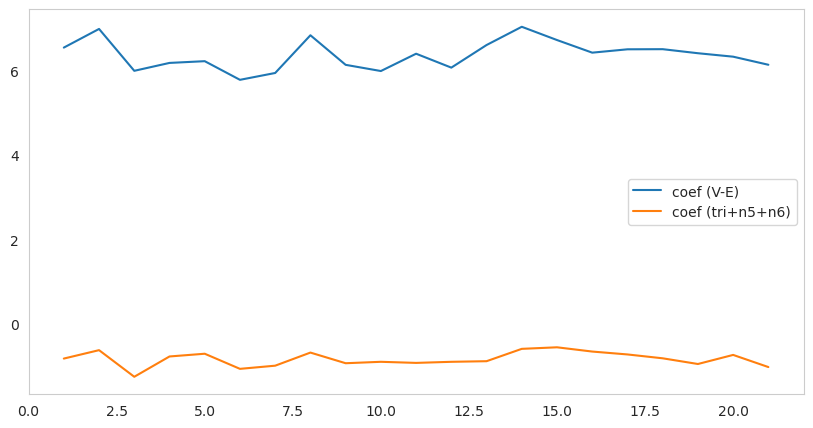

In [62]:
        'soma~ I(V - E) + triangulos+n5+n6'


# R²
r2 = [
    0.844, 0.854, 0.833, 0.841, 0.804,
    0.785, 0.812, 0.841, 0.827, 0.808,
    0.847, 0.821, 0.843, 0.814, 0.801,
    0.811, 0.806, 0.804, 0.831, 0.826,
    0.835
]

# coeficiente de (V - E)
coef_ve = [
    6.5408, 6.9820, 5.9917, 6.1785, 6.2196,
    5.7787, 5.9404, 6.8324, 6.1331, 5.9866,
    6.3960, 6.0671, 6.6015, 7.0331, 6.7194,
    6.4210, 6.5004, 6.5033, 6.4077, 6.3260,
    6.1348
]

# coeficiente de (triangulos + n5 + n6)
coef_tri = [
    -0.8129, -0.6139, -1.2434, -0.7632, -0.6985,
    -1.0559, -0.9811, -0.6712, -0.9230, -0.8893,
    -0.9151, -0.8895, -0.8750, -0.5830, -0.5463,
    -0.6469, -0.7153, -0.8066, -0.9413, -0.7264,
    -1.0136
]

# interceptos
interceptos = [
    -999.2717, -537.6114, -1266.2859, -1540.8570, -1539.7168,
    -1780.1316, -1586.8598, -612.1383, -1317.2212, -1526.8000,
    -897.9821, -1357.4782, -615.7090, -269.7254, -711.5450,
    -979.6976, -788.9646, -677.3062, -671.5618, -908.5309,
    -892.0205
]

# número de condição
cond = [
    2.08e5, 1.92e5, 1.77e5, 1.61e5, 1.69e5,
    1.85e5, 1.56e5, 1.43e5, 1.39e5, 1.26e5,
    1.40e5, 1.34e5, 1.17e5, 1.22e5, 1.18e5,
    1.12e5, 1.07e5, 9.73e4, 1.00e5, 9.35e4,
    8.63e4
]


import matplotlib.pyplot as plt

x = range(1, len(r2)+1)

plt.figure(figsize=(10,5))
plt.plot(x, coef_ve, label='coef (V-E)')
plt.plot(x, coef_tri, label='coef (tri+n5+n6)')
plt.legend()
plt.grid()
plt.show()

In [66]:
lista = []

for temp in sorted(df["temp_valor"].unique()):

    df_temp = df[df["temp_valor"] == temp].copy()

    df_temp["soma_norm"] = df_temp["soma"] / df_temp["V"]
    df_temp["euler_norm"] = (df_temp["V"] - df_temp["E"]) / df_temp["V"]
    df_temp["ciclos_norm"] = (
        df_temp["triangulos"] + df_temp["n5"] + df_temp["n6"]
    ) / df_temp["V"]

    lm = smf.ols(
        'soma_norm ~ euler_norm + ciclos_norm',
        data=df_temp
    ).fit()

    print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:              soma_norm   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     802.6
Date:                Thu, 28 May 2026   Prob (F-statistic):          1.72e-120
Time:                        19:33:56   Log-Likelihood:                 627.10
No. Observations:                 300   AIC:                            -1248.
Df Residuals:                     297   BIC:                            -1237.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.4838      0.184     -2.623      


Coefficient summary:

           alpha       beta      gamma
count  21.000000  21.000000  21.000000
mean    5.743021  -1.826468  -1.238523
std     0.288981   0.317515   0.230645
min     5.231631  -2.402649  -1.653004
25%     5.466844  -1.990113  -1.329648
50%     5.724849  -1.833527  -1.264332
75%     5.927971  -1.694122  -1.124605
max     6.254256  -1.057476  -0.689584


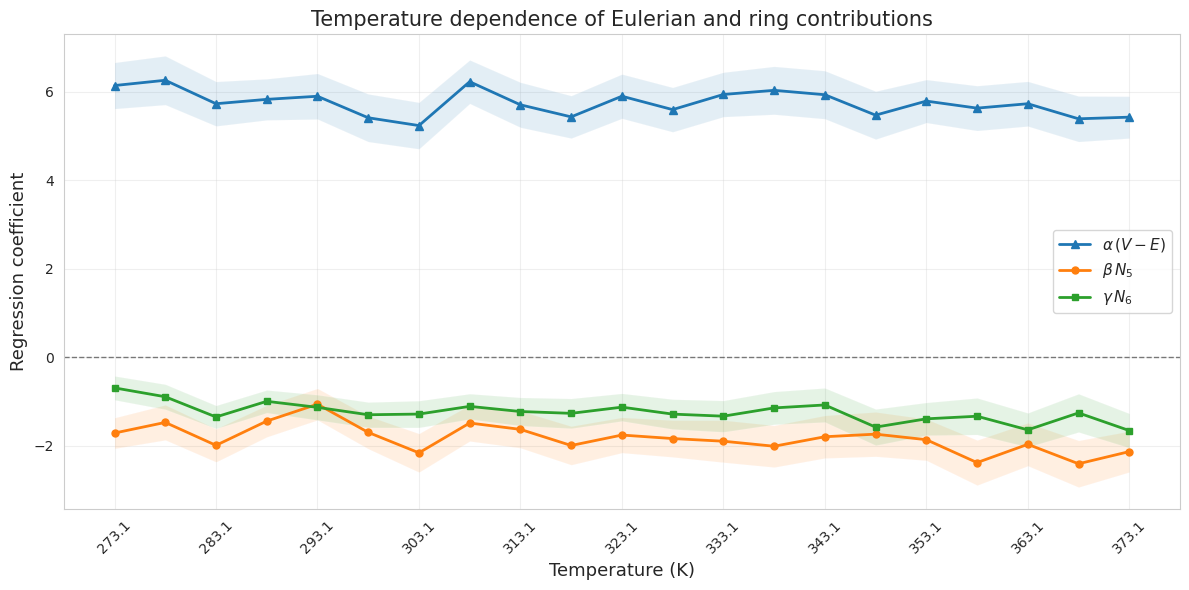

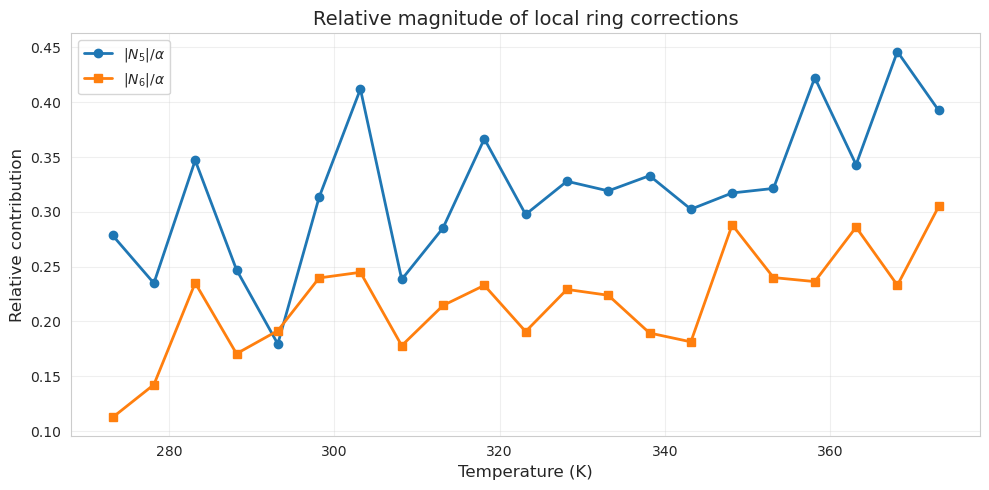

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ============================================================
# STYLE
# ============================================================

sns.set_style("whitegrid")

# ============================================================
# RUN REGRESSIONS
# ============================================================

results = []

for temp_celsius in sorted(df["temp_valor"].unique()):

    # --------------------------------------------------------
    # Temperature subset
    # --------------------------------------------------------

    df_temp = df[df["temp_valor"] == temp_celsius]

    # --------------------------------------------------------
    # Regression
    # soma = alpha(V-E) + beta*N5 + gamma*N6
    # --------------------------------------------------------

    lm = smf.ols(
        'soma ~ I(V-E) + n5 + n6',
        data=df_temp
    ).fit()

    # --------------------------------------------------------
    # Coefficients
    # --------------------------------------------------------

    alpha = lm.params["I(V - E)"]
    beta = lm.params["n5"]
    gamma = lm.params["n6"]

    # --------------------------------------------------------
    # Confidence intervals
    # --------------------------------------------------------

    ci = lm.conf_int()

    alpha_low = ci.loc["I(V - E)", 0]
    alpha_high = ci.loc["I(V - E)", 1]

    beta_low = ci.loc["n5", 0]
    beta_high = ci.loc["n5", 1]

    gamma_low = ci.loc["n6", 0]
    gamma_high = ci.loc["n6", 1]

    # --------------------------------------------------------
    # Convert to Kelvin
    # --------------------------------------------------------

    temp_kelvin = temp_celsius + 273.15

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    results.append({
        "Temperature_K": temp_kelvin,

        "alpha": alpha,
        "alpha_low": alpha_low,
        "alpha_high": alpha_high,

        "beta": beta,
        "beta_low": beta_low,
        "beta_high": beta_high,

        "gamma": gamma,
        "gamma_low": gamma_low,
        "gamma_high": gamma_high
    })

# ============================================================
# DATAFRAME
# ============================================================

df_res = pd.DataFrame(results)

# ============================================================
# SUMMARY
# ============================================================

print("\nCoefficient summary:\n")

print(
    df_res[["alpha", "beta", "gamma"]].describe()
)

# ============================================================
# MAIN PLOT
# ============================================================

plt.figure(figsize=(12,6))

# ------------------------------------------------------------
# Alpha : Euler contribution
# ------------------------------------------------------------

plt.plot(
    df_res["Temperature_K"],
    df_res["alpha"],
    '^-',
    linewidth=2,
    markersize=6,
    label=r'$\alpha\,(V-E)$'
)

plt.fill_between(
    df_res["Temperature_K"],
    df_res["alpha_low"],
    df_res["alpha_high"],
    alpha=0.12
)

# ------------------------------------------------------------
# Beta : N5 contribution
# ------------------------------------------------------------

plt.plot(
    df_res["Temperature_K"],
    df_res["beta"],
    'o-',
    linewidth=2,
    markersize=5,
    label=r'$\beta\,N_5$'
)

plt.fill_between(
    df_res["Temperature_K"],
    df_res["beta_low"],
    df_res["beta_high"],
    alpha=0.12
)

# ------------------------------------------------------------
# Gamma : N6 contribution
# ------------------------------------------------------------

plt.plot(
    df_res["Temperature_K"],
    df_res["gamma"],
    's-',
    linewidth=2,
    markersize=5,
    label=r'$\gamma\,N_6$'
)

plt.fill_between(
    df_res["Temperature_K"],
    df_res["gamma_low"],
    df_res["gamma_high"],
    alpha=0.12
)

# ------------------------------------------------------------
# Reference line
# ------------------------------------------------------------

plt.axhline(
    0,
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=0.5
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel("Temperature (K)", fontsize=13)

plt.ylabel("Regression coefficient", fontsize=13)

plt.title(
    "Temperature dependence of Eulerian and ring contributions",
    fontsize=15
)

# ------------------------------------------------------------
# Ticks
# ------------------------------------------------------------

plt.xticks(
    df_res["Temperature_K"][::2],
    rotation=45
)

# ------------------------------------------------------------
# Grid / legend
# ------------------------------------------------------------

plt.grid(alpha=0.3)

plt.legend(fontsize=11)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout()

plt.show()

# ============================================================
# OPTIONAL:
# Relative magnitude of ring corrections
# ============================================================

plt.figure(figsize=(10,5))

ratio_n5 = np.abs(df_res["beta"]) / df_res["alpha"]
ratio_n6 = np.abs(df_res["gamma"]) / df_res["alpha"]

plt.plot(
    df_res["Temperature_K"],
    ratio_n5,
    'o-',
    linewidth=2,
    label=r'$|N_5|/\alpha$'
)

plt.plot(
    df_res["Temperature_K"],
    ratio_n6,
    's-',
    linewidth=2,
    label=r'$|N_6|/\alpha$'
)

plt.xlabel("Temperature (K)", fontsize=12)

plt.ylabel("Relative contribution", fontsize=12)

plt.title(
    "Relative magnitude of local ring corrections",
    fontsize=14
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [38]:
lm = smf.ols(
    'soma ~ I(V-E) -1',
    data=df
).fit()

print(lm.summary())

lm = smf.ols(
    'soma ~ I(V-E)+triangulos -1',
    data=df
).fit()

print(lm.summary())

                                 OLS Regression Results                                
Dep. Variable:                   soma   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          2.266e+07
Date:                Thu, 28 May 2026   Prob (F-statistic):                        0.00
Time:                        18:00:37   Log-Likelihood:                         -41653.
No. Observations:                6300   AIC:                                  8.331e+04
Df Residuals:                    6299   BIC:                                  8.332e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [3]:
alpha = [
    7.9971,
    8.0102,
    8.0307,
    8.0144,
    8.0087,
    8.0451,
    8.0583,
    8.0468,
    8.0399,
    8.0341,
    7.9866,
    7.9712,
    8.0152,
    7.9758,
    7.9887,
    7.9972,
    7.9853,
    8.0061,
    7.9886,
    7.9346,
    7.9289
]

In [7]:
beta = [
    4.0799,
    4.8514,
    5.1923,
    4.6792,
    4.6897,
    5.5875,
    6.0294,
    5.7299,
    5.8220,
    5.8571,
    5.1227,
    4.9925,
    5.6418,
    5.3777,
    5.5353,
    5.9077,
    5.7707,
    6.2146,
    5.8927,
    5.5068,
    5.5872
]

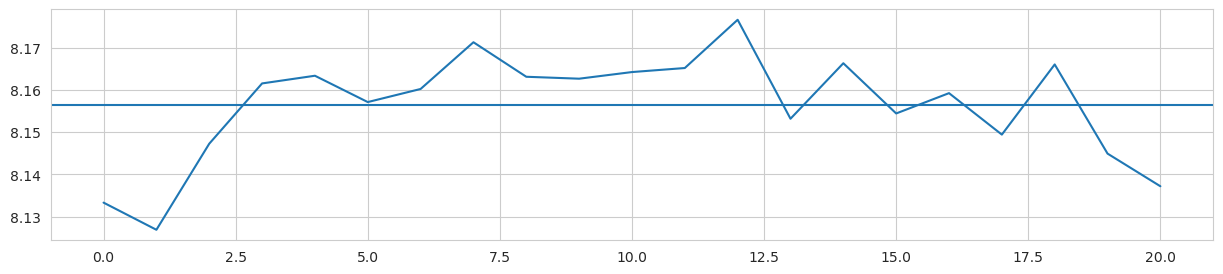

In [46]:
media = np.mean(lista)
plt.figure(figsize=(15,3))
plt.plot(lista)
plt.axhline(media)



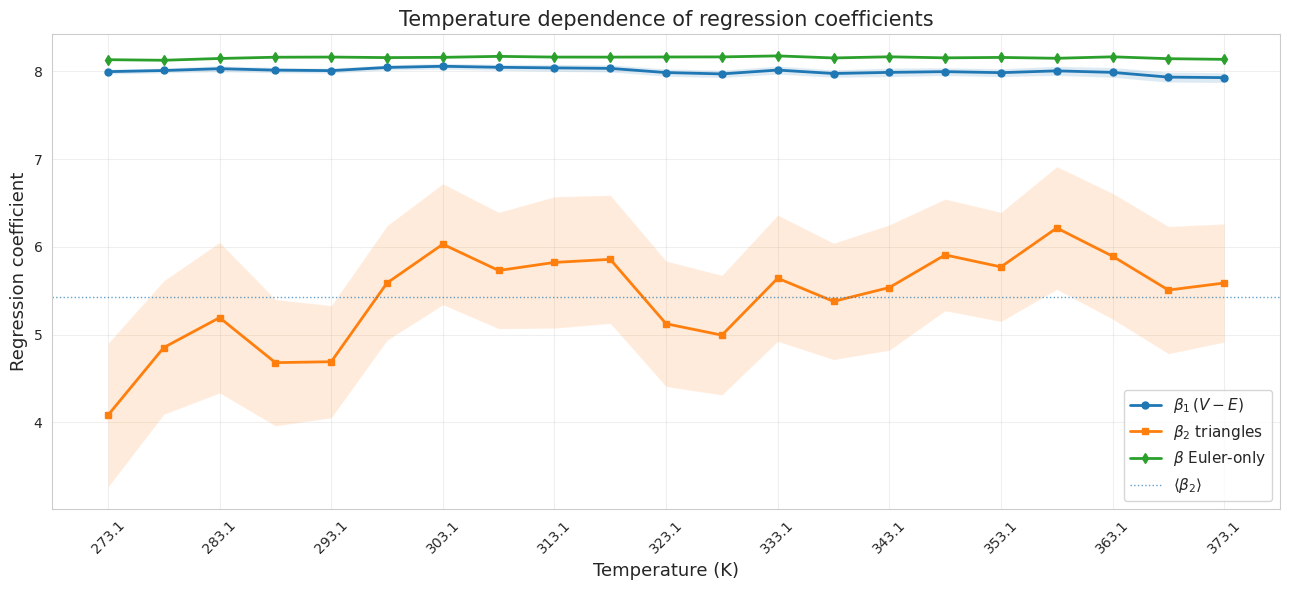

In [54]:
# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(13,6))

# ------------------------------------------------------------
# Alpha coefficient
# ------------------------------------------------------------

plt.plot(
    df_res["Temperature_K"],
    df_res["alpha"],
    'o-',
    linewidth=2,
    markersize=5,
    label=r'$\beta_1 \,(V-E)$'
)

plt.fill_between(
    df_res["Temperature_K"],
    df_res["alpha_low"],
    df_res["alpha_high"],
    alpha=0.15
)

# ------------------------------------------------------------
# Beta coefficient
# ------------------------------------------------------------

plt.plot(
    df_res["Temperature_K"],
    df_res["beta"],
    's-',
    linewidth=2,
    markersize=5,
    label=r'$\beta_2$ triangles'
)

plt.fill_between(
    df_res["Temperature_K"],
    df_res["beta_low"],
    df_res["beta_high"],
    alpha=0.15
)

# ------------------------------------------------------------
# Euler-only coefficient
# ------------------------------------------------------------

plt.plot(
    df_res["Temperature_K"],
    lista,
    'd-',
    linewidth=2,
    markersize=5,
    label=r'$\beta$ Euler-only'
)

# ------------------------------------------------------------
# Reference lines
# ------------------------------------------------------------


plt.axhline(
    np.mean(df_res["beta"]),
    linestyle=':',
    linewidth=1,
    alpha=0.7,
    label=r'$\langle \beta_2 \rangle$'
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.xlabel("Temperature (K)", fontsize=13)

plt.ylabel("Regression coefficient", fontsize=13)

plt.title(
    "Temperature dependence of regression coefficients",
    fontsize=15
)

# ------------------------------------------------------------
# Ticks
# ------------------------------------------------------------

plt.xticks(
    df_res["Temperature_K"][::2],
    rotation=45
)

# ------------------------------------------------------------
# Grid and legend
# ------------------------------------------------------------

plt.grid(alpha=0.3)

plt.legend(fontsize=11)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout()
plt.savefig("temperature_dependence_of_regression_coefficients.png")
plt.show()


In [5]:
lm = smf.ols('soma~I(V-E)+n5+n6-1', data=df).fit()
print(lm.summary())

                                 OLS Regression Results                                
Dep. Variable:                   soma   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          4.629e+07
Date:                Thu, 28 May 2026   Prob (F-statistic):                        0.00
Time:                        17:27:46   Log-Likelihood:                         -35942.
No. Observations:                6300   AIC:                                  7.189e+04
Df Residuals:                    6297   BIC:                                  7.191e+04
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [4]:
df

,V,E,triangulos,euler,soma,temp_valor,n5,n6
0,1993,3535,47,-1495,-12227,0.0,145,104
1,1996,3505,48,-1461,-11920,0.0,150,95
2,1996,3510,51,-1463,-11859,0.0,155,100
3,1999,3504,44,-1461,-11762,0.0,141,102
4,1997,3489,50,-1442,-11636,0.0,146,115
...,...,...,...,...,...,...,...,...
6295,1989,3276,92,-1195,-9656,100.0,124,70
6296,1984,3283,126,-1173,-9660,100.0,120,77
6297,1982,3218,120,-1116,-9142,100.0,117,69
6298,1992,3262,103,-1167,-9437,100.0,111,66


In [47]:
!pip install cycless


  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [cycless]


In [55]:
import cycless.cycles as cy

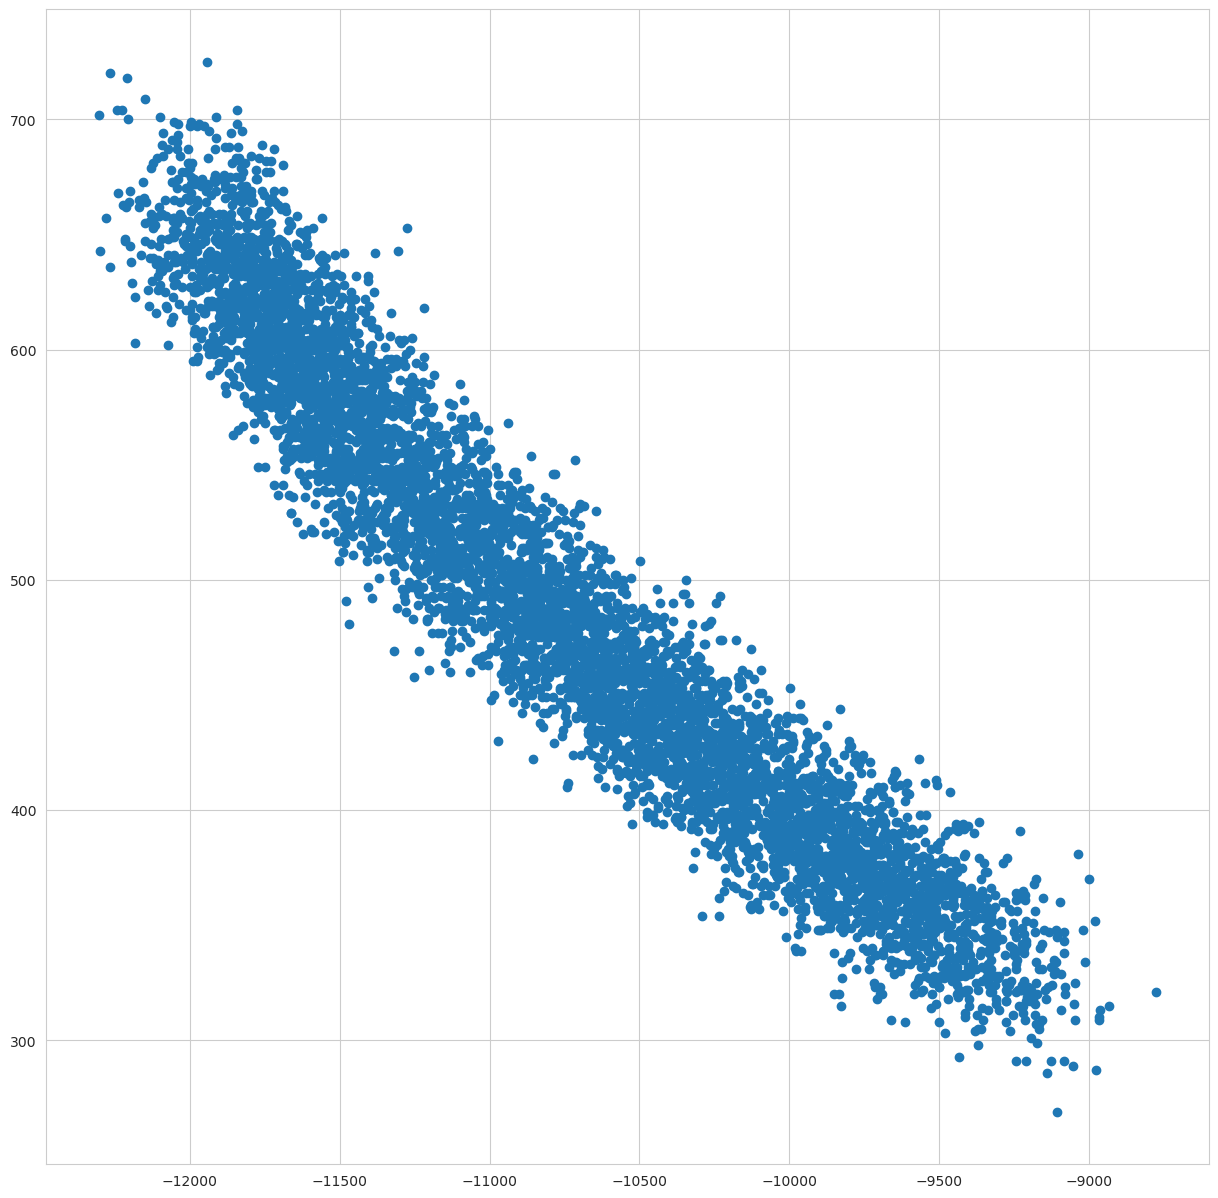

In [40]:
plt.figure(figsize=(15,15))
plt.scatter(df['soma'],df['n6'])

In [17]:
df

,V,E,triangulos,euler,soma,temp_valor,n5,n6
0,1993,3535,47,-1495,-12227,0.0,559,704
1,1996,3505,48,-1461,-11920,0.0,536,674
2,1996,3510,51,-1463,-11859,0.0,535,681
3,1999,3504,44,-1461,-11762,0.0,512,660
4,1997,3489,50,-1442,-11636,0.0,518,629
...,...,...,...,...,...,...,...,...
6295,1989,3276,92,-1195,-9656,100.0,396,342
6296,1984,3283,126,-1173,-9660,100.0,358,358
6297,1982,3218,120,-1116,-9142,100.0,314,318
6298,1992,3262,103,-1167,-9437,100.0,344,319
